# Receipt Entity Extractor — Table of Contents
PaddleOCR + LayoutLMv3 for receipt key-information extraction (SROIE)

## Phase 1 · Data & OCR  (Days 1–4)
- **Day 1 — Environment setup & dataset acquisition**
  Mount Drive, install dependencies, download and extract SROIE 2019.
- **Day 2 — Dataset exploration (EDA)**
  Image-dimension analysis, per-field character-length distributions, label-format inspection.
- **Day 3 — PaddleOCR fundamentals**
  Text detection + recognition on single receipts; box extraction; OCR visualization.
- **Day 4 — Batch OCR pipeline**
  OCR over all receipts; resize-limit strategy (high-res for the first batch, 1500px for the rest); save OCR JSONs.

## Phase 2 · Model & data preparation  (Days 5–7)
- **Day 5 — LayoutLMv3 & layout-aware tokenization**
  Architecture overview; processor; box normalization to the 0–1000 space.
- **Day 6 — BIO label generation**
  Align gold fields to OCR tokens via fuzzy matching; per-field positional heuristics (e.g. total→bottom).
- **Day 7 — Dataset assembly & train/val split**
  Build datasets/dataloaders; entity-label visualization; 563/63 train/val split.

## Phase 3 · Fine-tuning  (Days 8–12)
- **Day 8 — First fine-tune (smoke test)**
  Manual training loop, 3 epochs, sanity check.
- **Day 9 — Full fine-tuning run**
  12-epoch run from `microsoft/layoutlmv3-base`; per-class accuracy analysis (I-COMPANY weakness).
- **Day 10 — Hyperparameter sweep**
  baseline / lower_lr / high_wd with early stopping; baseline (lr 5e-5, wd 0.01) selected.
- **Day 11 — Early stopping & best-checkpoint training**
  Re-train with patience-based stopping + best-checkpoint tracking; I-COMPANY recovery.
- **Day 12 — Final model training**
  Final run on the selected config; best checkpoint at epoch 5 (val loss 0.0248) → `layoutlmv3_FINAL/best`.

## Phase 4 · Evaluation  (Days 13–15)
- **Day 13 — Evaluation framework**
  Per-field exact & fuzzy F1 (P/R/F1/TP/FP/FN); macro 0.32 exact / 0.78 fuzzy.
- **Day 14 — Failure diagnostics**
  Split empty predictions into model failures (~71%) vs OCR failures (~29%).
- **Day 15 — Targeted re-OCR & re-evaluation**
  Re-OCR low-confidence receipts at higher resolution; Day 13→15 comparison (+0.026 fuzzy).

## Phase 5 · Generalization & baselines  (Days 16–18)
- **Day 16 — Cross-dataset: CORD (zero-shot)**
  Indonesian receipts; near-zero transfer due to schema/language mismatch.
- **Day 17 — Cross-dataset: WildReceipt + three-dataset summary**
  English receipts (replaced FUNSD); partial transfer (date generalizes best); SROIE/WildReceipt/CORD summary table.
- **Day 18 — OCR-only baseline comparison**
  Rule-based baseline vs LayoutLMv3 (+0.37 fuzzy macro); baseline beats the model on dates.

## Phase 6 · Pipeline & demo  (Days 19–21)
- **Day 19 — Post-processing & date fallback**
  Field-specific cleaners + regex date-recovery fallback; macro 0.42 exact / 0.81 fuzzy.
- **Day 20 — End-to-end inference pipeline**
  `ReceiptExtractor` class, `extract(image) → dict` API, latency benchmark, gold-vs-prediction visualization.
- **Day 21 — Gradio demo**
  Interactive app: upload/clear, example receipts, results table, JSON download.

**START OF DAY 1**

Step 1: Mount drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Step 2: Creating the project folder structure (except data folder which was created manually)

In [ ]:
import os

PROJECT_DIR = '/content/drive/MyDrive/doc-understanding'

os.makedirs(f'{PROJECT_DIR}/notebooks', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/models',    exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/outputs',   exist_ok=True)

print("Project root:", PROJECT_DIR)
print("Contents:   ", sorted(os.listdir(PROJECT_DIR)))

Project root: /content/drive/MyDrive/doc-understanding
Contents:    ['data', 'models', 'notebooks', 'outputs']


Step 3: checking data

In [ ]:
!ls -lh /content/drive/MyDrive/doc-understanding/data/sroie/

total 835M
-rw------- 1 root root 835M May 27 15:36 archive.zip


Step 4: Unzip the data inside Colab

In [ ]:
import zipfile

ZIP_PATH  = f'{PROJECT_DIR}/data/sroie/sroie-datasetv2.zip'   # ← adjust if your zip is named differently
EXTRACT_TO = f'{PROJECT_DIR}/data/sroie_extracted'

os.makedirs(EXTRACT_TO, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_TO)

print("Done. Top-level contents:")
print(sorted(os.listdir(EXTRACT_TO)))

Done. Top-level contents:
['SROIE2019']


Step 5 — Find the actual image and annotation folders

In [ ]:
TRAIN_IMG_DIR  = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/train/img'        # adjust based on Step 7 output
TRAIN_ENT_DIR  = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/train/entities'
TEST_IMG_DIR   = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/img'
TEST_ENT_DIR   = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/entities'

# Quick sanity checks
print("Train images   :", len(os.listdir(TRAIN_IMG_DIR)))
print("Train entities :", len(os.listdir(TRAIN_ENT_DIR)))
print("Test images    :", len(os.listdir(TEST_IMG_DIR)))
print("Test entities  :", len(os.listdir(TEST_ENT_DIR)))

Train images   : 626
Train entities : 626
Test images    : 347
Test entities  : 347


Step 6: Looking at one example

In [ ]:
import json

# Get a sorted list of image filenames so the "first" one is deterministic
train_images = sorted(os.listdir(TRAIN_IMG_DIR))
print("First 5 image filenames:", train_images[:5])

# Pick the first one
img_filename = train_images[0]
img_id = os.path.splitext(img_filename)[0]   # strip ".jpg"
print(f"\nLooking at: {img_id}")

# Load the matching entities file
ent_path = os.path.join(TRAIN_ENT_DIR, f"{img_id}.txt")
with open(ent_path, 'r', encoding='utf-8') as f:
    entities = json.load(f)

print("\n=== Entities (these are the labels we'll train the model to predict) ===")
for field, value in entities.items():
    print(f"  {field:>8}: {value}")

First 5 image filenames: ['X00016469612.jpg', 'X00016469619.jpg', 'X00016469620.jpg', 'X00016469622.jpg', 'X00016469623.jpg']

Looking at: X00016469612

=== Entities (these are the labels we'll train the model to predict) ===
   company: BOOK TA .K (TAMAN DAYA) SDN BHD
      date: 25/12/2018
   address: NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU, JOHOR.
     total: 9.00


Step 7: Visualize the receipt

Image size (W x H): (463, 1013)


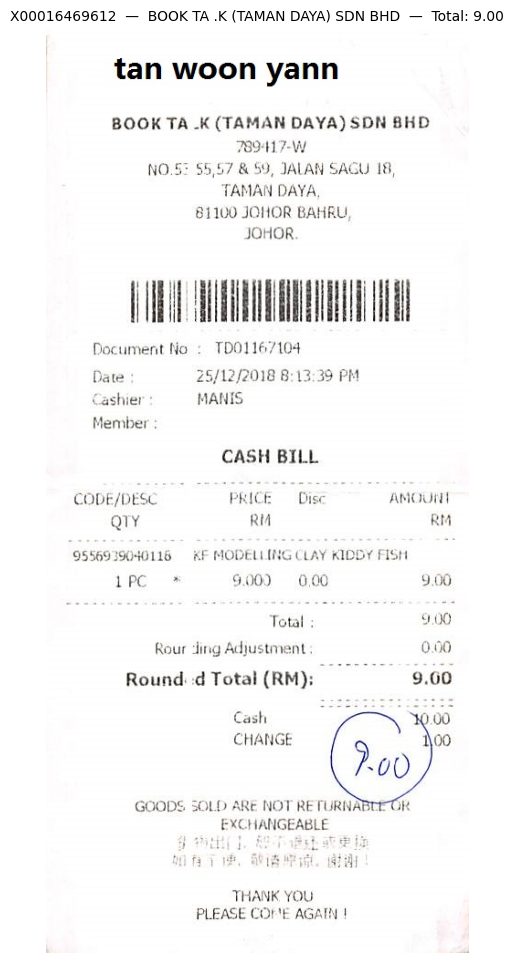

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = os.path.join(TRAIN_IMG_DIR, img_filename)
img = Image.open(img_path)

print(f"Image size (W x H): {img.size}")

fig, ax = plt.subplots(1, figsize=(8, 12))
ax.imshow(img)
ax.set_title(f"{img_id}  —  {entities.get('company', '?')}  —  Total: {entities.get('total', '?')}",
             fontsize=10)
ax.axis('off')
plt.show()

**START OF DAY 2**

Step 0: reconnect the colab notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = '/content/drive/MyDrive/doc-understanding'
DATA_ROOT   = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019'

TRAIN_IMG_DIR = f'{DATA_ROOT}/train/img'
TRAIN_ENT_DIR = f'{DATA_ROOT}/train/entities'
TEST_IMG_DIR  = f'{DATA_ROOT}/test/img'
TEST_ENT_DIR  = f'{DATA_ROOT}/test/entities'

for path in [TRAIN_IMG_DIR, TRAIN_ENT_DIR, TEST_IMG_DIR, TEST_ENT_DIR]:
    assert os.path.exists(path), f"Missing path: {path}"

print("All 4 dataset paths exist ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All 4 dataset paths exist ✓


Step 1: Load every annotation into memory

In [ ]:
import json

def load_all_entities(entity_dir):
    """Read every .txt file in entity_dir and parse the JSON inside."""
    entities_dict = {}
    failed = []
    for filename in sorted(os.listdir(entity_dir)):
        file_id = os.path.splitext(filename)[0]   # "X51005268200.txt" → "X51005268200"
        path = os.path.join(entity_dir, filename)
        try:
            with open(path, 'r', encoding='utf-8') as f:
                entities_dict[file_id] = json.load(f)
        except (json.JSONDecodeError, UnicodeDecodeError) as e:
            failed.append((filename, str(e)))
    return entities_dict, failed

train_entities, train_failed = load_all_entities(TRAIN_ENT_DIR)
test_entities,  test_failed  = load_all_entities(TEST_ENT_DIR)

print(f"Train: {len(train_entities)} loaded, {len(train_failed)} failed")
print(f"Test : {len(test_entities)} loaded, {len(test_failed)} failed")

if train_failed:
    print("\nSample failures (these files have parsing issues):")
    for filename, err in train_failed[:5]:
        print(f"  {filename}: {err[:80]}")

Train: 626 loaded, 0 failed
Test : 347 loaded, 0 failed


Step 2: Field presence

For each of the 4 entity fields, count how many receipts actually have it populated with a non-empty value.

In [ ]:
from collections import Counter

EXPECTED_FIELDS = ['company', 'date', 'address', 'total']

def field_presence(entities_dict):
    """Count receipts where each field is present and non-empty."""
    counts = Counter()
    for ent in entities_dict.values():
        for field in EXPECTED_FIELDS:
            value = ent.get(field, '')
            if value and str(value).strip():    # non-empty after stripping whitespace
                counts[field] += 1
    return counts

n_train = len(train_entities)
train_presence = field_presence(train_entities)

print(f"Field presence across {n_train} train receipts:\n")
print(f"  {'field':>8}  {'present':>7}  {'missing':>7}  {'% present':>9}")
for field in EXPECTED_FIELDS:
    present = train_presence[field]
    missing = n_train - present
    pct = 100 * present / n_train
    print(f"  {field:>8}  {present:>7}  {missing:>7}  {pct:>8.1f}%")

Field presence across 626 train receipts:

     field  present  missing  % present
   company      626        0     100.0%
      date      626        0     100.0%
   address      625        1      99.8%
     total      625        1      99.8%


Step 3: Field length statistics

Now: how long are the values? This drives a decision later — how many tokens we need to allocate per field in our model.

In [ ]:
import numpy as np

def field_length_stats(entities_dict, field):
    """Get character lengths of a specific field, ignoring empty values."""
    lengths = []
    for ent in entities_dict.values():
        value = ent.get(field, '')
        if value and str(value).strip():
            lengths.append(len(str(value)))
    return np.array(lengths)

print(f"Character length per field (train set):\n")
print(f"  {'field':>8}  {'count':>5}  {'min':>4}  {'mean':>6}  {'p50':>4}  {'p95':>4}  {'max':>4}")

for field in EXPECTED_FIELDS:
    lengths = field_length_stats(train_entities, field)
    print(f"  {field:>8}  "
          f"{len(lengths):>5}  "
          f"{lengths.min():>4}  "
          f"{lengths.mean():>6.1f}  "
          f"{int(np.percentile(lengths, 50)):>4}  "
          f"{int(np.percentile(lengths, 95)):>4}  "
          f"{lengths.max():>4}")

Character length per field (train set):

     field  count   min    mean   p50   p95   max
   company    626     7    24.9    24    39    49
      date    626     8     9.6    10    11    12
   address    625    21    70.8    72    96   135
     total    625     4     5.1     5     7     8


Step 4: Image dimensions

In [ ]:
from PIL import Image

def get_image_sizes(img_dir):
    """Read (width, height) from image headers — fast even from Drive."""
    sizes = []
    filenames = sorted(f for f in os.listdir(img_dir) if f.lower().endswith('.jpg'))
    for fn in filenames:
        with Image.open(os.path.join(img_dir, fn)) as img:
            sizes.append(img.size)   # (W, H)
    return np.array(sizes), filenames

print("Reading image dimensions (30–60 seconds from Drive)...")
train_sizes, train_filenames = get_image_sizes(TRAIN_IMG_DIR)

widths  = train_sizes[:, 0]
heights = train_sizes[:, 1]
aspects = heights / widths       # tall receipts have ratio > 1

print(f"\nImage dimensions (n={len(train_sizes)}):")
print(f"  width  — min {widths.min()}, mean {widths.mean():.0f}, max {widths.max()}, p95 {int(np.percentile(widths, 95))}")
print(f"  height — min {heights.min()}, mean {heights.mean():.0f}, max {heights.max()}, p95 {int(np.percentile(heights, 95))}")
print(f"  H/W    — min {aspects.min():.2f}, mean {aspects.mean():.2f}, max {aspects.max():.2f}")

Reading image dimensions (30–60 seconds from Drive)...

Image dimensions (n=626):
  width  — min 436, mean 1326, max 4961, p95 4961
  height — min 605, mean 2356, max 7016, p95 7016
  H/W    — min 1.03, mean 2.05, max 3.80


Step 5: Visualize the distributions

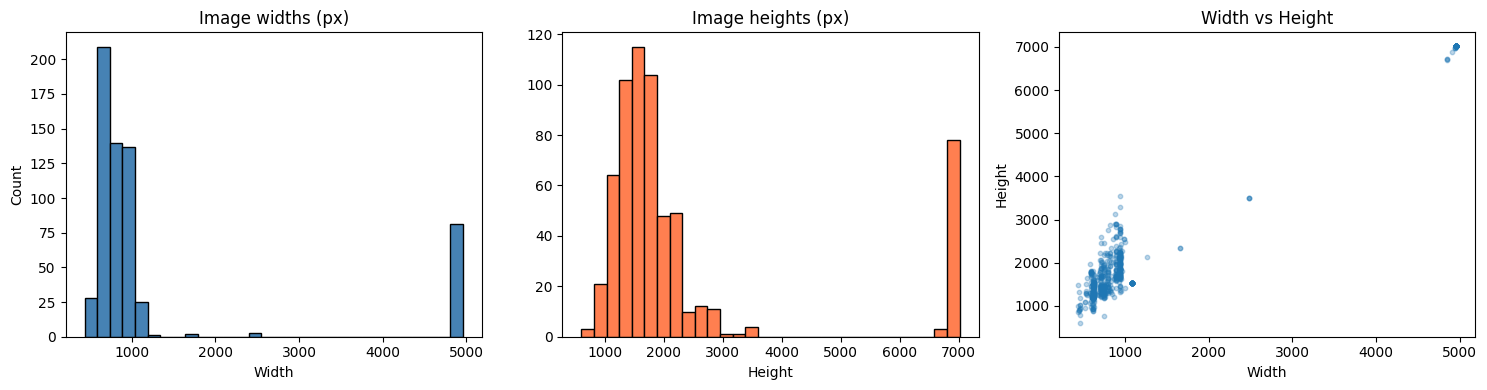

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Image widths (px)')
axes[0].set_xlabel('Width')
axes[0].set_ylabel('Count')

axes[1].hist(heights, bins=30, color='coral', edgecolor='black')
axes[1].set_title('Image heights (px)')
axes[1].set_xlabel('Height')

axes[2].scatter(widths, heights, alpha=0.3, s=10)
axes[2].set_title('Width vs Height')
axes[2].set_xlabel('Width')
axes[2].set_ylabel('Height')

plt.tight_layout()
plt.show()

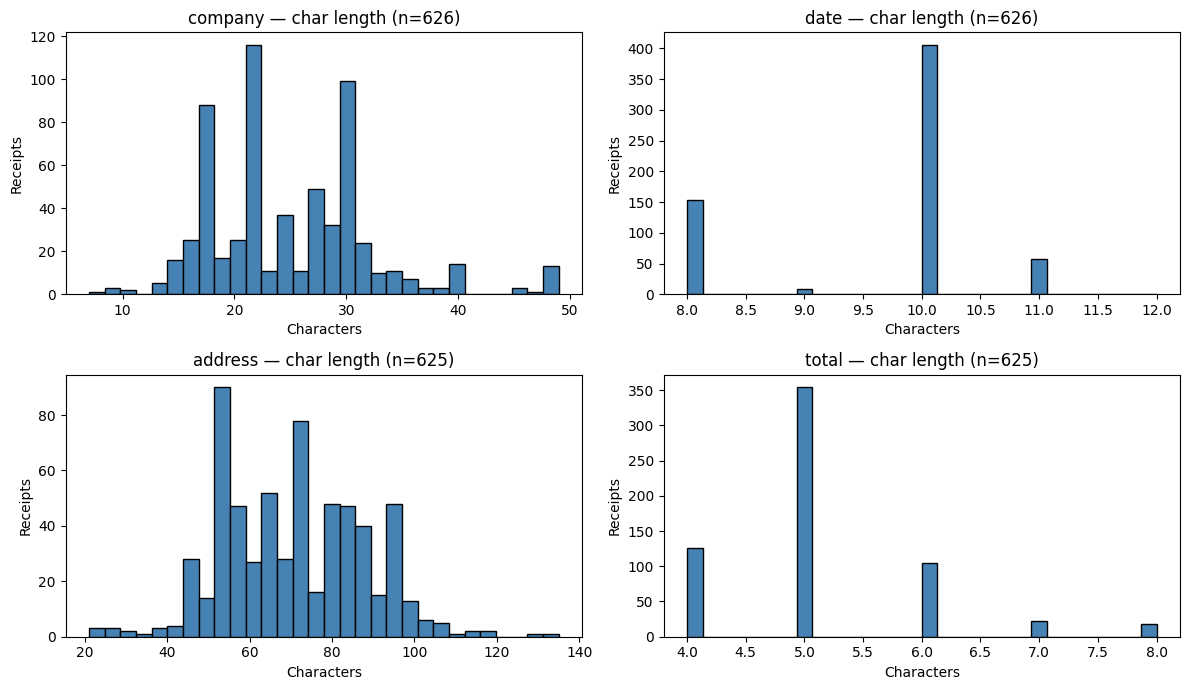

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for ax, field in zip(axes.flat, EXPECTED_FIELDS):
    lengths = field_length_stats(train_entities, field)
    ax.hist(lengths, bins=30, color='steelblue', edgecolor='black')
    ax.set_title(f'{field} — char length (n={len(lengths)})')
    ax.set_xlabel('Characters')
    ax.set_ylabel('Receipts')

plt.tight_layout()
plt.show()

Step 6: Checking Image-annotation mismatches

In [ ]:
train_img_ids = {os.path.splitext(f)[0] for f in os.listdir(TRAIN_IMG_DIR) if f.lower().endswith('.jpg')}
train_ent_ids = set(train_entities.keys())

img_no_ent = train_img_ids - train_ent_ids
ent_no_img = train_ent_ids - train_img_ids

print(f"Train images without matching annotation: {len(img_no_ent)}")
if img_no_ent:
    print("  Examples:", sorted(img_no_ent)[:5])

print(f"Train annotations without matching image: {len(ent_no_img)}")
if ent_no_img:
    print("  Examples:", sorted(ent_no_img)[:5])

valid_train_ids = sorted(train_img_ids & train_ent_ids)
print(f"\nValid (image + annotation) train pairs: {len(valid_train_ids)}")

Train images without matching annotation: 0
Train annotations without matching image: 0

Valid (image + annotation) train pairs: 626


Step 7: Eyeballing Data

In [ ]:
import random
random.seed(42)   # reproducibility — same 10 examples every time you re-run

sample_ids = random.sample(valid_train_ids, 10)

for file_id in sample_ids:
    ent = train_entities[file_id]
    print(f"\n=== {file_id} ===")
    for field in EXPECTED_FIELDS:
        val = ent.get(field, '<missing>')
        val_str = str(val) if val is not None else '<None>'
        if len(val_str) > 70:
            val_str = val_str[:67] + '...'
        print(f"  {field:>8}: {val_str}")


=== X51005676538 ===
   company: SYARIKAT PERNIAGAAN GIN KEE
      date: 04/01/2018
   address: NO 290, JALAN AIR PANAS, SETAPAK, 53200, KUALA LUMPUR.
     total: 44.73

=== X51005361900 ===
   company: TEO HENG STATIONERY & BOOKS
      date: 23/01/2018
   address: NO.53,JALAN BESAR,45600 BATANG BERJUNTAI SELANGOR DARUL EHSAN
     total: 18.00

=== X51006414392 ===
   company: DI HUAN YA RESTAURANT
      date: 07/04/2018
   address: 5,JALAN PERMAS 10/5, BANDAR BARU PERMAS JAYA, 81750 JOHOR BAHRU,JOHOR
     total: 35.00

=== X51006350763 ===
   company: GL HANDICRAFT & TAII ORING
      date: 09/04/2018
   address: 19, JALAN KANCIL, OFF JALAN PUDU, 55100 KUALA LUMPUR MALAYSIA
     total: 104.00

=== X51006311767 ===
   company: TONYMOLY VIVA CITY
      date: 29/03/2018
   address: UNIT L1-044B, VIVACITY MEGAMALL, JALAN WAN ALWI, 93350 KUCHING, SAR...
     total: 48.95

=== X51005711447 ===
   company: RESTORAN WAN SHENG
      date: 14-03-2018
   address: NO.2, JALAN TEMENGGUNG 19/9, SEK

**START OF DAY 3**

Step 0: reconnect the colab notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR   = '/content/drive/MyDrive/doc-understanding'
DATA_ROOT     = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019'
TRAIN_IMG_DIR = f'{DATA_ROOT}/train/img'
TRAIN_ENT_DIR = f'{DATA_ROOT}/train/entities'

assert os.path.exists(TRAIN_IMG_DIR), f"Missing: {TRAIN_IMG_DIR}"
assert os.path.exists(TRAIN_ENT_DIR), f"Missing: {TRAIN_ENT_DIR}"
print("Paths verified ✓")

Mounted at /content/drive
Paths verified ✓


Step 1: Install PaddleOCR

In [ ]:
!pip install -q paddlepaddle==3.2.2 paddleocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 121.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 102.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2

Step 2: Initialize the OCR engine

The PaddleOCR() constructor downloads pretrained model weights on first call and loads them into memory.

In [ ]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    use_doc_orientation_classify=False,   # skip whole-page rotation — slow, not needed for receipts
    use_doc_unwarping=False,              # skip curl-correction — slow, marginal benefit
    use_textline_orientation=True,        # keep per-line rotation detection — useful for receipts
    device='cpu',
)
print("PaddleOCR initialized ✓")

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None, None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_rec', None, None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

PaddleOCR initialized ✓


Step 3: Pick one receipt deterministically

Same pattern as Day 2 — seed the RNG so we always work on the same receipt while learning.

In [ ]:
import random

random.seed(42)
train_images = sorted(f for f in os.listdir(TRAIN_IMG_DIR) if f.lower().endswith('.jpg'))
target_filename = random.choice(train_images)
target_id = os.path.splitext(target_filename)[0]
target_img_path = os.path.join(TRAIN_IMG_DIR, target_filename)

print(f"Target receipt: {target_filename}")
print(f"Path          : {target_img_path}")

Target receipt: X51005676538.jpg
Path          : /content/drive/MyDrive/doc-understanding/data/sroie_extracted/SROIE2019/train/img/X51005676538.jpg


Step 4: Run OCR on the receipt

In [ ]:
# Step 5: Run OCR on the target receipt
# PaddleOCR.predict() returns an iterator; we materialize it into a list
# so we can index by page (single-image input → single page).

result = list(ocr.predict(target_img_path))
print(f"Pages returned: {len(result)}")

res = result[0]
print(f"Result object type: {type(res).__name__}")

Pages returned: 1
Result object type: OCRResult


Step 5: Inspect the raw result structure

In [ ]:
# Step 6: Inspect the raw result structure.
#
# PaddleOCR 3.x may expose its OCR fields either at the top level of the
# result dict or nested under a 'res' key, depending on the pipeline
# configuration. We define a small helper that normalizes both formats
# into a single flat dict for downstream use.

def extract_data_dict(res):
    """
    Normalize a PaddleOCR result object into a flat dict.

    Handles two output formats observed in PaddleOCR 3.x:
        - Top-level:  {'rec_texts': [...], 'rec_scores': [...], ...}
        - Nested:     {'res': {'rec_texts': [...], 'rec_scores': [...], ...}}
    """
    if hasattr(res, 'json'):
        data = res.json
    elif isinstance(res, dict):
        data = res
    else:
        data = dict(res)

    if isinstance(data, dict) and 'res' in data and isinstance(data['res'], dict):
        inner = data['res']
        if any(k in inner for k in ('rec_texts', 'rec_polys', 'dt_polys')):
            data = inner

    return data

data = extract_data_dict(res)
print(f"Keys in result: {list(data.keys())}")
print(f"Number of detections: {len(data.get('rec_texts', []))}")

Keys in result: ['input_path', 'page_index', 'model_settings', 'dt_polys', 'text_det_params', 'text_type', 'textline_orientation_angles', 'text_rec_score_thresh', 'return_word_box', 'rec_texts', 'rec_scores', 'rec_polys', 'rec_boxes']
Number of detections: 77


Step 6: Parse into a clean structure

In [ ]:
# Step 7: Parse the result into a clean list-of-dicts structure that the
# rest of the pipeline (visualization, evaluation, downstream models) can
# consume without depending on PaddleOCR's internal format.

def parse_paddleocr(res):
    """
    Convert a PaddleOCR result object into a list of detection dicts.

    Each detection contains:
        bbox_poly  : 4-point polygon as list of [x, y] pairs
        text       : recognized text string
        confidence : recognition confidence score in [0, 1]
    """
    data = extract_data_dict(res)

    texts  = list(data.get('rec_texts',  []))
    scores = list(data.get('rec_scores', []))
    polys  = list(data.get('rec_polys',  data.get('dt_polys', [])))

    parsed = []
    for text, score, poly in zip(texts, scores, polys):
        poly_list = [[float(p[0]), float(p[1])] for p in poly]
        parsed.append({
            'bbox_poly':  poly_list,
            'text':       str(text),
            'confidence': float(score),
        })
    return parsed

parsed_detections = parse_paddleocr(res)
print(f"Parsed {len(parsed_detections)} detections.\n")

if not parsed_detections:
    print("Zero detections parsed. Raw result structure follows:")
    res.print()
else:
    print("First 5 detections:")
    for i, d in enumerate(parsed_detections[:5]):
        print(f"  [{i}]  conf={d['confidence']:.3f}  text={d['text']!r}")

Parsed 77 detections.

First 5 detections:
  [0]  conf=0.995  text='SYARIKATPERNIAGAANGINKEE'
  [1]  conf=0.897  text='（81109-A）'
  [2]  conf=0.976  text='NO290,JALANAIRPANAS,'
  [3]  conf=0.953  text='SETAPAK,'
  [4]  conf=0.967  text='53200,KUALALUMPUR.'


Step 7: Convert polygon bboxes to xyxy rectangles

In [ ]:
def polygon_to_xyxy(polygon):
    """Convert a 4-point polygon to an axis-aligned [x0, y0, x1, y1] box."""
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    return [int(min(xs)), int(min(ys)), int(max(xs)), int(max(ys))]

# Add an 'bbox_xyxy' key to every detection
for d in parsed_detections:
    d['bbox_xyxy'] = polygon_to_xyxy(d['bbox_poly'])

# Sanity check on first detection
d0 = parsed_detections[0]
print("Polygon:", d0['bbox_poly'])
print("xyxy   :", d0['bbox_xyxy'])

Polygon: [[92.0, 212.0], [835.0, 212.0], [835.0, 253.0], [92.0, 253.0]]
xyxy   : [92, 212, 835, 253]


Step 8: Visualize OCR output on the receipt

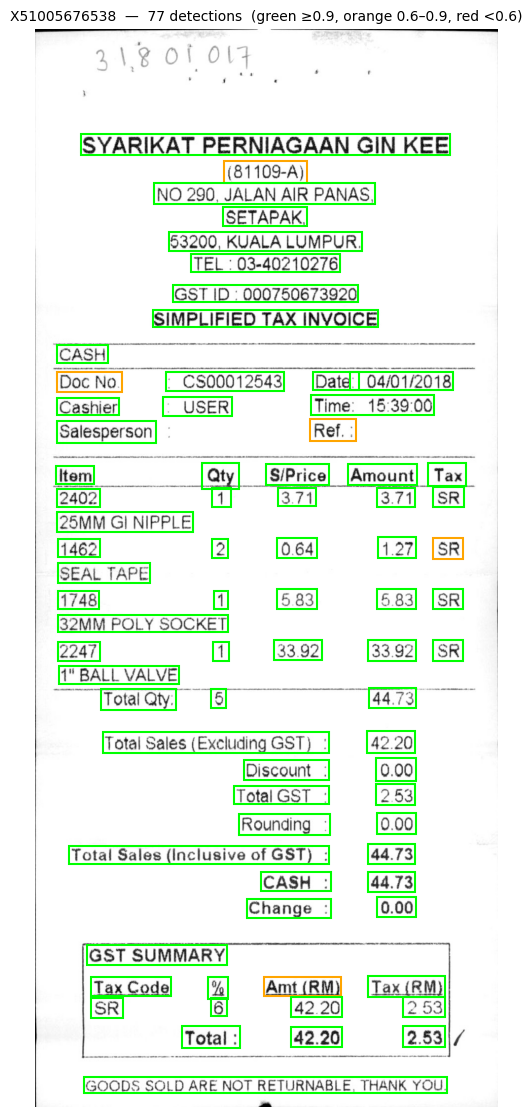

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img = Image.open(target_img_path)

fig, ax = plt.subplots(1, figsize=(10, 14))
ax.imshow(img)

for d in parsed_detections:
    x0, y0, x1, y1 = d['bbox_xyxy']
    # Color the box by confidence — green=high, red=low
    if d['confidence'] >= 0.9:
        edge_color = 'lime'
    elif d['confidence'] >= 0.6:
        edge_color = 'orange'
    else:
        edge_color = 'red'

    rect = patches.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        linewidth=1.5,
        edgecolor=edge_color,
        facecolor='none',
    )
    ax.add_patch(rect)

ax.set_title(
    f"{target_id}  —  {len(parsed_detections)} detections  "
    f"(green ≥0.9, orange 0.6–0.9, red <0.6)",
    fontsize=10,
)
ax.axis('off')
plt.show()

Step 9: Quantify OCR quality

In [ ]:
import numpy as np

confs = np.array([d['confidence'] for d in parsed_detections])

print(f"Detections : {len(parsed_detections)}")
print(f"Confidence — min {confs.min():.3f}, mean {confs.mean():.3f}, max {confs.max():.3f}")
print(f"Detections with conf ≥ 0.9 : {(confs >= 0.9).sum()}")
print(f"Detections with conf 0.6–0.9: {((confs >= 0.6) & (confs < 0.9)).sum()}")
print(f"Detections with conf < 0.6 : {(confs < 0.6).sum()}")

Detections : 77
Confidence — min 0.817, mean 0.974, max 1.000
Detections with conf ≥ 0.9 : 72
Detections with conf 0.6–0.9: 5
Detections with conf < 0.6 : 0


Step 10: Compare OCR text against the ground-truth entities

In [ ]:
import json

# Load this receipt's ground-truth entities
ent_path = os.path.join(TRAIN_ENT_DIR, f"{target_id}.txt")
with open(ent_path, 'r', encoding='utf-8') as f:
    ground_truth = json.load(f)

# Concatenate all OCR'd text into one big lowercase blob
ocr_blob = ' | '.join(d['text'] for d in parsed_detections).lower()

print(f"=== Ground truth entities for {target_id} ===")
for field, value in ground_truth.items():
    if not value:
        print(f"  {field:>8}: <missing in annotation>")
        continue
    # Naive substring match — does the OCR'd text contain the entity value?
    found = value.lower() in ocr_blob
    status = "FOUND ✓" if found else "MISSING ✗"
    print(f"  {field:>8}: {status}  expected: {value!r}")

=== Ground truth entities for X51005676538 ===
   company: MISSING ✗  expected: 'SYARIKAT PERNIAGAAN GIN KEE'
      date: FOUND ✓  expected: '04/01/2018'
   address: MISSING ✗  expected: 'NO 290, JALAN AIR PANAS, SETAPAK, 53200, KUALA LUMPUR.'
     total: FOUND ✓  expected: '44.73'


Step 11: Print everything PaddleOCR saw, in reading order

In [ ]:
# Sort detections by vertical position (top → bottom)
sorted_detections = sorted(parsed_detections, key=lambda d: d['bbox_xyxy'][1])

print(f"=== Full OCR transcript of {target_id} ===\n")
for d in sorted_detections:
    print(f"  [conf {d['confidence']:.2f}]  {d['text']}")

=== Full OCR transcript of X51005676538 ===

  [conf 0.99]  SYARIKATPERNIAGAANGINKEE
  [conf 0.90]  （81109-A）
  [conf 0.98]  NO290,JALANAIRPANAS,
  [conf 0.95]  SETAPAK,
  [conf 0.97]  53200,KUALALUMPUR.
  [conf 0.94]  TEL:03-40210276
  [conf 0.97]  GSTID:000750673920
  [conf 0.99]  SIMPLIFIEDTAXINVOICE
  [conf 0.99]  CASH
  [conf 0.88]  DocNo.
  [conf 0.95]  :CS00012543
  [conf 0.95]  Date:
  [conf 0.95]  ：04/01/2018
  [conf 0.93]  Time:15:39:00
  [conf 0.96]  :USER
  [conf 1.00]  Cashier
  [conf 0.88]  Ref.:
  [conf 1.00]  Salesperson
  [conf 0.99]  Qty
  [conf 1.00]  Tax
  [conf 0.99]  S/Price
  [conf 1.00]  Amount
  [conf 0.97]  ltem
  [conf 0.98]  SR
  [conf 1.00]  3.71
  [conf 1.00]  3.71
  [conf 1.00]  1
  [conf 1.00]  2402
  [conf 0.99]  25MMGINIPPLE
  [conf 1.00]  1.27
  [conf 1.00]  0.64
  [conf 0.82]  SR
  [conf 1.00]  1462
  [conf 1.00]  2
  [conf 1.00]  SEALTAPE
  [conf 1.00]  5.83
  [conf 1.00]  5.83
  [conf 0.98]  SR
  [conf 1.00]  1748
  [conf 1.00]  1
  [conf 1.00]  32

**START OF DAY 4**

Step 0: reconnect the colab notebook

In [ ]:
# Mount Google Drive and configure all input/output paths for batch OCR.

from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR    = '/content/drive/MyDrive/doc-understanding'
DATA_ROOT      = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019'

# Inputs
TRAIN_IMG_DIR  = f'{DATA_ROOT}/train/img'
TEST_IMG_DIR   = f'{DATA_ROOT}/test/img'

# Outputs (created if missing)
OCR_OUT_DIR    = f'{PROJECT_DIR}/outputs/ocr'
TRAIN_OCR_DIR  = f'{OCR_OUT_DIR}/train'
TEST_OCR_DIR   = f'{OCR_OUT_DIR}/test'

os.makedirs(TRAIN_OCR_DIR, exist_ok=True)
os.makedirs(TEST_OCR_DIR,  exist_ok=True)

for path in [TRAIN_IMG_DIR, TEST_IMG_DIR, TRAIN_OCR_DIR, TEST_OCR_DIR]:
    assert os.path.exists(path), f"Missing: {path}"

print("All paths configured and verified.")

Mounted at /content/drive
All paths configured and verified.


Step 1: reInstall dependencies

In [ ]:
!pip install -q paddlepaddle==3.2.2 paddleocr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/

Step 2: Reinitialize the OCR engine

In [ ]:
# Initialize PaddleOCR with the same configuration we used on Day 3.
# We keep the server models (default) rather than mobile models so accuracy
# stays consistent with what we validated yesterday.

from paddleocr import PaddleOCR

ocr = PaddleOCR(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=True,
    device='cpu',
)
print("PaddleOCR initialized.")

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None, None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_rec', None, None)
Using official model (PP-OCRv5_server_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

PaddleOCR initialized.


Step 3: Redefine the result parsers

In [ ]:
# Re-define the helpers from Day 3 so this notebook is self-contained.
# (Each day's notebook should run end-to-end without external imports.)

def extract_data_dict(res):
    """
    Normalize a PaddleOCR result object into a flat dict.

    Handles two output formats observed in PaddleOCR 3.x:
        - Top-level: {'rec_texts': [...], 'rec_scores': [...], ...}
        - Nested:    {'res': {'rec_texts': [...], 'rec_scores': [...], ...}}
    """
    if hasattr(res, 'json'):
        data = res.json
    elif isinstance(res, dict):
        data = res
    else:
        data = dict(res)

    if isinstance(data, dict) and 'res' in data and isinstance(data['res'], dict):
        inner = data['res']
        if any(k in inner for k in ('rec_texts', 'rec_polys', 'dt_polys')):
            data = inner

    return data


def parse_paddleocr(res):
    """Convert a PaddleOCR result object into a list of detection dicts."""
    data = extract_data_dict(res)

    texts  = list(data.get('rec_texts',  []))
    scores = list(data.get('rec_scores', []))
    polys  = list(data.get('rec_polys',  data.get('dt_polys', [])))

    parsed = []
    for text, score, poly in zip(texts, scores, polys):
        poly_list = [[float(p[0]), float(p[1])] for p in poly]
        parsed.append({
            'bbox_poly':  poly_list,
            'text':       str(text),
            'confidence': float(score),
        })
    return parsed

Step 4: Define the per-image processing function

In [ ]:
# Process a single image: run OCR, parse, save JSON to disk.
# Returns one of three states so the batch loop can track outcomes.

import json

def process_and_save(img_path, output_dir, ocr_engine):
    """
    Run OCR on one image and save the parsed result as JSON.

    Returns:
        'processed' if the image was OCR'd and saved
        'skipped'   if the output file already exists (resumability)
        'failed'    if OCR or save raised an exception
    """
    file_id     = os.path.splitext(os.path.basename(img_path))[0]
    output_path = os.path.join(output_dir, f"{file_id}.json")

    # Resumability: skip if already processed
    if os.path.exists(output_path):
        return 'skipped'

    try:
        result = list(ocr_engine.predict(img_path))
        parsed = parse_paddleocr(result[0]) if result else []

        payload = {
            'file_id':       file_id,
            'image_path':    img_path,
            'n_detections':  len(parsed),
            'detections':    parsed,
        }

        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(payload, f, indent=2, ensure_ascii=False)

        return 'processed'

    except Exception as e:
        # Log the failure inline but don't crash the loop
        print(f"  [FAIL] {file_id}: {type(e).__name__}: {str(e)[:80]}")
        return 'failed'

Step 5: Sanity check on one image before the big run

In [ ]:
# Run the full pipeline on one image to confirm the function works end-to-end
# BEFORE committing to a 60-minute batch run.

import random
random.seed(42)

train_files = sorted(
    f for f in os.listdir(TRAIN_IMG_DIR) if f.lower().endswith('.jpg')
)
sanity_filename = random.choice(train_files)
sanity_path     = os.path.join(TRAIN_IMG_DIR, sanity_filename)

status = process_and_save(sanity_path, TRAIN_OCR_DIR, ocr)
print(f"Sanity check on {sanity_filename}: {status}")

# Load and inspect the saved file
sanity_id = os.path.splitext(sanity_filename)[0]
with open(os.path.join(TRAIN_OCR_DIR, f"{sanity_id}.json"), 'r') as f:
    saved = json.load(f)

print(f"  Saved {saved['n_detections']} detections to disk")
print(f"  First detection: {saved['detections'][0] if saved['detections'] else '<empty>'}")

Sanity check on X51005676538.jpg: skipped
  Saved 77 detections to disk
  First detection: {'bbox_poly': [[92.0, 212.0], [835.0, 212.0], [835.0, 253.0], [92.0, 253.0]], 'text': 'SYARIKATPERNIAGAANGINKEE', 'confidence': 0.9949707388877869}


Step 6: Batch OCR the training set

In [ ]:
# Process the full training set with progress bar and outcome tracking.
# This cell takes 30-60 minutes.

from tqdm import tqdm
import time

train_files = sorted(
    f for f in os.listdir(TRAIN_IMG_DIR) if f.lower().endswith('.jpg')
)
print(f"Batch OCR over {len(train_files)} train images...")

stats = {'processed': 0, 'skipped': 0, 'failed': 0}
start_time = time.time()

for filename in tqdm(train_files, desc="Train"):
    img_path = os.path.join(TRAIN_IMG_DIR, filename)
    status   = process_and_save(img_path, TRAIN_OCR_DIR, ocr)
    stats[status] += 1

elapsed_min = (time.time() - start_time) / 60.0
print(f"\nTrain batch complete in {elapsed_min:.1f} min")
print(f"  processed: {stats['processed']}")
print(f"  skipped  : {stats['skipped']}  (already existed from a previous run)")
print(f"  failed   : {stats['failed']}")

Batch OCR over 626 train images...


Train: 100%|██████████| 626/626 [00:00<00:00, 2271.50it/s]


Train batch complete in 0.0 min
  processed: 0
  skipped  : 626  (already existed from a previous run)
  failed   : 0


Step 7: Batch OCR the test set

In [ ]:
# Same logic as Step 6, applied to the test set.

test_files = sorted(
    f for f in os.listdir(TEST_IMG_DIR) if f.lower().endswith('.jpg')
)
print(f"Batch OCR over {len(test_files)} test images...")

stats = {'processed': 0, 'skipped': 0, 'failed': 0}
start_time = time.time()

for filename in tqdm(test_files, desc="Test"):
    img_path = os.path.join(TEST_IMG_DIR, filename)
    status   = process_and_save(img_path, TEST_OCR_DIR, ocr)
    stats[status] += 1

elapsed_min = (time.time() - start_time) / 60.0
print(f"\nTest batch complete in {elapsed_min:.1f} min")
print(f"  processed: {stats['processed']}")
print(f"  skipped  : {stats['skipped']}")
print(f"  failed   : {stats['failed']}")

Batch OCR over 347 test images...


Test: 100%|██████████| 347/347 [00:00<00:00, 4332.53it/s]


Test batch complete in 0.0 min
  processed: 0
  skipped  : 347
  failed   : 0


Step 8: Verify outputs match inputs

In [ ]:
# Compare counts of OCR JSON files vs source images. They should match.

n_train_imgs = len([f for f in os.listdir(TRAIN_IMG_DIR) if f.lower().endswith('.jpg')])
n_test_imgs  = len([f for f in os.listdir(TEST_IMG_DIR)  if f.lower().endswith('.jpg')])
n_train_ocr  = len([f for f in os.listdir(TRAIN_OCR_DIR) if f.endswith('.json')])
n_test_ocr   = len([f for f in os.listdir(TEST_OCR_DIR)  if f.endswith('.json')])

print(f"Train images : {n_train_imgs}")
print(f"Train OCR    : {n_train_ocr}")
print(f"Test images  : {n_test_imgs}")
print(f"Test OCR     : {n_test_ocr}")

train_coverage = 100.0 * n_train_ocr / max(n_train_imgs, 1)
test_coverage  = 100.0 * n_test_ocr  / max(n_test_imgs,  1)
print(f"\nCoverage — train: {train_coverage:.1f}%, test: {test_coverage:.1f}%")

Train images : 626
Train OCR    : 626
Test images  : 347
Test OCR     : 347

Coverage — train: 100.0%, test: 100.0%


Step 9: Compute dataset-wide OCR statistics

In [ ]:
# Aggregate OCR results to summarize the quality of the entire OCR pass.

import numpy as np

all_n_detections = []
all_confidences  = []
zero_detection_files = []

for filename in sorted(os.listdir(TRAIN_OCR_DIR)):
    if not filename.endswith('.json'):
        continue
    with open(os.path.join(TRAIN_OCR_DIR, filename), 'r') as f:
        d = json.load(f)
    all_n_detections.append(d['n_detections'])
    if d['n_detections'] == 0:
        zero_detection_files.append(d['file_id'])
    for det in d['detections']:
        all_confidences.append(det['confidence'])

n_dets = np.array(all_n_detections)
confs  = np.array(all_confidences)

print(f"=== Train set OCR summary (n={len(n_dets)} images) ===\n")
print(f"Detections per image:")
print(f"  min   {n_dets.min()}")
print(f"  mean  {n_dets.mean():.1f}")
print(f"  p50   {int(np.percentile(n_dets, 50))}")
print(f"  p95   {int(np.percentile(n_dets, 95))}")
print(f"  max   {n_dets.max()}")
print()
print(f"Confidence scores (across {len(confs):,} total detected regions):")
print(f"  mean  {confs.mean():.3f}")
print(f"  p5    {np.percentile(confs, 5):.3f}")
print(f"  p50   {np.percentile(confs, 50):.3f}")
print(f"  p95   {np.percentile(confs, 95):.3f}")
print()
print(f"Images with zero detections: {len(zero_detection_files)}")
if zero_detection_files:
    print(f"  Examples: {zero_detection_files[:5]}")

=== Train set OCR summary (n=626 images) ===

Detections per image:
  min   18
  mean  57.2
  p50   53
  p95   91
  max   282

Confidence scores (across 35,777 total detected regions):
  mean  0.872
  p5    0.225
  p50   0.964
  p95   0.999

Images with zero detections: 0


**START OF DAY 5**

Step 0: Reconnect the colab notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR   = '/content/drive/MyDrive/doc-understanding'
DATA_ROOT     = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019'
TRAIN_IMG_DIR = f'{DATA_ROOT}/train/img'
TRAIN_OCR_DIR = f'{PROJECT_DIR}/outputs/ocr/train'

for path in [TRAIN_IMG_DIR, TRAIN_OCR_DIR]:
    assert os.path.exists(path), f"Missing: {path}"

print("Paths verified.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths verified.


Step 1: Install LayoutLMv3

In [ ]:
# Install HuggingFace transformers (the library that hosts LayoutLMv3).

!pip install -q "transformers>=4.40" "torch" "pillow"

Step 2: Load LayoutLMv3 processor and model

In [ ]:
# Load the pretrained processor and base model from HuggingFace.
# First run downloads ~500 MB of model weights to /root/.cache/huggingface/.
# Subsequent runs are instant (cached locally for the session).

from transformers import LayoutLMv3Processor, LayoutLMv3Model

MODEL_NAME = "microsoft/layoutlmv3-base"

# apply_ocr=False is CRITICAL: it tells the processor to expect
# pre-extracted words+boxes from us, not to run its own OCR.
processor = LayoutLMv3Processor.from_pretrained(MODEL_NAME, apply_ocr=False)
model     = LayoutLMv3Model.from_pretrained(MODEL_NAME)

print("Processor and model loaded.")

preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3Model LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     |  | 
-----------------------------------+------------+--+-
layoutlmv3.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Processor and model loaded.


Step 3: Inspect the model architecture

In [ ]:
# Print a summary of the model: parameter counts and key config values.

n_total     = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: {MODEL_NAME}")
print(f"Total parameters    : {n_total:,}")
print(f"Trainable parameters: {n_trainable:,}")
print()
print(f"Hidden size         : {model.config.hidden_size}")
print(f"Num attention heads : {model.config.num_attention_heads}")
print(f"Num hidden layers   : {model.config.num_hidden_layers}")
print(f"Max position embeds : {model.config.max_position_embeddings}")
print(f"Max 2D position     : {model.config.max_2d_position_embeddings}")
print(f"Image input size    : {model.config.input_size}")
print(f"Patch size          : {model.config.patch_size}")

Model: microsoft/layoutlmv3-base
Total parameters    : 125,326,976
Trainable parameters: 125,326,976

Hidden size         : 768
Num attention heads : 12
Num hidden layers   : 12
Max position embeds : 514
Max 2D position     : 1024
Image input size    : 224
Patch size          : 16


Step 4: Load one OCR'd receipt from Day 4

In [ ]:
# Pick one of yesterday's OCR JSONs to use as our running example.
# Sorted listing + index 0 = deterministic choice across re-runs.

import json

sample_files = sorted(
    f for f in os.listdir(TRAIN_OCR_DIR) if f.endswith('.json')
)
sample_path = os.path.join(TRAIN_OCR_DIR, sample_files[0])

with open(sample_path, 'r', encoding='utf-8') as f:
    ocr_data = json.load(f)

print(f"Loaded: {ocr_data['file_id']}")
print(f"Total detections: {ocr_data['n_detections']}")
print(f"Image path: {ocr_data['image_path']}")
print(f"First detection: {ocr_data['detections'][0]}")

Loaded: X00016469612
Total detections: 45
Image path: /content/drive/MyDrive/doc-understanding/data/sroie_extracted/SROIE2019/train/img/X00016469612.jpg
First detection: {'bbox_poly': [[69.0, 27.0], [323.0, 29.0], [322.0, 63.0], [69.0, 61.0]], 'text': 'tan woon yann', 'confidence': 0.9955796003341675}


Step 5: Normalize bboxes to the 0–1000 space

In [ ]:
# LayoutLMv3 requires bounding boxes normalized to integers in [0, 1000].
# Our OCR JSON stores polygons in original pixel coordinates; we convert
# to axis-aligned xyxy, then normalize.

from PIL import Image

img = Image.open(ocr_data['image_path']).convert('RGB')
W, H = img.size
print(f"Image dimensions: {W} x {H} pixels")


def polygon_to_normalized_bbox(polygon, img_width, img_height):
    """
    Convert a 4-point polygon (pixel coords) to a LayoutLMv3-compatible
    bounding box: axis-aligned [x0, y0, x1, y1], normalized to [0, 1000]
    as integers.
    """
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    x0, y0 = min(xs), min(ys)
    x1, y1 = max(xs), max(ys)

    # Normalize and clamp to [0, 1000] to be safe
    return [
        max(0, min(1000, int(1000 * x0 / img_width))),
        max(0, min(1000, int(1000 * y0 / img_height))),
        max(0, min(1000, int(1000 * x1 / img_width))),
        max(0, min(1000, int(1000 * y1 / img_height))),
    ]


words = [det['text'] for det in ocr_data['detections']]
boxes = [polygon_to_normalized_bbox(det['bbox_poly'], W, H)
         for det in ocr_data['detections']]

print(f"\nNumber of words: {len(words)}")
print(f"Number of boxes: {len(boxes)}")
print(f"\nFirst 5 words and boxes:")
for w, b in zip(words[:5], boxes[:5]):
    print(f"  {w!r:<30}  {b}")

Image dimensions: 463 x 1013 pixels

Number of words: 45
Number of boxes: 45

First 5 words and boxes:
  'tan woon yann'                 [149, 26, 697, 62]
  'BOOKTAK(TAMAN DAYA)SDNBHD'     [149, 88, 909, 113]
  '789417-W'                      [444, 116, 619, 136]
  'NO.5:55,57&59,JALAN SAGU18,'   [233, 138, 827, 162]
  'TAMAN DAYA.'                   [408, 163, 650, 184]


Step 6: Run the processor

In [ ]:
# Pass image + words + boxes through the processor.
# Output is a dict of PyTorch tensors ready for the model.

encoded = processor(
    img,                      # PIL Image
    words,                    # list of strings
    boxes=boxes,              # list of [x0, y0, x1, y1], normalized
    return_tensors='pt',      # PyTorch tensors (not numpy)
    truncation=True,          # truncate to 512 tokens if longer
    padding='max_length',     # pad to 512 for consistent shapes
    max_length=512,
)

print("Encoded tensor shapes:")
for key, tensor in encoded.items():
    print(f"  {key:<15}  shape: {tuple(tensor.shape)}  dtype: {tensor.dtype}")

Encoded tensor shapes:
  input_ids        shape: (1, 512)  dtype: torch.int64
  attention_mask   shape: (1, 512)  dtype: torch.int64
  bbox             shape: (1, 512, 4)  dtype: torch.int64
  pixel_values     shape: (1, 3, 224, 224)  dtype: torch.float32


Step 7: Inspect the tokens and their bboxes

In [ ]:
# Decode the first 15 tokens and show their bboxes side-by-side.
# This makes the "subword → parent word bbox" inheritance visible.

ids = encoded['input_ids'][0]
bboxes = encoded['bbox'][0]
tokens = processor.tokenizer.convert_ids_to_tokens(ids)

print(f"{'idx':>4}  {'token':<20}  {'bbox':<25}")
print("-" * 55)
for i in range(15):
    bbox_str = str(bboxes[i].tolist())
    print(f"{i:>4}  {tokens[i]!r:<20}  {bbox_str}")

 idx  token                 bbox                     
-------------------------------------------------------
   0  '<s>'                 [0, 0, 0, 0]
   1  'Ġtan'                [149, 26, 697, 62]
   2  'Ġw'                  [149, 26, 697, 62]
   3  'oon'                 [149, 26, 697, 62]
   4  'Ġy'                  [149, 26, 697, 62]
   5  'ann'                 [149, 26, 697, 62]
   6  'ĠBOOK'               [149, 88, 909, 113]
   7  'TA'                  [149, 88, 909, 113]
   8  'K'                   [149, 88, 909, 113]
   9  '('                   [149, 88, 909, 113]
  10  'T'                   [149, 88, 909, 113]
  11  'AM'                  [149, 88, 909, 113]
  12  'AN'                  [149, 88, 909, 113]
  13  'ĠDAY'                [149, 88, 909, 113]
  14  'A'                   [149, 88, 909, 113]


Step 8: Find words that got subword-tokenized

In [ ]:
# Demonstrate how WordPiece splits words. We tokenize each OCR'd word
# individually and report any that became multiple tokens.

print(f"Subword splits in this receipt's first 30 words:\n")
print(f"{'word':<25}  →  {'subword tokens'}")
print("-" * 55)

n_split = 0
for word in words[:30]:
    subwords = processor.tokenizer.tokenize(word)
    if len(subwords) > 1:
        print(f"{word!r:<25}  →  {subwords}")
        n_split += 1

print(f"\n{n_split} of the first 30 words got split into multiple subword tokens.")

Subword splits in this receipt's first 30 words:

word                       →  subword tokens
-------------------------------------------------------
'tan woon yann'            →  ['Ġtan', 'Ġw', 'oon', 'Ġy', 'ann', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '

Step 9: Forward pass through the model

In [ ]:
# run the encoded input through the base model and inspect the
# hidden states. We're not training, just confirming the model accepts
# the processor's output without errors.

import torch

model.eval()    # inference mode (no dropout, no gradient tracking)
with torch.no_grad():
    outputs = model(**encoded)

last_hidden = outputs.last_hidden_state
print(f"last_hidden_state shape: {tuple(last_hidden.shape)}")
print(f"  → (batch=1, seq_len=512, hidden_size=768)")
print(f"  → one 768-dim vector per token, summarizing context")

last_hidden_state shape: (1, 709, 768)
  → (batch=1, seq_len=512, hidden_size=768)
  → one 768-dim vector per token, summarizing context


**START OF DAY 6**

Step 0: reconnect the colab notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR    = '/content/drive/MyDrive/doc-understanding'
DATA_ROOT      = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019'

TRAIN_IMG_DIR  = f'{DATA_ROOT}/train/img'
TRAIN_ENT_DIR  = f'{DATA_ROOT}/train/entities'
TEST_IMG_DIR   = f'{DATA_ROOT}/test/img'
TEST_ENT_DIR   = f'{DATA_ROOT}/test/entities'

TRAIN_OCR_DIR  = f'{PROJECT_DIR}/outputs/ocr/train'
TEST_OCR_DIR   = f'{PROJECT_DIR}/outputs/ocr/test'

# New outputs for today
LABELS_OUT_DIR  = f'{PROJECT_DIR}/outputs/labels'
TRAIN_LBL_DIR   = f'{LABELS_OUT_DIR}/train'
TEST_LBL_DIR    = f'{LABELS_OUT_DIR}/test'

os.makedirs(TRAIN_LBL_DIR, exist_ok=True)
os.makedirs(TEST_LBL_DIR,  exist_ok=True)

for path in [TRAIN_OCR_DIR, TRAIN_ENT_DIR, TRAIN_LBL_DIR]:
    assert os.path.exists(path), f"Missing: {path}"

print("All paths configured.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All paths configured.


Step 1: Install rapidfuzz

In [ ]:
# rapidfuzz: fast, well-maintained fuzzy string matching library.
# Provides fuzz.ratio() and friends, drop-in replacement for fuzzywuzzy.
!pip install -q rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 34.1 MB/s eta 0:00:00


Step 2: Define the BIO label scheme

In [ ]:
# The 9-class BIO label scheme for our 4 entity types.
# Order matters: we use the index as the label ID for the model.

ENTITY_FIELDS = ['company', 'date', 'address', 'total']

LABELS = [
    'O',
    'B-COMPANY', 'I-COMPANY',
    'B-DATE',    'I-DATE',
    'B-ADDRESS', 'I-ADDRESS',
    'B-TOTAL',   'I-TOTAL',
]

LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for i, label in enumerate(LABELS)}

print(f"Total labels: {len(LABELS)}")
print(f"LABEL2ID: {LABEL2ID}")

Total labels: 9
LABEL2ID: {'O': 0, 'B-COMPANY': 1, 'I-COMPANY': 2, 'B-DATE': 3, 'I-DATE': 4, 'B-ADDRESS': 5, 'I-ADDRESS': 6, 'B-TOTAL': 7, 'I-TOTAL': 8}


Step 3: Load one labeled example end-to-end

In [ ]:
# Pick the same receipt we used on Day 5 for consistency — sorted index 0.

import json

sample_files = sorted(
    f for f in os.listdir(TRAIN_OCR_DIR) if f.endswith('.json')
)
file_id = os.path.splitext(sample_files[0])[0]

# Load the OCR output from Day 4
with open(os.path.join(TRAIN_OCR_DIR, f'{file_id}.json'), 'r', encoding='utf-8') as f:
    ocr_data = json.load(f)

# Load the ground-truth entities from SROIE
with open(os.path.join(TRAIN_ENT_DIR, f'{file_id}.txt'), 'r', encoding='utf-8') as f:
    entities = json.load(f)

print(f"File: {file_id}")
print(f"OCR detections: {ocr_data['n_detections']}")
print(f"\nGround-truth entities:")
for field, value in entities.items():
    truncated = (value[:60] + '...') if value and len(value) > 60 else value
    print(f"  {field:>8}: {truncated!r}")
print(f"\nFirst 5 OCR tokens:")
for det in ocr_data['detections'][:5]:
    print(f"  {det['text']!r}")

File: X00016469612
OCR detections: 45

Ground-truth entities:
   company: 'BOOK TA .K (TAMAN DAYA) SDN BHD'
      date: '25/12/2018'
   address: 'NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAH...'
     total: '9.00'

First 5 OCR tokens:
  'tan woon yann'
  'BOOKTAK(TAMAN DAYA)SDNBHD'
  '789417-W'
  'NO.5:55,57&59,JALAN SAGU18,'
  'TAMAN DAYA.'


Step 4: Build the entity-to-token matching function

In [ ]:
# Replace your existing find_best_span with this version that handles ties
# according to a per-field position preference.

from rapidfuzz import fuzz

def find_best_span(entity_value, tokens, boxes_pixel=None,
                   fuzz_threshold=80, max_span_len=20,
                   prefer='first', score_tolerance=5):
    """
    Find the contiguous span of tokens that best matches entity_value.

    Args:
        entity_value     : ground-truth string
        tokens           : list of OCR token text strings
        boxes_pixel      : list of pixel-space polygons (needed for prefer='bottom')
        fuzz_threshold   : minimum acceptable score (0-100)
        max_span_len     : longest contiguous span to consider
        prefer           : 'first' | 'last' | 'bottom' — tie-breaking rule
        score_tolerance  : group candidates within this many points of the top,
                           then apply `prefer`. Default 5.

    Returns:
        (start_idx, end_idx, score) or (None, None, best_unmatched_score)
    """
    if not entity_value or not tokens:
        return (None, None, 0)

    entity_norm = ' '.join(entity_value.lower().split())

    # Collect every candidate above threshold, plus track best below-threshold
    candidates       = []
    best_below_score = 0

    for start in range(len(tokens)):
        for length in range(1, max_span_len + 1):
            end = start + length
            if end > len(tokens):
                break

            candidate_norm = ' '.join(' '.join(tokens[start:end]).lower().split())
            score = fuzz.ratio(candidate_norm, entity_norm)

            if score >= fuzz_threshold:
                candidates.append((start, end - 1, score))
            else:
                best_below_score = max(best_below_score, score)

    if not candidates:
        return (None, None, best_below_score)

    # Keep all candidates within score_tolerance points of the top scorer
    top_score = max(c[2] for c in candidates)
    top_band  = [c for c in candidates if c[2] >= top_score - score_tolerance]

    if prefer == 'first':
        chosen = top_band[0]
    elif prefer == 'last':
        chosen = top_band[-1]
    elif prefer == 'bottom':
        if boxes_pixel is None:
            chosen = top_band[-1]   # fallback: last by token order ≈ bottom on a sorted-OCR list
        else:
            # Use the maximum y across all 4 polygon corners of the span's first token
            def bottom_y(span):
                start_idx = span[0]
                ys = [p[1] for p in boxes_pixel[start_idx]]
                return max(ys)
            chosen = max(top_band, key=bottom_y)
    else:
        chosen = top_band[0]

    return chosen

Step 5: Test the matcher on one entity

In [ ]:
# Run the matcher on each of the 4 entity fields for our example receipt.

tokens = [det['text'] for det in ocr_data['detections']]

print(f"{'field':>8}  {'span':<10}  {'score':>5}  {'matched text':<60}")
print('-' * 90)

for field in ENTITY_FIELDS:
    entity_value = entities.get(field, '')
    if not entity_value:
        print(f"{field:>8}  {'-':<10}  {'-':>5}  <empty in ground truth>")
        continue

    start, end, score = find_best_span(entity_value, tokens)

    if start is not None:
        matched = ' '.join(tokens[start:end + 1])
        truncated = (matched[:55] + '...') if len(matched) > 55 else matched
        print(f"{field:>8}  [{start:>3},{end:>3}]  {score:>5}  {truncated!r}")
    else:
        print(f"{field:>8}  {'FAIL':<10}  {score:>5}  <no match above threshold>")

   field  span        score  matched text                                                
------------------------------------------------------------------------------------------
 company  [  1,  1]  89.28571428571429  'BOOKTAK(TAMAN DAYA)SDNBHD'
    date  FAIL        68.96551724137932  <no match above threshold>
 address  [  3,  6]  91.72932330827068  'NO.5:55,57&59,JALAN SAGU18, TAMAN DAYA. 81100 JOHORBAHR...'
   total  [ 29, 29]  100.0  '9.00'


Step 6: Generate BIO labels for the whole receipt

In [ ]:
# Per-field tie-breaking preferences. Tuned for receipts:
#   company/date/address sit near the top → first occurrence
#   total sits near the bottom            → bottom-most occurrence
FIELD_PREFERENCES = {
    'company': 'first',
    'date':    'first',
    'address': 'first',
    'total':   'bottom',
}


def generate_bio_labels(ocr_detections, entities, fuzz_threshold=80):
    """Generate one BIO label per OCR detection, respecting field position preferences."""
    tokens      = [det['text']      for det in ocr_detections]
    boxes_pixel = [det['bbox_poly'] for det in ocr_detections]
    labels      = ['O'] * len(tokens)
    match_scores = {}

    for field in ENTITY_FIELDS:
        value = entities.get(field, '')
        if not value:
            match_scores[field] = None
            continue

        prefer = FIELD_PREFERENCES.get(field, 'first')
        start, end, score = find_best_span(
            value, tokens, boxes_pixel=boxes_pixel,
            fuzz_threshold=fuzz_threshold, prefer=prefer,
        )
        match_scores[field] = score

        if start is None:
            continue

        field_upper = field.upper()
        labels[start] = f'B-{field_upper}'
        for i in range(start + 1, end + 1):
            labels[i] = f'I-{field_upper}'

    return labels, match_scores

In [ ]:
# Re-run Step 6's display block with the new functions
labels, scores = generate_bio_labels(ocr_data['detections'], entities)

print(f"Match scores: {scores}\n")
print(f"{'idx':>3}  {'token':<40}  {'label'}")
print('-' * 70)
for i, (det, label) in enumerate(zip(ocr_data['detections'], labels)):
    text = (det['text'][:37] + '...') if len(det['text']) > 37 else det['text']
    print(f"{i:>3}  {text!r:<40}  {label}")

Match scores: {'company': 89.28571428571429, 'date': 68.96551724137932, 'address': 91.72932330827068, 'total': 100.0}

idx  token                                     label
----------------------------------------------------------------------
  0  'tan woon yann'                           O
  1  'BOOKTAK(TAMAN DAYA)SDNBHD'               B-COMPANY
  2  '789417-W'                                O
  3  'NO.5:55,57&59,JALAN SAGU18,'             B-ADDRESS
  4  'TAMAN DAYA.'                             I-ADDRESS
  5  '81100 JOHORBAHRU'                        I-ADDRESS
  6  'JOHOR.'                                  I-ADDRESS
  7  ''                                        O
  8  ''                                        O
  9  'Document No: TD01167104'                 O
 10  'Date:'                                   O
 11  '25/12/20188:13:39PM'                     O
 12  'Cashier:'                                O
 13  'MANIS'                                   O
 14  'Member:'                 

Step 7: Visualize the labels on the receipt

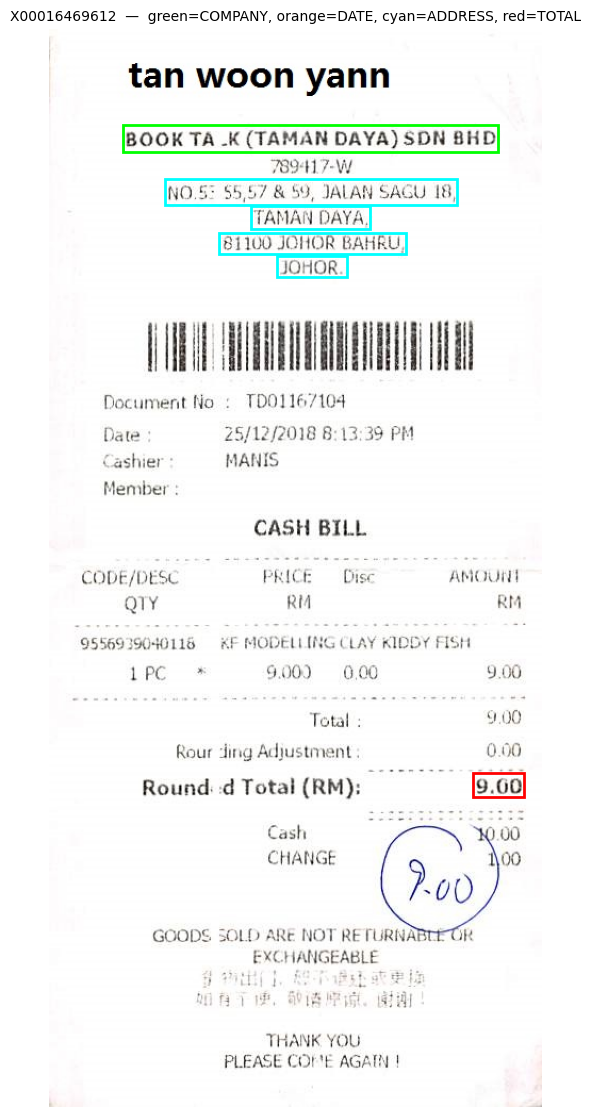

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Map each entity field to a distinct color
LABEL_COLORS = {
    'O':         (1, 1, 1, 0),       # transparent
    'B-COMPANY': 'lime',
    'I-COMPANY': 'lime',
    'B-DATE':    'orange',
    'I-DATE':    'orange',
    'B-ADDRESS': 'cyan',
    'I-ADDRESS': 'cyan',
    'B-TOTAL':   'red',
    'I-TOTAL':   'red',
}

img = Image.open(ocr_data['image_path']).convert('RGB')

fig, ax = plt.subplots(1, figsize=(10, 14))
ax.imshow(img)

for det, label in zip(ocr_data['detections'], labels):
    if label == 'O':
        continue

    # Convert polygon → axis-aligned rectangle
    xs = [p[0] for p in det['bbox_poly']]
    ys = [p[1] for p in det['bbox_poly']]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)

    rect = patches.Rectangle(
        (x0, y0), x1 - x0, y1 - y0,
        linewidth=2,
        edgecolor=LABEL_COLORS[label],
        facecolor='none',
    )
    ax.add_patch(rect)

ax.set_title(
    f"{file_id}  —  green=COMPANY, orange=DATE, cyan=ADDRESS, red=TOTAL",
    fontsize=10,
)
ax.axis('off')
plt.show()

Step 8: Build the full labeled-data structure

In [ ]:
# Combine OCR output + BIO labels into one self-contained record for each receipt.
# This is the schema Day 7 will read.

def build_labeled_record(file_id, ocr_data, entities, fuzz_threshold=80):
    """Combine OCR + ground truth → fully labeled record ready for the processor."""
    labels, scores = generate_bio_labels(ocr_data['detections'], entities,
                                          fuzz_threshold=fuzz_threshold)

    return {
        'file_id':      file_id,
        'image_path':   ocr_data['image_path'],
        'words':        [det['text']       for det in ocr_data['detections']],
        'boxes_pixel':  [det['bbox_poly']  for det in ocr_data['detections']],
        'labels':       labels,
        'label_ids':    [LABEL2ID[l] for l in labels],
        'match_scores': scores,
        'n_tokens':     len(labels),
        'n_labeled':    sum(1 for l in labels if l != 'O'),
    }


# Sanity check on the example
record = build_labeled_record(file_id, ocr_data, entities)
print(f"Record keys: {list(record.keys())}")
print(f"n_tokens:    {record['n_tokens']}")
print(f"n_labeled:   {record['n_labeled']}")
print(f"Match scores: {record['match_scores']}")

Record keys: ['file_id', 'image_path', 'words', 'boxes_pixel', 'labels', 'label_ids', 'match_scores', 'n_tokens', 'n_labeled']
n_tokens:    45
n_labeled:   6
Match scores: {'company': 89.28571428571429, 'date': 68.96551724137932, 'address': 91.72932330827068, 'total': 100.0}


Step 9: Batch generate labels for the full train set

In [ ]:
from tqdm import tqdm

train_ocr_files = sorted(
    f for f in os.listdir(TRAIN_OCR_DIR) if f.endswith('.json')
)
print(f"Generating labels for {len(train_ocr_files)} train receipts...")

stats = {'processed': 0, 'skipped': 0, 'failed': 0,
         'low_quality': 0}  # receipts where ≥2 fields failed to match

for ocr_filename in tqdm(train_ocr_files, desc="Train labels"):
    file_id     = os.path.splitext(ocr_filename)[0]
    output_path = os.path.join(TRAIN_LBL_DIR, f'{file_id}.json')

    # Resumability: skip if already done
    if os.path.exists(output_path):
        stats['skipped'] += 1
        continue

    try:
        # Load OCR + ground truth
        with open(os.path.join(TRAIN_OCR_DIR, ocr_filename), 'r', encoding='utf-8') as f:
            ocr_data = json.load(f)
        ent_path = os.path.join(TRAIN_ENT_DIR, f'{file_id}.txt')
        if not os.path.exists(ent_path):
            stats['failed'] += 1
            continue
        with open(ent_path, 'r', encoding='utf-8') as f:
            entities = json.load(f)

        record = build_labeled_record(file_id, ocr_data, entities)

        # Flag receipts where 2+ fields failed to match (we'll audit these later)
        n_failed_fields = sum(
            1 for f, s in record['match_scores'].items()
            if s is not None and s < 80
        )
        if n_failed_fields >= 2:
            stats['low_quality'] += 1

        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(record, f, indent=2, ensure_ascii=False)

        stats['processed'] += 1

    except Exception as e:
        print(f"\n[FAIL] {file_id}: {type(e).__name__}: {str(e)[:80]}")
        stats['failed'] += 1

print(f"\nTrain labels complete:")
for k, v in stats.items():
    print(f"  {k:>12}: {v}")

Generating labels for 626 train receipts...


Train labels: 100%|██████████| 626/626 [02:59<00:00,  3.49it/s]


Train labels complete:
     processed: 626
       skipped: 0
        failed: 0
   low_quality: 116


Step 10: Batch generate labels for test set

In [ ]:
test_ocr_files = sorted(
    f for f in os.listdir(TEST_OCR_DIR) if f.endswith('.json')
)
print(f"Generating labels for {len(test_ocr_files)} test receipts...")

stats = {'processed': 0, 'skipped': 0, 'failed': 0, 'low_quality': 0}

for ocr_filename in tqdm(test_ocr_files, desc="Test labels"):
    file_id     = os.path.splitext(ocr_filename)[0]
    output_path = os.path.join(TEST_LBL_DIR, f'{file_id}.json')

    if os.path.exists(output_path):
        stats['skipped'] += 1
        continue

    try:
        with open(os.path.join(TEST_OCR_DIR, ocr_filename), 'r', encoding='utf-8') as f:
            ocr_data = json.load(f)
        ent_path = os.path.join(TEST_ENT_DIR, f'{file_id}.txt')
        if not os.path.exists(ent_path):
            stats['failed'] += 1
            continue
        with open(ent_path, 'r', encoding='utf-8') as f:
            entities = json.load(f)

        record = build_labeled_record(file_id, ocr_data, entities)

        n_failed_fields = sum(
            1 for f, s in record['match_scores'].items()
            if s is not None and s < 80
        )
        if n_failed_fields >= 2:
            stats['low_quality'] += 1

        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(record, f, indent=2, ensure_ascii=False)

        stats['processed'] += 1

    except Exception as e:
        print(f"\n[FAIL] {file_id}: {type(e).__name__}: {str(e)[:80]}")
        stats['failed'] += 1

print(f"\nTest labels complete:")
for k, v in stats.items():
    print(f"  {k:>12}: {v}")

Generating labels for 347 test receipts...


Test labels: 100%|██████████| 347/347 [01:42<00:00,  3.40it/s]


Test labels complete:
     processed: 347
       skipped: 0
        failed: 0
   low_quality: 77


Step 11: Audit: label distribution and match quality

In [ ]:
# Dataset-level audit. Three things to check:
#  1. Label distribution — is it severely imbalanced? (yes, but how bad?)
#  2. Per-field average match scores — which fields are hardest to align?
#  3. Receipts with weak matches — how many, and which fields?

from collections import Counter
import numpy as np

label_counts = Counter()
score_lists  = {field: [] for field in ENTITY_FIELDS}
match_failures_by_field = Counter()

for filename in sorted(os.listdir(TRAIN_LBL_DIR)):
    if not filename.endswith('.json'):
        continue
    with open(os.path.join(TRAIN_LBL_DIR, filename), 'r', encoding='utf-8') as f:
        rec = json.load(f)
    label_counts.update(rec['labels'])
    for field, score in rec['match_scores'].items():
        if score is None:
            continue
        score_lists[field].append(score)
        if score < 80:
            match_failures_by_field[field] += 1

total_tokens = sum(label_counts.values())

print(f"=== Label distribution (train, {total_tokens:,} tokens total) ===\n")
print(f"  {'label':<12}  {'count':>7}  {'%':>5}")
for label in LABELS:
    c = label_counts.get(label, 0)
    pct = 100.0 * c / total_tokens
    print(f"  {label:<12}  {c:>7,}  {pct:>5.2f}")

print(f"\n=== Per-field match quality ===\n")
print(f"  {'field':>8}  {'mean':>6}  {'p5':>4}  {'p50':>4}  {'p95':>4}  {'< 80':>5}")
for field in ENTITY_FIELDS:
    scores = np.array(score_lists[field])
    if len(scores) == 0:
        continue
    print(f"  {field:>8}  {scores.mean():>6.1f}  "
          f"{int(np.percentile(scores, 5)):>4}  "
          f"{int(np.percentile(scores, 50)):>4}  "
          f"{int(np.percentile(scores, 95)):>4}  "
          f"{match_failures_by_field[field]:>5}")

=== Label distribution (train, 35,777 tokens total) ===

  label           count      %
  O              32,739  91.51
  B-COMPANY         487   1.36
  I-COMPANY         111   0.31
  B-DATE            290   0.81
  I-DATE              0   0.00
  B-ADDRESS         566   1.58
  I-ADDRESS         988   2.76
  B-TOTAL           596   1.67
  I-TOTAL             0   0.00

=== Per-field match quality ===

     field    mean    p5   p50   p95   < 80
   company    86.1    39    94   100    139
      date    74.8    45    76   100    336
   address    90.6    40    95   100     59
     total    97.5    80   100   100     29


**START OF DAY 7**

Step 0: Reconnect the colab notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR     = '/content/drive/MyDrive/doc-understanding'
TRAIN_LBL_DIR   = f'{PROJECT_DIR}/outputs/labels/train'
TEST_LBL_DIR    = f'{PROJECT_DIR}/outputs/labels/test'
SPLITS_PATH     = f'{PROJECT_DIR}/outputs/splits.json'

for path in [TRAIN_LBL_DIR, TEST_LBL_DIR]:
    assert os.path.exists(path), f"Missing: {path}"

print("Paths verified.")

Mounted at /content/drive
Paths verified.


Step 1: Install *transformers*

In [ ]:
!pip install -q "transformers>=4.40" "torch" "scikit-learn"

Step 2: Redefine the label scheme

In [ ]:
# Re-declare here so this notebook runs end-to-end without Day 6 in memory.

ENTITY_FIELDS = ['company', 'date', 'address', 'total']

LABELS = [
    'O',
    'B-COMPANY', 'I-COMPANY',
    'B-DATE',    'I-DATE',
    'B-ADDRESS', 'I-ADDRESS',
    'B-TOTAL',   'I-TOTAL',
]
NUM_LABELS = len(LABELS)
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for i, label in enumerate(LABELS)}

print(f"Num labels: {NUM_LABELS}")

Num labels: 9


Step 3: Load all labeled records into memory

In [ ]:
# Read every per-receipt JSON Day 6 generated.

import json

def load_records(label_dir):
    """Load all per-receipt JSON labeled records from a directory."""
    records = []
    for filename in sorted(os.listdir(label_dir)):
        if not filename.endswith('.json'):
            continue
        with open(os.path.join(label_dir, filename), 'r', encoding='utf-8') as f:
            records.append(json.load(f))
    return records


all_train_records = load_records(TRAIN_LBL_DIR)
test_records      = load_records(TEST_LBL_DIR)

print(f"Loaded train records: {len(all_train_records)}")
print(f"Loaded test records : {len(test_records)}")
print(f"\nFirst train record keys: {list(all_train_records[0].keys())}")

Loaded train records: 626
Loaded test records : 347

First train record keys: ['file_id', 'image_path', 'words', 'boxes_pixel', 'labels', 'label_ids', 'match_scores', 'n_tokens', 'n_labeled']


Step 4: Carve out a validation split

In [ ]:
# Reproducible 90/10 split of the training data into train and val.
# random_state=42 ensures the same split every time you re-run.

from sklearn.model_selection import train_test_split

train_records, val_records = train_test_split(
    all_train_records,
    test_size=0.10,
    random_state=42,
    shuffle=True,
)

print(f"Train split: {len(train_records)}")
print(f"Val split  : {len(val_records)}")
print(f"Test (frozen): {len(test_records)}")

Train split: 563
Val split  : 63
Test (frozen): 347


Step 5: Save the split assignments

In [ ]:
# Persist split assignments by file_id so we never accidentally re-shuffle.

splits = {
    'train': [r['file_id'] for r in train_records],
    'val':   [r['file_id'] for r in val_records],
    'test':  [r['file_id'] for r in test_records],
}

os.makedirs(os.path.dirname(SPLITS_PATH), exist_ok=True)
with open(SPLITS_PATH, 'w', encoding='utf-8') as f:
    json.dump(splits, f, indent=2)

print(f"Saved splits to {SPLITS_PATH}")
print(f"  train: {len(splits['train'])} file IDs")
print(f"  val  : {len(splits['val'])} file IDs")
print(f"  test : {len(splits['test'])} file IDs")

Saved splits to /content/drive/MyDrive/doc-understanding/outputs/splits.json
  train: 563 file IDs
  val  : 63 file IDs
  test : 347 file IDs


Step 6: Load the LayoutLMv3 processor


In [ ]:
# Same as Day 5. apply_ocr=False because we provide words and boxes ourselves.

from transformers import LayoutLMv3Processor

MODEL_NAME = "microsoft/layoutlmv3-base"
processor = LayoutLMv3Processor.from_pretrained(MODEL_NAME, apply_ocr=False)
print("Processor loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Processor loaded.


Step 7: Write the encoding function

This is the function that turns one labeled record into a dict of tensors ready for the model.

In [ ]:
# The function that converts: labeled record → model-ready tensors.
# Handles bbox normalization and delegates subword label alignment to the processor.

from PIL import Image

MAX_LENGTH = 512   # LayoutLMv3's hard limit; matches model.config.max_position_embeddings - 2


def normalize_box(polygon, img_width, img_height):
    """Pixel polygon → axis-aligned [x0, y0, x1, y1] normalized to [0, 1000]."""
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / img_width))),
        max(0, min(1000, int(1000 * y0 / img_height))),
        max(0, min(1000, int(1000 * x1 / img_width))),
        max(0, min(1000, int(1000 * y1 / img_height))),
    ]


def encode_record(record, processor, max_length=MAX_LENGTH):
    """
    Encode one labeled record into model-input tensors.

    The processor handles:
      - WordPiece subword tokenization of `words`
      - Bbox propagation to subword tokens (continuations inherit parent bbox)
      - Image resizing/normalization
      - Padding to max_length
      - Subword label alignment (first subword gets the word's label, rest get -100)
    """
    img = Image.open(record['image_path']).convert('RGB')
    W, H = img.size

    boxes = [normalize_box(poly, W, H) for poly in record['boxes_pixel']]

    encoded = processor(
        img,
        record['words'],
        boxes=boxes,
        word_labels=record['label_ids'],   # the magic kwarg that triggers label alignment
        return_tensors='pt',
        truncation=True,
        padding='max_length',
        max_length=max_length,
    )

    return encoded

Step 8: Define the Dataset class

In [ ]:
# Standard PyTorch Dataset wrapping our list of labeled records.

import torch
from torch.utils.data import Dataset


class SROIEDataset(Dataset):
    """
    A PyTorch Dataset over labeled SROIE receipts.

    Each sample is a dict of tensors ready to be passed to LayoutLMv3:
      - input_ids       (seq_len,)
      - attention_mask  (seq_len,)
      - bbox            (seq_len, 4)
      - pixel_values    (3, 224, 224)
      - labels          (seq_len,)
    """

    def __init__(self, records, processor, max_length=MAX_LENGTH):
        self.records   = records
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        encoded = encode_record(record, self.processor, self.max_length)
        # The processor returns tensors with a leading batch dimension of 1.
        # Dataset's contract is to return one un-batched sample, so we squeeze.
        return {k: v.squeeze(0) for k, v in encoded.items()}

Step 9: Instantiate the three datasets

In [ ]:
train_ds = SROIEDataset(train_records, processor)
val_ds   = SROIEDataset(val_records,   processor)
test_ds  = SROIEDataset(test_records,  processor)

print(f"train_ds: {len(train_ds)}")
print(f"val_ds  : {len(val_ds)}")
print(f"test_ds : {len(test_ds)}")

train_ds: 563
val_ds  : 63
test_ds : 347


Step 10: Inspect one encoded example

In [ ]:
# Sanity check: fetch one sample, print tensor shapes and a label slice.

example = train_ds[0]

print("=== Tensor shapes ===")
for k, v in example.items():
    print(f"  {k:<15} shape: {str(tuple(v.shape)):<20} dtype: {v.dtype}")

print(f"\nUnique labels in this example (excluding -100):")
labels = example['labels']
non_ignored = labels[labels != -100]
unique = torch.unique(non_ignored).tolist()
for uid in unique:
    print(f"  {uid:>3}  →  {ID2LABEL[uid]}")

=== Tensor shapes ===
  input_ids       shape: (512,)               dtype: torch.int64
  attention_mask  shape: (512,)               dtype: torch.int64
  bbox            shape: (512, 4)             dtype: torch.int64
  labels          shape: (512,)               dtype: torch.int64
  pixel_values    shape: (3, 224, 224)        dtype: torch.float32

Unique labels in this example (excluding -100):
    0  →  O
    3  →  B-DATE
    5  →  B-ADDRESS
    6  →  I-ADDRESS
    7  →  B-TOTAL


Step 11: Verify subword label alignment

In [ ]:
# Print the first 30 (token, label_id, label_name) triplets to inspect alignment.

example = train_ds[0]
ids    = example['input_ids']
labels = example['labels']
tokens = processor.tokenizer.convert_ids_to_tokens(ids)

print(f"{'idx':>3}  {'token':<20}  {'lbl_id':>6}  {'label':<14}")
print('-' * 55)
for i in range(30):
    lid = labels[i].item()
    lbl = '-100 (ignore)' if lid == -100 else ID2LABEL[lid]
    print(f"{i:>3}  {tokens[i]!r:<20}  {lid:>6}  {lbl:<14}")

idx  token                 lbl_id  label         
-------------------------------------------------------
  0  '<s>'                   -100  -100 (ignore) 
  1  'Ġ99'                      0  O             
  2  'ĠSP'                   -100  -100 (ignore) 
  3  'EED'                   -100  -100 (ignore) 
  4  'MAR'                   -100  -100 (ignore) 
  5  'TS'                    -100  -100 (ignore) 
  6  '/'                     -100  -100 (ignore) 
  7  'B'                     -100  -100 (ignore) 
  8  'Ġï'                    -100  -100 (ignore) 
  9  '¼'                     -100  -100 (ignore) 
 10  'Ī'                     -100  -100 (ignore) 
 11  '5'                     -100  -100 (ignore) 
 12  '195'                   -100  -100 (ignore) 
 13  '37'                    -100  -100 (ignore) 
 14  '-'                     -100  -100 (ignore) 
 15  'X'                     -100  -100 (ignore) 
 16  'ï'                     -100  -100 (ignore) 
 17  '¼'                     -100  -100 (ign

Step 12: Build a DataLoader

In [ ]:
# DataLoader handles batching, shuffling, and (eventually) multi-worker prefetching.

from torch.utils.data import DataLoader


def collate_fn(batch):
    """Stack a list of single-sample dicts into a batched dict."""
    return {k: torch.stack([sample[k] for sample in batch]) for k in batch[0]}


train_loader = DataLoader(
    train_ds,
    batch_size=2,           # tiny batch for the CPU smoke test; we'll raise on GPU
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,          # 0 = single-process loading; Colab is happiest with 0
)

val_loader = DataLoader(
    val_ds,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

print(f"train batches per epoch: {len(train_loader)}")
print(f"val batches per epoch  : {len(val_loader)}")

train batches per epoch: 282
val batches per epoch  : 32


Step 13: Inspect one batch

In [ ]:
# Fetch one batch from the loader and verify shapes.

batch = next(iter(train_loader))

print("=== Batch tensor shapes ===")
for k, v in batch.items():
    print(f"  {k:<15} shape: {str(tuple(v.shape)):<25} dtype: {v.dtype}")

=== Batch tensor shapes ===
  input_ids       shape: (2, 512)                  dtype: torch.int64
  attention_mask  shape: (2, 512)                  dtype: torch.int64
  bbox            shape: (2, 512, 4)               dtype: torch.int64
  labels          shape: (2, 512)                  dtype: torch.int64
  pixel_values    shape: (2, 3, 224, 224)          dtype: torch.float32


Step 14: Count receipts that hit the 512-token cap

In [ ]:
import numpy as np

n_truncated    = 0
worst_overflow = 0
all_lengths    = []

for record in train_records:
    n_words = len(record['words'])
    dummy_boxes = [[0, 0, 0, 0]] * n_words

    encoding = processor.tokenizer(
        record['words'],
        boxes=dummy_boxes,
        add_special_tokens=True,
        truncation=False,
    )
    total_tokens = len(encoding['input_ids'])
    all_lengths.append(total_tokens)

    if total_tokens > MAX_LENGTH:
        n_truncated   += 1
        worst_overflow = max(worst_overflow, total_tokens)

lengths = np.array(all_lengths)
pct = 100.0 * n_truncated / len(train_records)

print(f"Train receipts hitting the {MAX_LENGTH}-token cap: {n_truncated} / {len(train_records)} ({pct:.1f}%)")
print(f"Worst case: {worst_overflow} subword tokens (would lose {worst_overflow - MAX_LENGTH} from the tail)")
print()
print(f"Token-length distribution:")
print(f"  min  : {lengths.min()}")
print(f"  p25  : {int(np.percentile(lengths, 25))}")
print(f"  p50  : {int(np.percentile(lengths, 50))}")
print(f"  p75  : {int(np.percentile(lengths, 75))}")
print(f"  p95  : {int(np.percentile(lengths, 95))}")
print(f"  max  : {lengths.max()}")

Token indices sequence length is longer than the specified maximum sequence length for this model (516 > 512). Running this sequence through the model will result in indexing errors


Train receipts hitting the 512-token cap: 6 / 563 (1.1%)
Worst case: 604 subword tokens (would lose 92 from the tail)

Token-length distribution:
  min  : 92
  p25  : 223
  p50  : 264
  p75  : 321
  p95  : 403
  max  : 604


**START OF DAY 8**

Step 0: Reconnect the colab notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json

PROJECT_DIR     = '/content/drive/MyDrive/doc-understanding'
TRAIN_LBL_DIR   = f'{PROJECT_DIR}/outputs/labels/train'
TEST_LBL_DIR    = f'{PROJECT_DIR}/outputs/labels/test'
SPLITS_PATH     = f'{PROJECT_DIR}/outputs/splits.json'

CHECKPOINT_DIR  = f'{PROJECT_DIR}/models/layoutlmv3_day08'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print("Paths configured.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths configured.


Step 1: Install packages

In [ ]:
!pip install -q "transformers>=4.40" "torch" "scikit-learn" "seqeval"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Step 2: Re-declare label scheme

In [ ]:
LABELS = [
    'O',
    'B-COMPANY', 'I-COMPANY',
    'B-DATE',    'I-DATE',
    'B-ADDRESS', 'I-ADDRESS',
    'B-TOTAL',   'I-TOTAL',
]
NUM_LABELS = len(LABELS)
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for i, label in enumerate(LABELS)}

print(f"NUM_LABELS: {NUM_LABELS}")

NUM_LABELS: 9


Step 3: Reload records and reconstruct splits

In [ ]:
# Load the labeled JSONs and the saved splits from Day 7.

def load_records(label_dir):
    records = []
    for fn in sorted(os.listdir(label_dir)):
        if fn.endswith('.json'):
            with open(os.path.join(label_dir, fn), 'r', encoding='utf-8') as f:
                records.append(json.load(f))
    return records


In [ ]:
all_train_records = load_records(TRAIN_LBL_DIR)
test_records      = load_records(TEST_LBL_DIR)

with open(SPLITS_PATH, 'r', encoding='utf-8') as f:
    splits = json.load(f)

# Index all_train by file_id, then reconstruct train/val using the saved splits
fid_to_record = {r['file_id']: r for r in all_train_records}
train_records = [fid_to_record[fid] for fid in splits['train']]
val_records   = [fid_to_record[fid] for fid in splits['val']]

print(f"Train: {len(train_records)}")
print(f"Val  : {len(val_records)}")
print(f"Test : {len(test_records)}")

Train: 563
Val  : 63
Test : 347


Step 4: Recreate processor and Dataset class

In [ ]:
from transformers import LayoutLMv3Processor
from torch.utils.data import Dataset
from PIL import Image

MODEL_NAME = "microsoft/layoutlmv3-base"
MAX_LENGTH = 512

processor = LayoutLMv3Processor.from_pretrained(MODEL_NAME, apply_ocr=False)


def normalize_box(polygon, img_width, img_height):
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / img_width))),
        max(0, min(1000, int(1000 * y0 / img_height))),
        max(0, min(1000, int(1000 * x1 / img_width))),
        max(0, min(1000, int(1000 * y1 / img_height))),
    ]


def encode_record(record, processor, max_length=MAX_LENGTH):
    img = Image.open(record['image_path']).convert('RGB')
    W, H = img.size
    boxes = [normalize_box(poly, W, H) for poly in record['boxes_pixel']]
    return processor(
        img, record['words'], boxes=boxes,
        word_labels=record['label_ids'],
        return_tensors='pt',
        truncation=True, padding='max_length', max_length=max_length,
    )


class SROIEDataset(Dataset):
    def __init__(self, records, processor, max_length=MAX_LENGTH):
        self.records   = records
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        encoded = encode_record(self.records[idx], self.processor, self.max_length)
        return {k: v.squeeze(0) for k, v in encoded.items()}


train_ds = SROIEDataset(train_records, processor)
val_ds   = SROIEDataset(val_records,   processor)
print(f"Datasets ready: train={len(train_ds)}, val={len(val_ds)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Datasets ready: train=563, val=63


Step 5: Load LayoutLMv3 with a classification head

In [ ]:
# This is the new model class: LayoutLMv3 base + a 9-class linear head on top.
# When num_labels=9 is passed, HuggingFace creates the head with random weights.
# You will see a warning about uninitialized weights — that is EXPECTED.

from transformers import LayoutLMv3ForTokenClassification

model = LayoutLMv3ForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

model = model.to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model on device: {next(model.parameters()).device}")
print(f"Total parameters    : {n_params:,}")
print(f"Trainable parameters: {n_trainable:,}")

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.weight                  | MISSING    | 
classifier.bias                    | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model on device: cuda:0
Total parameters    : 125,333,897
Trainable parameters: 125,333,897


Step 6: Build DataLoaders

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4   # safe for T4 with max_length=512

def collate_fn(batch):
    return {k: torch.stack([s[k] for s in batch]) for k in batch[0]}


train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=0,
)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Val batches per epoch  : {len(val_loader)}")

Train batches per epoch: 141
Val batches per epoch  : 16


Step 7: Set up optimizer and scheduler\

In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

NUM_EPOCHS    = 3
LEARNING_RATE = 5e-5
WEIGHT_DECAY  = 0.01
WARMUP_STEPS  = 100

# AdamW: Adam optimizer with decoupled weight decay, standard for transformer fine-tuning.
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps,
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps       : {WARMUP_STEPS}")

Total training steps: 423
Warmup steps       : 100


Step 8: Set random seeds for reproducibility

In [ ]:
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f"Seeds set to {SEED}")

Seeds set to 42


Step 9: The training loop

In [ ]:
# The actual training. Three nested loops:
#   - For each epoch
#   - For each batch in the train loader: forward, backward, step
#   - For each batch in the val loader: forward only, measure loss

from tqdm import tqdm

train_losses = []
val_losses   = []

for epoch in range(NUM_EPOCHS):
    # ===== Training phase =====
    model.train()
    epoch_train_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} train")
    for batch in train_pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss    = outputs.loss          # CE loss with -100 ignore, automatic
        loss.backward()
        optimizer.step()
        scheduler.step()

        epoch_train_loss += loss.item()
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ===== Validation phase =====
    model.eval()
    epoch_val_loss = 0.0
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} val")
    with torch.no_grad():
        for batch in val_pbar:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)
            epoch_val_loss += outputs.loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"\nEpoch {epoch+1}: "
          f"train_loss={avg_train_loss:.4f}, val_loss={avg_val_loss:.4f}\n")

    # ===== Save checkpoint =====
    epoch_ckpt = os.path.join(CHECKPOINT_DIR, f'epoch_{epoch+1}')
    model.save_pretrained(epoch_ckpt)
    processor.save_pretrained(epoch_ckpt)
    print(f"Saved: {epoch_ckpt}\n")

Epoch 1/3 val: 100%|██████████| 16/16 [00:53<00:00,  3.33s/it]



Epoch 1: train_loss=0.4779, val_loss=0.1030



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day08/epoch_1



Epoch 2/3 val: 100%|██████████| 16/16 [00:11<00:00,  1.42it/s]

...

Saved: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day08/epoch_2



Epoch 3/3 val: 100%|██████████| 16/16 [00:11<00:00,  1.44it/s]


Epoch 3: train_loss=0.0344, val_loss=0.0300



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day08/epoch_3



Step 10: Plot the loss curves

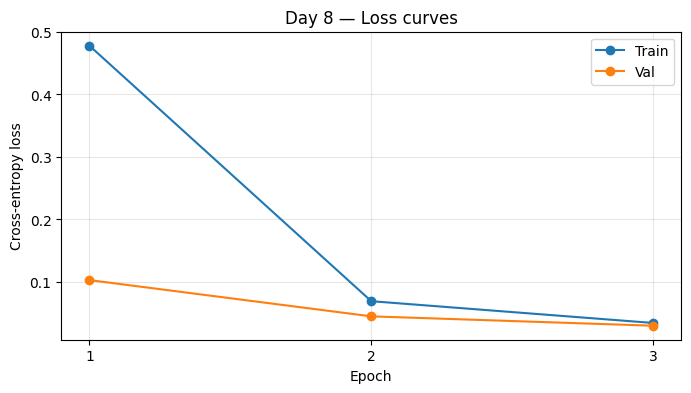

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', label='Train')
plt.plot(range(1, NUM_EPOCHS + 1), val_losses,   marker='o', label='Val')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Day 8 — Loss curves')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(range(1, NUM_EPOCHS + 1))
plt.show()

Step 11: Reload the saved checkpoint and verify

In [ ]:
# Load the last-epoch checkpoint into a fresh model object.
# This is the "production deployment" pattern: train on one machine, load and
# infer on another.

last_ckpt = os.path.join(CHECKPOINT_DIR, f'epoch_{NUM_EPOCHS}')

loaded_model = LayoutLMv3ForTokenClassification.from_pretrained(last_ckpt)
loaded_model = loaded_model.to(DEVICE)
loaded_model.eval()

print(f"Loaded checkpoint from: {last_ckpt}")
print(f"On device: {next(loaded_model.parameters()).device}")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Loaded checkpoint from: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day08/epoch_3
On device: cuda:0


Step 12: Inference on one validation example

In [ ]:
# Pick one val example, run inference, decode the predictions back to BIO labels.

example_idx = 0
example = val_ds[example_idx]
# Add a batch dimension (single-example inference)
example = {k: v.unsqueeze(0).to(DEVICE) for k, v in example.items()}

with torch.no_grad():
    outputs = loaded_model(**example)
    # logits: (batch=1, seq_len=512, num_labels=9)
    pred_ids = outputs.logits.argmax(dim=-1)[0]  # (seq_len,)

# Display the first 25 non-padding tokens with their predicted vs gold labels
input_ids = example['input_ids'][0]
true_ids  = example['labels'][0]
attn_mask = example['attention_mask'][0]

tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)

print(f"{'idx':>3}  {'token':<18}  {'true':<14}  {'pred':<14}")
print('-' * 60)
shown = 0
for i in range(len(tokens)):
    if attn_mask[i].item() == 0:    # skip padding
        break
    true_lbl = '-100 (ignore)' if true_ids[i].item() == -100 else ID2LABEL[true_ids[i].item()]
    pred_lbl = ID2LABEL[pred_ids[i].item()]
    print(f"{i:>3}  {tokens[i]!r:<18}  {true_lbl:<14}  {pred_lbl:<14}")
    shown += 1
    if shown >= 25:
        break

idx  token               true            pred          
------------------------------------------------------------
  0  '<s>'               -100 (ignore)   O             
  1  'ĠMR'               B-COMPANY       B-COMPANY     
  2  '.'                 -100 (ignore)   B-COMPANY     
  3  'D'                 -100 (ignore)   B-COMPANY     
  4  '.'                 -100 (ignore)   B-COMPANY     
  5  'I'                 -100 (ignore)   B-COMPANY     
  6  '.'                 -100 (ignore)   B-COMPANY     
  7  'Y'                 -100 (ignore)   B-COMPANY     
  8  '.('                -100 (ignore)   B-COMPANY     
  9  'M'                 -100 (ignore)   B-COMPANY     
 10  ')'                 -100 (ignore)   B-COMPANY     
 11  'ĠSD'               -100 (ignore)   B-COMPANY     
 12  'N'                 -100 (ignore)   I-COMPANY     
 13  'ĠB'                -100 (ignore)   I-COMPANY     
 14  'HD'                -100 (ignore)   B-COMPANY     
 15  'Ġ('                O               O 

**START OF DAY 9**

Step 0: Reconnect the colab notebook

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json

PROJECT_DIR     = '/content/drive/MyDrive/doc-understanding'
TRAIN_LBL_DIR   = f'{PROJECT_DIR}/outputs/labels/train'
TEST_LBL_DIR    = f'{PROJECT_DIR}/outputs/labels/test'
SPLITS_PATH     = f'{PROJECT_DIR}/outputs/splits.json'

# New checkpoint dir for Day 9 — keep separate from Day 8
CHECKPOINT_DIR  = f'{PROJECT_DIR}/models/layoutlmv3_day09'
BEST_CKPT_DIR   = f'{CHECKPOINT_DIR}/best'
LAST_CKPT_DIR   = f'{CHECKPOINT_DIR}/last'
METRICS_PATH    = f'{CHECKPOINT_DIR}/training_metrics.json'

os.makedirs(BEST_CKPT_DIR, exist_ok=True)
os.makedirs(LAST_CKPT_DIR, exist_ok=True)
print(f"Checkpoint dir: {CHECKPOINT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checkpoint dir: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day09


Step 1: Install packages

In [ ]:
!pip install -q "transformers>=4.40" "torch" "scikit-learn" "seqeval"

Step 2: Re-declare label scheme

In [ ]:
LABELS = [
    'O',
    'B-COMPANY', 'I-COMPANY',
    'B-DATE',    'I-DATE',
    'B-ADDRESS', 'I-ADDRESS',
    'B-TOTAL',   'I-TOTAL',
]
NUM_LABELS = len(LABELS)
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for i, label in enumerate(LABELS)}

Step 3: Reload records, splits, Dataset class


In [ ]:
# Same as Day 8 — self-contained replay of the data pipeline.

from transformers import LayoutLMv3Processor
from torch.utils.data import Dataset
from PIL import Image

MODEL_NAME = "microsoft/layoutlmv3-base"
MAX_LENGTH = 512


def load_records(label_dir):
    records = []
    for fn in sorted(os.listdir(label_dir)):
        if fn.endswith('.json'):
            with open(os.path.join(label_dir, fn), 'r', encoding='utf-8') as f:
                records.append(json.load(f))
    return records


def normalize_box(polygon, img_width, img_height):
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / img_width))),
        max(0, min(1000, int(1000 * y0 / img_height))),
        max(0, min(1000, int(1000 * x1 / img_width))),
        max(0, min(1000, int(1000 * y1 / img_height))),
    ]


def encode_record(record, processor, max_length=MAX_LENGTH):
    img = Image.open(record['image_path']).convert('RGB')
    W, H = img.size
    boxes = [normalize_box(p, W, H) for p in record['boxes_pixel']]
    return processor(
        img, record['words'], boxes=boxes,
        word_labels=record['label_ids'],
        return_tensors='pt',
        truncation=True, padding='max_length', max_length=max_length,
    )


class SROIEDataset(Dataset):
    def __init__(self, records, processor, max_length=MAX_LENGTH):
        self.records = records
        self.processor = processor
        self.max_length = max_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        encoded = encode_record(self.records[idx], self.processor, self.max_length)
        return {k: v.squeeze(0) for k, v in encoded.items()}


processor = LayoutLMv3Processor.from_pretrained(MODEL_NAME, apply_ocr=False)

all_train_records = load_records(TRAIN_LBL_DIR)
test_records      = load_records(TEST_LBL_DIR)

with open(SPLITS_PATH, 'r', encoding='utf-8') as f:
    splits = json.load(f)

fid_to_record = {r['file_id']: r for r in all_train_records}
train_records = [fid_to_record[fid] for fid in splits['train']]
val_records   = [fid_to_record[fid] for fid in splits['val']]

train_ds = SROIEDataset(train_records, processor)
val_ds   = SROIEDataset(val_records,   processor)
print(f"train_ds: {len(train_ds)}, val_ds: {len(val_ds)}")

train_ds: 563, val_ds: 63


Step 4: Load a fresh model (from pretrained, not from Day 8 checkpoint)


In [ ]:
# Resume from Day 8's epoch_3 checkpoint instead of starting fresh.
# Saves ~10 min of compute. We still get 9 more epochs of training and the
# new best-checkpoint tracking benefits.

from transformers import LayoutLMv3ForTokenClassification

DAY8_CHECKPOINT = f'{PROJECT_DIR}/models/layoutlmv3_day08/epoch_3'

model = LayoutLMv3ForTokenClassification.from_pretrained(
    DAY8_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)
model = model.to(DEVICE)
print(f"Resumed from: {DAY8_CHECKPOINT}")
print(f"On device   : {next(model.parameters()).device}")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Resumed from: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day08/epoch_3
On device   : cuda:0


Step 5: DataLoaders

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

def collate_fn(batch):
    return {k: torch.stack([s[k] for s in batch]) for k in batch[0]}


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f"Train batches/epoch: {len(train_loader)}")
print(f"Val batches/epoch  : {len(val_loader)}")

Train batches/epoch: 141
Val batches/epoch  : 16


Step 6: Optimizer and scheduler (for 12 epochs)

In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

NUM_EPOCHS    = 9
LEARNING_RATE = 5e-5
WEIGHT_DECAY  = 0.01
WARMUP_STEPS  = 0

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps,
)
print(f"Total steps: {total_steps}, warmup: {WARMUP_STEPS}")

Total steps: 1269, warmup: 0


Step 7: Define metric functions

In [ ]:
# Two metric functions used during validation.

def compute_token_accuracy(predictions, labels):
    """
    Token-level accuracy, ignoring -100 positions.
    predictions: tensor of shape (batch, seq_len), argmax predicted IDs
    labels:      tensor of shape (batch, seq_len), with -100 for ignored positions
    """
    mask = labels != -100
    correct = ((predictions == labels) & mask).sum().item()
    total   = mask.sum().item()
    return correct / total if total > 0 else 0.0


def compute_per_class_accuracy(predictions, labels, num_labels):
    """
    Recall-style per-class accuracy: for each class c, of all positions where
    the true label is c, what fraction did the model predict as c?
    Returns: dict {label_name: accuracy}
    """
    result = {}
    for c in range(num_labels):
        mask = (labels == c)
        total_c = mask.sum().item()
        if total_c == 0:
            result[ID2LABEL[c]] = None    # this class doesn't appear in the val data
            continue
        correct_c = ((predictions == c) & mask).sum().item()
        result[ID2LABEL[c]] = correct_c / total_c
    return result

Step 8: The training loop with best-checkpoint tracking

In [ ]:
from tqdm import tqdm
import json as _json

train_losses    = []
val_losses      = []
val_accuracies  = []
val_per_class   = []

best_val_loss   = float('inf')
best_epoch      = -1

for epoch in range(NUM_EPOCHS):
    # ====== TRAIN ======
    model.train()
    epoch_train_loss = 0.0

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} train")
    for batch in train_pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer.zero_grad()
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        scheduler.step()

        epoch_train_loss += loss.item()
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ====== VAL ======
    model.eval()
    epoch_val_loss = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} val"):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = model(**batch)

            epoch_val_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1)    # (batch, seq_len)
            all_preds.append(preds.cpu())
            all_labels.append(batch['labels'].cpu())

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Concatenate all batches' predictions and labels for metric computation
    all_preds  = torch.cat(all_preds,  dim=0)        # (total_val_examples, seq_len)
    all_labels = torch.cat(all_labels, dim=0)

    token_acc = compute_token_accuracy(all_preds, all_labels)
    per_class = compute_per_class_accuracy(all_preds, all_labels, NUM_LABELS)
    val_accuracies.append(token_acc)
    val_per_class.append(per_class)

    print(f"\nEpoch {epoch+1:>2}: train={avg_train_loss:.4f}  "
          f"val={avg_val_loss:.4f}  token_acc={token_acc:.4f}")

    # ====== CHECKPOINT MANAGEMENT ======
    # Always save 'last'
    model.save_pretrained(LAST_CKPT_DIR)
    processor.save_pretrained(LAST_CKPT_DIR)

    # Save 'best' only if val improved
    if avg_val_loss < best_val_loss:
        improvement = best_val_loss - avg_val_loss
        best_val_loss = avg_val_loss
        best_epoch    = epoch + 1
        model.save_pretrained(BEST_CKPT_DIR)
        processor.save_pretrained(BEST_CKPT_DIR)
        print(f"  ✓ Best so far (val improved by {improvement:.4f}) → saved to best/\n")
    else:
        print(f"  (no improvement; best is still epoch {best_epoch})\n")

# ====== SAVE METRICS FOR LATER PLOTTING ======
metrics = {
    'train_losses':   train_losses,
    'val_losses':     val_losses,
    'val_accuracies': val_accuracies,
    'val_per_class':  val_per_class,
    'best_epoch':     best_epoch,
    'best_val_loss':  best_val_loss,
}
with open(METRICS_PATH, 'w', encoding='utf-8') as f:
    _json.dump(metrics, f, indent=2)

print(f"\n=== Training complete ===")
print(f"Best val_loss: {best_val_loss:.4f} at epoch {best_epoch}")
print(f"Metrics saved to: {METRICS_PATH}")

Epoch 1/9 val: 100%|██████████| 16/16 [00:10<00:00,  1.52it/s]


Epoch  1: train=0.0555  val=0.0369  token_acc=0.9881


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best so far (val improved by inf) → saved to best/



...

  (no improvement; best is still epoch 3)



Epoch 9/9 val: 100%|██████████| 16/16 [00:09<00:00,  1.65it/s]


Epoch  9: train=0.0016  val=0.0399  token_acc=0.9927


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  (no improvement; best is still epoch 3)


=== Training complete ===
Best val_loss: 0.0274 at epoch 3
Metrics saved to: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day09/training_metrics.json


Step 9: Plot loss + accuracy curves

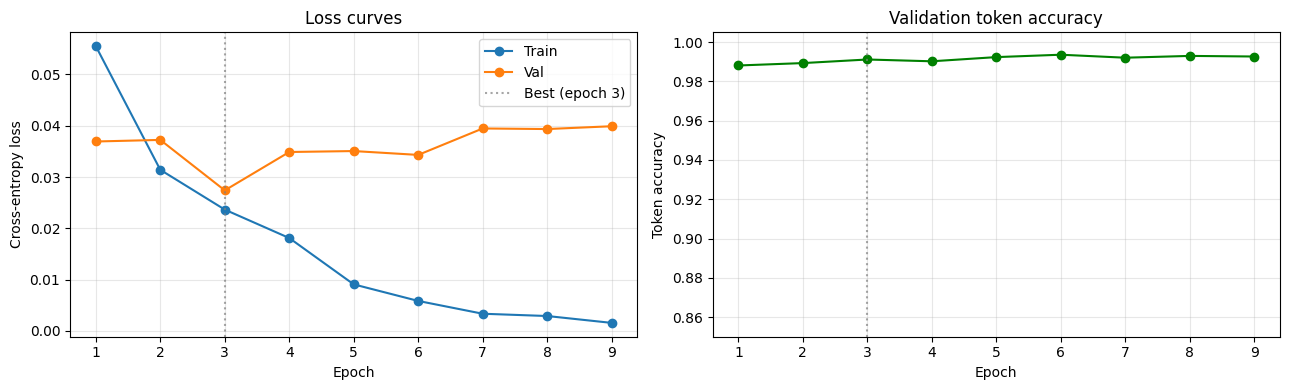

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: loss curves
axes[0].plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', label='Train')
axes[0].plot(range(1, NUM_EPOCHS + 1), val_losses,   marker='o', label='Val')
axes[0].axvline(best_epoch, color='gray', linestyle=':', alpha=0.7, label=f'Best (epoch {best_epoch})')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-entropy loss')
axes[0].set_title('Loss curves')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: val token accuracy
axes[1].plot(range(1, NUM_EPOCHS + 1), val_accuracies, marker='o', color='green')
axes[1].axvline(best_epoch, color='gray', linestyle=':', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Token accuracy')
axes[1].set_title('Validation token accuracy')
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.85, 1.005)

plt.tight_layout()
plt.show()

Step 10: Per-class accuracy at the best epoch

In [ ]:
# Final per-class breakdown at the best-val-loss epoch.

best_per_class = val_per_class[best_epoch - 1]

print(f"Per-class accuracy at best epoch ({best_epoch}):\n")
print(f"  {'label':<14}  {'accuracy':>9}")
print('-' * 30)
for label in LABELS:
    acc = best_per_class.get(label)
    if acc is None:
        print(f"  {label:<14}  {'—':>9} (no examples in val)")
    else:
        print(f"  {label:<14}  {acc:>9.4f}")

Per-class accuracy at best epoch (3):

  label            accuracy
------------------------------
  O                  0.9950
  B-COMPANY          0.9216
  I-COMPANY          0.4000
  B-DATE             1.0000
  I-DATE                  — (no examples in val)
  B-ADDRESS          1.0000
  I-ADDRESS          0.9720
  B-TOTAL            0.9344
  I-TOTAL                 — (no examples in val)


Step 11: Load best checkpoint and run inference on multiple receipts

In [ ]:
# Load the best-val-loss checkpoint and run inference on 5 val examples.
# Visual sanity check: do the predictions match the gold labels in obvious ways?

best_model = LayoutLMv3ForTokenClassification.from_pretrained(BEST_CKPT_DIR)
best_model = best_model.to(DEVICE)
best_model.eval()

print(f"Loaded best checkpoint from epoch {best_epoch}")
print(f"Running inference on 5 val examples...\n")

for sample_idx in [0, 10, 20, 30, 40]:
    example = val_ds[sample_idx]
    example_b = {k: v.unsqueeze(0).to(DEVICE) for k, v in example.items()}

    with torch.no_grad():
        outputs = best_model(**example_b)
        pred_ids = outputs.logits.argmax(dim=-1)[0]

    true_ids  = example['labels']
    mask      = (true_ids != -100)

    # Compare gold vs predicted at non-ignored positions
    n_total   = mask.sum().item()
    n_correct = ((pred_ids.cpu() == true_ids) & mask).sum().item()
    acc       = n_correct / n_total if n_total > 0 else 0.0

    fid = val_records[sample_idx]['file_id']
    print(f"  Val #{sample_idx:>2} ({fid}): {n_correct}/{n_total} tokens correct ({acc:.3f})")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Loaded best checkpoint from epoch 3
Running inference on 5 val examples...

  Val # 0 (X51007103688): 29/31 tokens correct (0.935)
  Val #10 (X51006388082): 46/46 tokens correct (1.000)
  Val #20 (X51005685355): 61/61 tokens correct (1.000)
  Val #30 (X51006556591): 71/71 tokens correct (1.000)
  Val #40 (X51006556838): 84/84 tokens correct (1.000)


**START OF DAY 10**

Step 0: Reconnect the colab notebook

In [ ]:
import torch, os, json
import numpy as np
import random

assert torch.cuda.is_available(), "GPU required — switch to T4 GPU runtime."
DEVICE = torch.device('cuda')
print(f"CUDA: {torch.cuda.get_device_name(0)}")

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR    = '/content/drive/MyDrive/doc-understanding'
TRAIN_LBL_DIR  = f'{PROJECT_DIR}/outputs/labels/train'
TEST_LBL_DIR   = f'{PROJECT_DIR}/outputs/labels/test'
SPLITS_PATH    = f'{PROJECT_DIR}/outputs/splits.json'

# All Day 10 experiments saved under this parent dir
HP_SEARCH_DIR  = f'{PROJECT_DIR}/models/layoutlmv3_day10_hp_search'
os.makedirs(HP_SEARCH_DIR, exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(f"Seeds set to {SEED}")
print(f"HP search dir: {HP_SEARCH_DIR}")

CUDA: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Seeds set to 42
HP search dir: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day10_hp_search


Step 1: Install packages

In [ ]:
!pip install -q "transformers>=4.40" "torch" "scikit-learn" "seqeval"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Step 2: Replay label scheme, data loading, Dataset class

In [ ]:
# Self-contained replay of the data pipeline from Days 7-9.

from transformers import LayoutLMv3Processor
from torch.utils.data import Dataset, DataLoader
from PIL import Image

LABELS = [
    'O',
    'B-COMPANY', 'I-COMPANY',
    'B-DATE',    'I-DATE',
    'B-ADDRESS', 'I-ADDRESS',
    'B-TOTAL',   'I-TOTAL',
]
NUM_LABELS = len(LABELS)
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for i, label in enumerate(LABELS)}

MODEL_NAME = "microsoft/layoutlmv3-base"
MAX_LENGTH = 512
BATCH_SIZE = 4


def load_records(label_dir):
    records = []
    for fn in sorted(os.listdir(label_dir)):
        if fn.endswith('.json'):
            with open(os.path.join(label_dir, fn), 'r', encoding='utf-8') as f:
                records.append(json.load(f))
    return records


def normalize_box(polygon, W, H):
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / W))),
        max(0, min(1000, int(1000 * y0 / H))),
        max(0, min(1000, int(1000 * x1 / W))),
        max(0, min(1000, int(1000 * y1 / H))),
    ]


def encode_record(record, processor, max_length=MAX_LENGTH):
    img = Image.open(record['image_path']).convert('RGB')
    W, H = img.size
    boxes = [normalize_box(p, W, H) for p in record['boxes_pixel']]
    return processor(
        img, record['words'], boxes=boxes,
        word_labels=record['label_ids'],
        return_tensors='pt',
        truncation=True, padding='max_length', max_length=max_length,
    )


class SROIEDataset(Dataset):
    def __init__(self, records, processor, max_length=MAX_LENGTH):
        self.records, self.processor, self.max_length = records, processor, max_length
    def __len__(self):  return len(self.records)
    def __getitem__(self, idx):
        encoded = encode_record(self.records[idx], self.processor, self.max_length)
        return {k: v.squeeze(0) for k, v in encoded.items()}


def collate_fn(batch):
    return {k: torch.stack([s[k] for s in batch]) for k in batch[0]}


processor = LayoutLMv3Processor.from_pretrained(MODEL_NAME, apply_ocr=False)
all_train = load_records(TRAIN_LBL_DIR)
test_records = load_records(TEST_LBL_DIR)
with open(SPLITS_PATH) as f:
    splits = json.load(f)

fid_to_record = {r['file_id']: r for r in all_train}
train_records = [fid_to_record[fid] for fid in splits['train']]
val_records   = [fid_to_record[fid] for fid in splits['val']]

train_ds = SROIEDataset(train_records, processor)
val_ds   = SROIEDataset(val_records,   processor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f"train: {len(train_ds)}, val: {len(val_ds)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

train: 563, val: 63


Step 3: Metric helpers

In [ ]:
def compute_token_accuracy(preds, labels):
    mask = labels != -100
    correct = ((preds == labels) & mask).sum().item()
    total = mask.sum().item()
    return correct / total if total > 0 else 0.0


def compute_per_class_accuracy(preds, labels, num_labels):
    result = {}
    for c in range(num_labels):
        mask = (labels == c)
        total_c = mask.sum().item()
        result[ID2LABEL[c]] = (
            ((preds == c) & mask).sum().item() / total_c if total_c > 0 else None
        )
    return result

Step 4: The reusable training function with early stopping

This is the core engineering of Day 10. We turn the training loop into a function parameterized by a config dict.

In [ ]:
from torch.optim import AdamW
from transformers import LayoutLMv3ForTokenClassification, get_linear_schedule_with_warmup
from tqdm import tqdm


def train_one_run(config, train_loader, val_loader, verbose=True):
    """
    Run one training experiment with the given config.

    config keys (all required):
      name, lr, wd, warmup, num_epochs, patience, save_dir

    Returns a dict with per-epoch losses/accs and best-epoch info.
    """
    # Always start from a fresh pretrained model — each experiment independent
    model = LayoutLMv3ForTokenClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS,
        id2label=ID2LABEL, label2id=LABEL2ID,
    ).to(DEVICE)

    optimizer = AdamW(model.parameters(), lr=config['lr'], weight_decay=config['wd'])
    total_steps = len(train_loader) * config['num_epochs']
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=config['warmup'],
        num_training_steps=total_steps,
    )

    best_save_dir = os.path.join(config['save_dir'], 'best')
    os.makedirs(best_save_dir, exist_ok=True)

    train_losses, val_losses, val_accs, val_per_class = [], [], [], []
    best_val_loss = float('inf')
    best_epoch = -1
    epochs_without_improvement = 0

    for epoch in range(config['num_epochs']):
        # ===== TRAIN =====
        model.train()
        train_loss = 0.0
        pbar = tqdm(train_loader, desc=f"[{config['name']}] ep {epoch+1}", leave=False)
        for batch in pbar:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            out = model(**batch)
            out.loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += out.loss.item()
        avg_train = train_loss / len(train_loader)

        # ===== VAL =====
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(DEVICE) for k, v in batch.items()}
                out = model(**batch)
                val_loss += out.loss.item()
                all_preds.append(out.logits.argmax(dim=-1).cpu())
                all_labels.append(batch['labels'].cpu())
        avg_val = val_loss / len(val_loader)

        all_preds = torch.cat(all_preds, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        acc = compute_token_accuracy(all_preds, all_labels)
        per_class = compute_per_class_accuracy(all_preds, all_labels, NUM_LABELS)

        train_losses.append(avg_train)
        val_losses.append(avg_val)
        val_accs.append(acc)
        val_per_class.append(per_class)

        if verbose:
            print(f"  ep {epoch+1:>2}: train={avg_train:.4f}  val={avg_val:.4f}  acc={acc:.4f}")

        # ===== EARLY STOPPING + BEST CHECKPOINT =====
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            model.save_pretrained(best_save_dir)
            processor.save_pretrained(best_save_dir)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= config['patience']:
                if verbose:
                    print(f"  ⏹ early stop at epoch {epoch+1} (no improvement for {config['patience']} epochs)")
                break

    # Clean up GPU memory between experiments
    del model, optimizer, scheduler
    torch.cuda.empty_cache()

    return {
        'config': config,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accs': val_accs,
        'val_per_class': val_per_class,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'n_epochs_run': len(train_losses),
    }

Step 5: Define the three experiments

In [ ]:
# Three configurations. Each changes exactly one variable vs. baseline.
# Baseline matches Day 9's setup so we can compare results.

EXPERIMENTS = [
    {
        'name':       'baseline',
        'lr':         5e-5,
        'wd':         0.01,
        'warmup':     100,
        'num_epochs': 12,
        'patience':   3,
        'save_dir':   os.path.join(HP_SEARCH_DIR, 'baseline'),
    },
    {
        'name':       'lower_lr',
        'lr':         1e-5,   # 5x smaller
        'wd':         0.01,
        'warmup':     100,
        'num_epochs': 12,
        'patience':   3,
        'save_dir':   os.path.join(HP_SEARCH_DIR, 'lower_lr'),
    },
    {
        'name':       'high_wd',
        'lr':         5e-5,
        'wd':         0.10,   # 10x larger
        'warmup':     100,
        'num_epochs': 12,
        'patience':   3,
        'save_dir':   os.path.join(HP_SEARCH_DIR, 'high_wd'),
    },
]

print("Experiments to run:")
for exp in EXPERIMENTS:
    print(f"  {exp['name']:<12} lr={exp['lr']:<6} wd={exp['wd']:<5} "
          f"max_epochs={exp['num_epochs']}, patience={exp['patience']}")

Experiments to run:
  baseline     lr=5e-05  wd=0.01  max_epochs=12, patience=3
  lower_lr     lr=1e-05  wd=0.01  max_epochs=12, patience=3
  high_wd      lr=5e-05  wd=0.1   max_epochs=12, patience=3


Step 6: Run all experiments

In [ ]:
# This cell runs all three experiments back-to-back.
# Total time: ~60-75 min depending on when early stopping kicks in.

results = {}
for exp in EXPERIMENTS:
    print(f"\n{'='*60}")
    print(f"Experiment: {exp['name']}  (lr={exp['lr']}, wd={exp['wd']})")
    print(f"{'='*60}")
    results[exp['name']] = train_one_run(exp, train_loader, val_loader)

# Save full results to disk so re-plotting doesn't require re-training
results_path = os.path.join(HP_SEARCH_DIR, 'all_results.json')
with open(results_path, 'w') as f:
    # Convert any non-serializable bits (torch tensors etc.) to plain Python
    serializable = {
        name: {
            'config': r['config'],
            'train_losses': r['train_losses'],
            'val_losses': r['val_losses'],
            'val_accs': r['val_accs'],
            'val_per_class': r['val_per_class'],
            'best_val_loss': r['best_val_loss'],
            'best_epoch': r['best_epoch'],
            'n_epochs_run': r['n_epochs_run'],
        }
        for name, r in results.items()
    }
    json.dump(serializable, f, indent=2)

print(f"\nAll results saved to: {results_path}")


Experiment: baseline  (lr=5e-05, wd=0.01)


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.bias                    | MISSING    | 
classifier.weight                  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  ep  1: train=0.4253  val=0.0871  acc=0.9677


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

  ep  7: train=0.0103  val=0.0271  acc=0.9927


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ep  8: train=0.0070  val=0.0344  acc=0.9921


  ep  9: train=0.0035  val=0.0332  acc=0.9927


  ep 10: train=0.0033  val=0.0326  acc=0.9939
  ⏹ early stop at epoch 10 (no improvement for 3 epochs)

All results saved to: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day10_hp_search/all_results.json


Step 7: Comparison table

In [ ]:
# Tabular comparison of all three runs at their best-val-loss epochs.

print(f"{'experiment':<12}  {'lr':>6}  {'wd':>5}  {'best_ep':>7}  "
      f"{'best_val':>9}  {'best_acc':>9}  {'I-COMPANY':>10}")
print('-' * 75)

for name, r in results.items():
    cfg = r['config']
    best_ep = r['best_epoch']
    best_val = r['best_val_loss']
    best_acc = r['val_accs'][best_ep - 1]
    i_company_acc = r['val_per_class'][best_ep - 1].get('I-COMPANY')
    i_company_str = f"{i_company_acc:.4f}" if i_company_acc is not None else "—"
    print(f"{name:<12}  {cfg['lr']:>6.0e}  {cfg['wd']:>5.2f}  {best_ep:>7}  "
          f"{best_val:>9.4f}  {best_acc:>9.4f}  {i_company_str:>10}")

experiment        lr     wd  best_ep   best_val   best_acc   I-COMPANY
---------------------------------------------------------------------------
baseline       5e-05   0.01        5     0.0248     0.9942      0.8000
lower_lr       1e-05   0.01       11     0.0313     0.9930      0.4000
high_wd        5e-05   0.10        7     0.0271     0.9927      0.6000


Step 8: Plot loss curves side-by-side

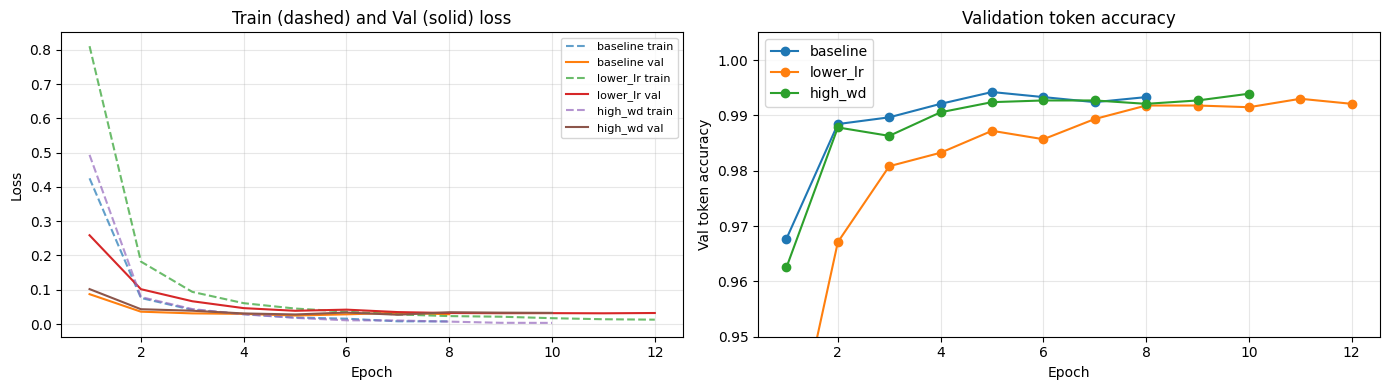

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, r in results.items():
    epochs = range(1, len(r['val_losses']) + 1)
    axes[0].plot(epochs, r['train_losses'], '--', label=f'{name} train', alpha=0.7)
    axes[0].plot(epochs, r['val_losses'],   '-',  label=f'{name} val')
    axes[1].plot(epochs, r['val_accs'], '-', marker='o', label=name)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Train (dashed) and Val (solid) loss')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val token accuracy')
axes[1].set_title('Validation token accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3); axes[1].set_ylim(0.95, 1.005)

plt.tight_layout()
plt.show()

Step 9: Full per-class breakdown for the winning config

In [ ]:
# Pick the experiment with lowest best_val_loss and print its full per-class table.

best_name = min(results.keys(), key=lambda n: results[n]['best_val_loss'])
best_run  = results[best_name]
best_per_class = best_run['val_per_class'][best_run['best_epoch'] - 1]

print(f"Winning config: {best_name}")
print(f"  best epoch    : {best_run['best_epoch']}")
print(f"  best val_loss : {best_run['best_val_loss']:.4f}")
print(f"\nPer-class accuracy at best epoch:\n")
print(f"  {'label':<14}  {'accuracy':>9}")
print('-' * 30)
for label in LABELS:
    acc = best_per_class.get(label)
    print(f"  {label:<14}  {acc:>9.4f}" if acc is not None
          else f"  {label:<14}  {'—':>9}")

Winning config: baseline
  best epoch    : 5
  best val_loss : 0.0248

Per-class accuracy at best epoch:

  label            accuracy
------------------------------
  O                  0.9976
  B-COMPANY          0.9216
  I-COMPANY          0.8000
  B-DATE             0.9600
  I-DATE                  —
  B-ADDRESS          0.9833
  I-ADDRESS          0.9907
  B-TOTAL            0.9344
  I-TOTAL                 —


Step 10: Diagnostic: investigate I-COMPANY failures

In [ ]:
# Find val examples where the winning model gets I-COMPANY wrong.
# Print the context so we can see *what* it predicted instead.

best_ckpt = os.path.join(results[best_name]['config']['save_dir'], 'best')
best_model = LayoutLMv3ForTokenClassification.from_pretrained(best_ckpt).to(DEVICE)
best_model.eval()

I_COMPANY_ID = LABEL2ID['I-COMPANY']
failure_examples = []

for idx in range(len(val_ds)):
    example = val_ds[idx]
    example_b = {k: v.unsqueeze(0).to(DEVICE) for k, v in example.items()}

    with torch.no_grad():
        out = best_model(**example_b)
        preds = out.logits.argmax(dim=-1)[0].cpu()

    labels = example['labels']
    # Positions where gold is I-COMPANY and pred is something else
    failure_mask = (labels == I_COMPANY_ID) & (preds != labels)
    if failure_mask.any():
        positions = failure_mask.nonzero(as_tuple=True)[0].tolist()
        for pos in positions:
            failure_examples.append({
                'val_idx': idx,
                'file_id': val_records[idx]['file_id'],
                'position': pos,
                'gold': ID2LABEL[labels[pos].item()],
                'pred': ID2LABEL[preds[pos].item()],
                'token': processor.tokenizer.convert_ids_to_tokens([example['input_ids'][pos].item()])[0],
            })

print(f"Found {len(failure_examples)} I-COMPANY failure positions across {len({f['val_idx'] for f in failure_examples})} val receipts.\n")

# Tally what the model predicted instead
from collections import Counter
predicted_instead = Counter(f['pred'] for f in failure_examples)
print("When the gold is I-COMPANY, the model predicted:")
total = sum(predicted_instead.values())
for label, count in predicted_instead.most_common():
    pct = 100.0 * count / total
    print(f"  {label:<14}  {count:>4}  ({pct:>5.1f}%)")

print("\nFirst 10 failure cases:")
for f in failure_examples[:10]:
    print(f"  {f['file_id']}  pos {f['position']:>3}  token={f['token']!r:<20}  "
          f"gold={f['gold']}  →  pred={f['pred']}")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Found 1 I-COMPANY failure positions across 1 val receipts.

When the gold is I-COMPANY, the model predicted:
  B-COMPANY          1  (100.0%)

First 10 failure cases:
  X51006466065  pos   8  token='ĠG'                  gold=I-COMPANY  →  pred=B-COMPANY


Step 11: Save the winning config for Day 12

In [ ]:
# Persist the winning experiment's identity so Day 12's final training run
# uses the same config.

winning_config_path = os.path.join(HP_SEARCH_DIR, 'winning_config.json')
with open(winning_config_path, 'w') as f:
    json.dump({
        'name':          best_name,
        'config':        results[best_name]['config'],
        'best_epoch':    results[best_name]['best_epoch'],
        'best_val_loss': results[best_name]['best_val_loss'],
        'best_ckpt_path': os.path.join(results[best_name]['config']['save_dir'], 'best'),
    }, f, indent=2)

print(f"Winning config saved: {winning_config_path}")
print(f"Use this config on Day 12 for the final training run.")

Winning config saved: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day10_hp_search/winning_config.json
Use this config on Day 12 for the final training run.


**START OF DAY 11**

Step 0: Reconnect the colab notebook

In [ ]:
import torch, os, json
import numpy as np

assert torch.cuda.is_available(), "GPU required — switch to T4 GPU runtime."
DEVICE = torch.device('cuda')
print(f"CUDA: {torch.cuda.get_device_name(0)}")

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR     = '/content/drive/MyDrive/doc-understanding'
TRAIN_LBL_DIR   = f'{PROJECT_DIR}/outputs/labels/train'
TEST_LBL_DIR    = f'{PROJECT_DIR}/outputs/labels/test'
SPLITS_PATH     = f'{PROJECT_DIR}/outputs/splits.json'

# Day 10's winning checkpoint
HP_SEARCH_DIR   = f'{PROJECT_DIR}/models/layoutlmv3_day10_hp_search'
WINNING_CONFIG_PATH = f'{HP_SEARCH_DIR}/winning_config.json'

# New for today: error analysis outputs
ERROR_ANALYSIS_DIR = f'{PROJECT_DIR}/outputs/error_analysis'
os.makedirs(ERROR_ANALYSIS_DIR, exist_ok=True)

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
print("Paths configured.")

CUDA: Tesla T4
Mounted at /content/drive
Paths configured.


Step 1: Install packages

In [ ]:
!pip install -q "transformers>=4.40" "torch" "scikit-learn" "seqeval"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Step 2: Replay the full data pipeline

In [ ]:
# Same self-contained replay as Day 10.

from transformers import LayoutLMv3Processor
from torch.utils.data import Dataset
from PIL import Image

LABELS = [
    'O',
    'B-COMPANY', 'I-COMPANY',
    'B-DATE',    'I-DATE',
    'B-ADDRESS', 'I-ADDRESS',
    'B-TOTAL',   'I-TOTAL',
]
NUM_LABELS = len(LABELS)
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for i, label in enumerate(LABELS)}

MODEL_NAME = "microsoft/layoutlmv3-base"
MAX_LENGTH = 512


def load_records(label_dir):
    records = []
    for fn in sorted(os.listdir(label_dir)):
        if fn.endswith('.json'):
            with open(os.path.join(label_dir, fn), 'r', encoding='utf-8') as f:
                records.append(json.load(f))
    return records


def normalize_box(polygon, W, H):
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / W))),
        max(0, min(1000, int(1000 * y0 / H))),
        max(0, min(1000, int(1000 * x1 / W))),
        max(0, min(1000, int(1000 * y1 / H))),
    ]


def encode_record(record, processor, max_length=MAX_LENGTH):
    img = Image.open(record['image_path']).convert('RGB')
    W, H = img.size
    boxes = [normalize_box(p, W, H) for p in record['boxes_pixel']]
    return processor(
        img, record['words'], boxes=boxes,
        word_labels=record['label_ids'],
        return_tensors='pt',
        truncation=True, padding='max_length', max_length=max_length,
    )


class SROIEDataset(Dataset):
    def __init__(self, records, processor, max_length=MAX_LENGTH):
        self.records, self.processor, self.max_length = records, processor, max_length
    def __len__(self): return len(self.records)
    def __getitem__(self, idx):
        encoded = encode_record(self.records[idx], self.processor, self.max_length)
        return {k: v.squeeze(0) for k, v in encoded.items()}


processor = LayoutLMv3Processor.from_pretrained(MODEL_NAME, apply_ocr=False)
all_train = load_records(TRAIN_LBL_DIR)
test_records = load_records(TEST_LBL_DIR)
with open(SPLITS_PATH) as f:
    splits = json.load(f)

fid_to_record = {r['file_id']: r for r in all_train}
train_records = [fid_to_record[fid] for fid in splits['train']]
val_records   = [fid_to_record[fid] for fid in splits['val']]

val_ds = SROIEDataset(val_records, processor)
print(f"Val records: {len(val_records)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Val records: 63


Step 3: Load the winning model from Day 10

In [ ]:
from transformers import LayoutLMv3ForTokenClassification

with open(WINNING_CONFIG_PATH, 'r') as f:
    winning = json.load(f)

WINNING_CKPT = winning['best_ckpt_path']
print(f"Loading: {WINNING_CKPT}")
print(f"  config: {winning['name']}")
print(f"  best epoch: {winning['best_epoch']}")
print(f"  val_loss: {winning['best_val_loss']:.4f}")

model = LayoutLMv3ForTokenClassification.from_pretrained(WINNING_CKPT).to(DEVICE)
model.eval()
print("Model loaded.")

Loading: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_day10_hp_search/baseline/best
  config: baseline
  best epoch: 5
  val_loss: 0.0248


Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Model loaded.


Step 4: Run inference on every val example and compute per-receipt accuracy

In [ ]:
# For every val receipt: run inference, compare to gold labels, store
# per-receipt accuracy and the full prediction tensor for later inspection.

receipt_results = []

for idx in range(len(val_ds)):
    example = val_ds[idx]
    example_b = {k: v.unsqueeze(0).to(DEVICE) for k, v in example.items()}

    with torch.no_grad():
        out = model(**example_b)
        preds = out.logits.argmax(dim=-1)[0].cpu()

    labels = example['labels']
    mask = (labels != -100)

    n_total   = mask.sum().item()
    n_correct = ((preds == labels) & mask).sum().item()
    acc       = n_correct / n_total if n_total > 0 else 0.0

    receipt_results.append({
        'val_idx':   idx,
        'file_id':   val_records[idx]['file_id'],
        'n_total':   n_total,
        'n_correct': n_correct,
        'accuracy':  acc,
        'preds':     preds.tolist(),
        'labels':    labels.tolist(),
        'words':     val_records[idx]['words'],
    })

# Sort ascending: worst-performing first
receipt_results.sort(key=lambda r: r['accuracy'])

print(f"Inference complete on {len(receipt_results)} val receipts.\n")
print(f"Accuracy distribution:")
accs = [r['accuracy'] for r in receipt_results]
print(f"  min   {min(accs):.4f}")
print(f"  p25   {sorted(accs)[int(len(accs)*0.25)]:.4f}")
print(f"  p50   {sorted(accs)[int(len(accs)*0.50)]:.4f}")
print(f"  p75   {sorted(accs)[int(len(accs)*0.75)]:.4f}")
print(f"  max   {max(accs):.4f}")
print(f"  mean  {sum(accs)/len(accs):.4f}")
print(f"\nReceipts at 100% accuracy: {sum(1 for a in accs if a == 1.0)} / {len(accs)}")

Inference complete on 63 val receipts.

Accuracy distribution:
  min   0.9565
  p25   1.0000
  p50   1.0000
  p75   1.0000
  max   1.0000
  mean  0.9944

Receipts at 100% accuracy: 49 / 63


Step 5: Show the bottom 5 worst-performing receipts

In [ ]:
print(f"Bottom 5 worst-performing val receipts:\n")
print(f"  {'rank':>4}  {'file_id':<20}  {'acc':>7}  {'wrong':>6}  {'total':>6}")
print('-' * 55)
for rank, r in enumerate(receipt_results[:5], start=1):
    print(f"  {rank:>4}  {r['file_id']:<20}  "
          f"{r['accuracy']:>7.4f}  "
          f"{r['n_total'] - r['n_correct']:>6}  "
          f"{r['n_total']:>6}")

Bottom 5 worst-performing val receipts:

  rank  file_id                   acc   wrong   total
-------------------------------------------------------
     1  X51006466065           0.9565       2      46
     2  X00016469620           0.9583       2      48
     3  X51005441398           0.9630       2      54
     4  X51007103688           0.9677       1      31
     5  X51005806703           0.9697       2      66


Step 6: Detailed look at the worst receipt

In [ ]:
# Pick the single worst receipt and print exactly where it failed.

worst = receipt_results[0]
print(f"=== Worst receipt: {worst['file_id']} ===")
print(f"  Accuracy: {worst['accuracy']:.4f}  ({worst['n_correct']}/{worst['n_total']} correct)\n")

# Find positions where prediction was wrong
input_ids = val_ds[worst['val_idx']]['input_ids']
tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)

mismatches = []
for i, (p, l) in enumerate(zip(worst['preds'], worst['labels'])):
    if l != -100 and p != l:
        mismatches.append((i, tokens[i], ID2LABEL[l], ID2LABEL[p]))

print(f"Found {len(mismatches)} mismatched tokens:\n")
print(f"  {'pos':>4}  {'token':<20}  {'gold':<14}  →  {'pred':<14}")
print('-' * 70)
for pos, tok, gold, pred in mismatches:
    print(f"  {pos:>4}  {tok!r:<20}  {gold:<14}  →  {pred:<14}")

=== Worst receipt: X51006466065 ===
  Accuracy: 0.9565  (44/46 correct)

Found 2 mismatched tokens:

   pos  token                 gold            →  pred          
----------------------------------------------------------------------
     4  'ĠGH'                 B-COMPANY       →  O             
     8  'ĠG'                  I-COMPANY       →  B-COMPANY     


Step 7: Categorize errors across all val receipts

In [ ]:
# Collect every prediction error across all val receipts and bucket them
# into the four standard error types.

from collections import Counter

error_categories = Counter()
field_errors = Counter()  # which field is affected
error_details = []

for r in receipt_results:
    for pos, (p, l) in enumerate(zip(r['preds'], r['labels'])):
        if l == -100 or p == l:
            continue

        gold_label = ID2LABEL[l]
        pred_label = ID2LABEL[p]

        # Categorize
        if gold_label == 'O' and pred_label != 'O':
            cat = 'false_positive (hallucinated entity)'
        elif gold_label != 'O' and pred_label == 'O':
            cat = 'false_negative (missed entity)'
        elif gold_label.split('-')[-1] == pred_label.split('-')[-1]:
            cat = 'BIO_boundary_confusion (same field, wrong B/I)'
        else:
            cat = 'cross_field_confusion (wrong field entirely)'

        error_categories[cat] += 1

        # Track which field is affected
        field = gold_label.replace('B-', '').replace('I-', '') if gold_label != 'O' else 'O'
        field_errors[field] += 1

        error_details.append({
            'file_id':    r['file_id'],
            'position':   pos,
            'gold':       gold_label,
            'pred':       pred_label,
            'category':   cat,
        })

print(f"Total errors across all val receipts: {sum(error_categories.values())}\n")
print(f"Error category breakdown:")
for cat, count in error_categories.most_common():
    pct = 100.0 * count / sum(error_categories.values())
    print(f"  {count:>4}  ({pct:>5.1f}%)  {cat}")

print(f"\nErrors by affected field:")
for field, count in field_errors.most_common():
    pct = 100.0 * count / sum(field_errors.values())
    print(f"  {count:>4}  ({pct:>5.1f}%)  {field}")

Total errors across all val receipts: 19

Error category breakdown:
     9  ( 47.4%)  false_negative (missed entity)
     7  ( 36.8%)  false_positive (hallucinated entity)
     3  ( 15.8%)  BIO_boundary_confusion (same field, wrong B/I)

Errors by affected field:
     7  ( 36.8%)  O
     5  ( 26.3%)  COMPANY
     4  ( 21.1%)  TOTAL
     2  ( 10.5%)  ADDRESS
     1  (  5.3%)  DATE


Step 8: Visualize a failing receipt with overlaid predictions

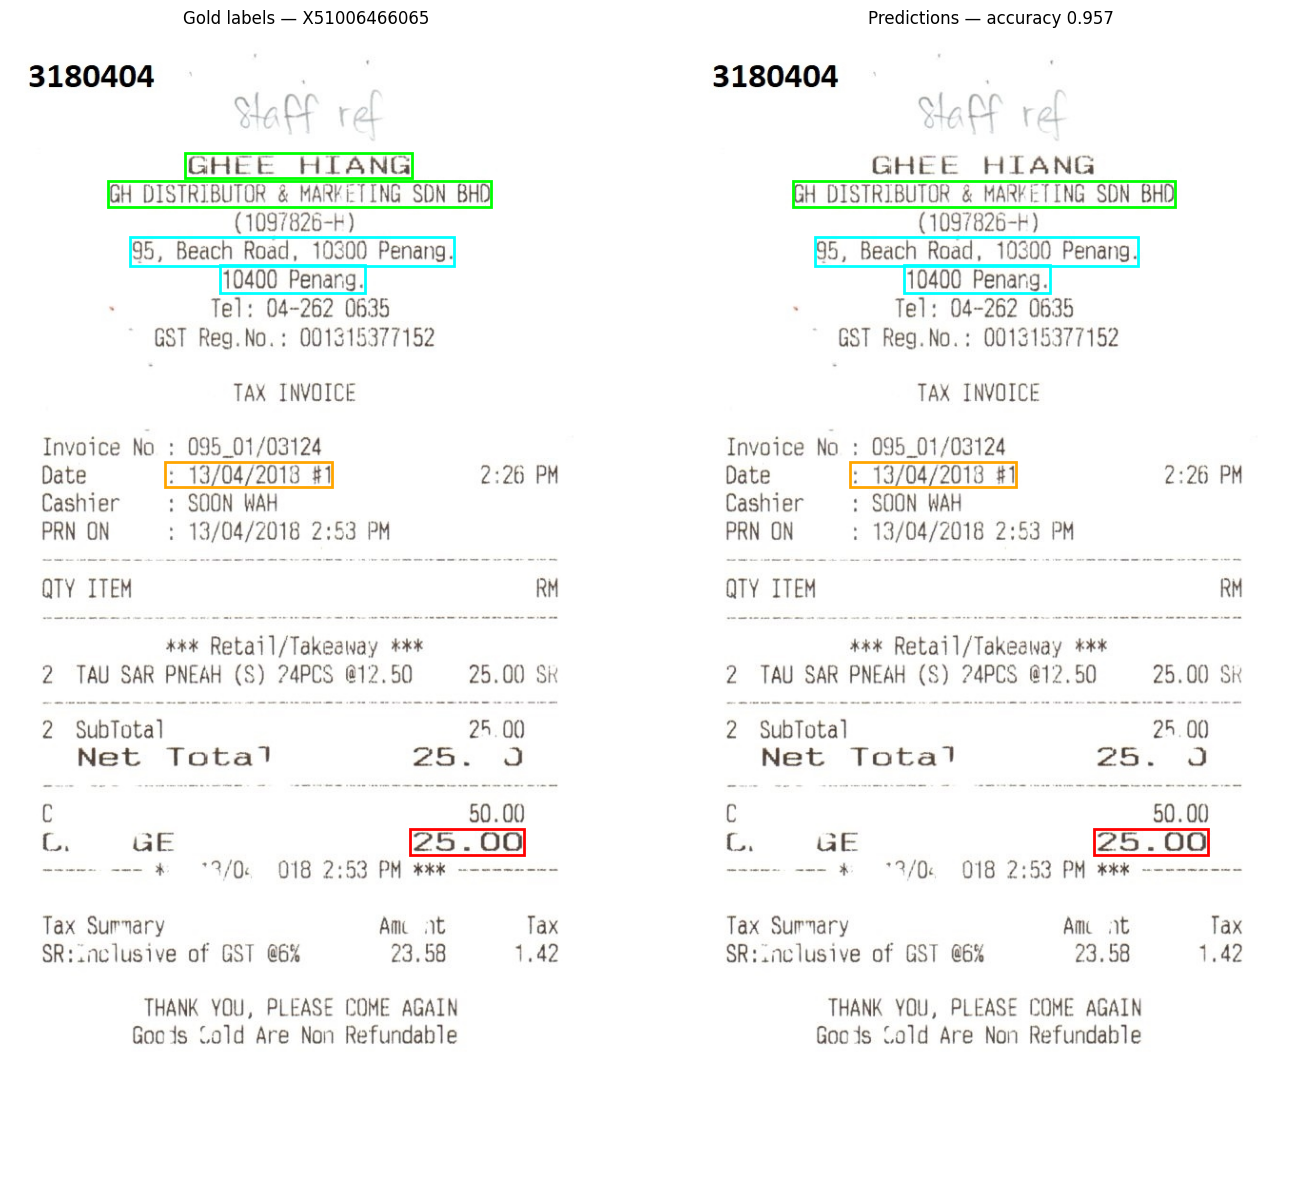

In [ ]:
# Render the worst receipt with bounding boxes colored by prediction.
# Visualizing one failure makes it concrete in a way no table can.

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Use the worst receipt
worst_idx = receipt_results[0]['val_idx']
worst_record = val_records[worst_idx]
img = Image.open(worst_record['image_path']).convert('RGB')
W, H = img.size

# Re-run inference to get per-token predictions linked to original words
# (the receipt_results predictions are at subword level; we want word level)
example = val_ds[worst_idx]
example_b = {k: v.unsqueeze(0).to(DEVICE) for k, v in example.items()}

with torch.no_grad():
    out = model(**example_b)
    preds = out.logits.argmax(dim=-1)[0].cpu()

# Map subword predictions back to word level using word_ids
encoded = processor(
    img, worst_record['words'],
    boxes=[normalize_box(p, W, H) for p in worst_record['boxes_pixel']],
    word_labels=worst_record['label_ids'],
    return_tensors='pt', truncation=True, padding='max_length', max_length=MAX_LENGTH,
)
word_ids = processor.tokenizer(
    worst_record['words'],
    boxes=[normalize_box(p, W, H) for p in worst_record['boxes_pixel']],
    word_labels=worst_record['label_ids'],
    truncation=True, padding='max_length', max_length=MAX_LENGTH,
).word_ids()

# For each original word, pick the first subword's prediction
word_preds = [None] * len(worst_record['words'])
for subword_idx, word_idx in enumerate(word_ids):
    if word_idx is None:
        continue
    if word_preds[word_idx] is None:
        word_preds[word_idx] = preds[subword_idx].item()

# Colors: gold-correct = green, gold-incorrect = red, O = transparent
LABEL_COLORS = {
    'B-COMPANY': 'lime',  'I-COMPANY': 'lime',
    'B-DATE':    'orange','I-DATE':    'orange',
    'B-ADDRESS': 'cyan',  'I-ADDRESS': 'cyan',
    'B-TOTAL':   'red',   'I-TOTAL':   'red',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 12))

# Left: gold labels
axes[0].imshow(img)
axes[0].set_title(f"Gold labels — {worst_record['file_id']}")
for word_idx, (poly, label) in enumerate(zip(worst_record['boxes_pixel'], worst_record['labels'])):
    if label == 'O':
        continue
    xs = [p[0] for p in poly]; ys = [p[1] for p in poly]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    axes[0].add_patch(patches.Rectangle(
        (x0, y0), x1-x0, y1-y0, linewidth=2,
        edgecolor=LABEL_COLORS.get(label, 'gray'), facecolor='none'
    ))
axes[0].axis('off')

# Right: predicted labels
axes[1].imshow(img)
axes[1].set_title(f"Predictions — accuracy {receipt_results[0]['accuracy']:.3f}")
for word_idx, (poly, pred_id) in enumerate(zip(worst_record['boxes_pixel'], word_preds)):
    if pred_id is None or pred_id == LABEL2ID['O']:
        continue
    pred_label = ID2LABEL[pred_id]
    xs = [p[0] for p in poly]; ys = [p[1] for p in poly]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    axes[1].add_patch(patches.Rectangle(
        (x0, y0), x1-x0, y1-y0, linewidth=2,
        edgecolor=LABEL_COLORS.get(pred_label, 'gray'), facecolor='none'
    ))
axes[1].axis('off')

plt.tight_layout()
plt.show()

Step 9: Save analysis

In [ ]:
# Persist the error analysis so we can reference it later.

analysis_output = {
    'model_checkpoint':      WINNING_CKPT,
    'winning_config':        winning,
    'n_val_receipts':        len(receipt_results),
    'receipts_at_100':       sum(1 for r in receipt_results if r['accuracy'] == 1.0),
    'mean_per_receipt_acc':  sum(r['accuracy'] for r in receipt_results) / len(receipt_results),
    'min_per_receipt_acc':   min(r['accuracy'] for r in receipt_results),
    'total_errors':          sum(error_categories.values()),
    'error_categories':      dict(error_categories),
    'errors_by_field':       dict(field_errors),
    'bottom_5_receipts':     [
        {'file_id': r['file_id'], 'accuracy': r['accuracy'],
         'wrong': r['n_total'] - r['n_correct'], 'total': r['n_total']}
        for r in receipt_results[:5]
    ],
    'first_20_error_details': error_details[:20],
}

analysis_path = os.path.join(ERROR_ANALYSIS_DIR, 'val_error_analysis.json')
with open(analysis_path, 'w') as f:
    json.dump(analysis_output, f, indent=2)
print(f"Saved: {analysis_path}")

Saved: /content/drive/MyDrive/doc-understanding/outputs/error_analysis/val_error_analysis.json


Step 10: Decide Day 12's training protocol

In [ ]:
# Based on Day 10 + Day 11 analysis, write out Day 12's training protocol.
# This is the spec for the final training run.

n_train = len(train_records)
n_val = len(val_records)
n_total = n_train + n_val

day12_protocol = {
    'objective': 'Final model for evaluation on the frozen test set (Day 13)',
    'starting_point': 'microsoft/layoutlmv3-base (pretrained, fresh init of classifier head)',
    'hyperparameters': {
        'learning_rate': winning['config']['lr'],
        'weight_decay':  winning['config']['wd'],
        'batch_size':    4,
        'max_epochs':    12,
        'patience':      3,
        'warmup_steps':  100,
        'seed':          42,
    },
    'data': {
        # Decision: train on train_only for direct comparability with Day 10
        # results. Day 12's val_loss can be cross-checked against Day 10's
        # baseline. If we needed even more data, we'd combine train+val, but
        # that sacrifices the ability to do internal validation.
        'training_set':   'train split only (563 receipts)',
        'validation_set': 'val split (63 receipts, same as Day 10)',
        'test_set':       'NEVER touched in Day 12; used only on Day 13',
    },
    'expectations': {
        'expected_best_epoch':     '4-7 (based on Day 10 baseline best=5)',
        'expected_val_loss':       '0.020-0.030',
        'expected_token_accuracy': '>= 0.99',
        'known_weak_class':        'I-COMPANY (BIO boundary confusion on multi-token names)',
    },
    'differences_from_day10_baseline': [
        'None — Day 12 reproduces Day 10 baseline with same seed.',
        'The point is to confirm result stability before final test evaluation.',
    ],
}

protocol_path = os.path.join(ERROR_ANALYSIS_DIR, 'day12_protocol.json')
with open(protocol_path, 'w') as f:
    json.dump(day12_protocol, f, indent=2)

print("=== Day 12 Training Protocol ===\n")
print(json.dumps(day12_protocol, indent=2))
print(f"\nSaved to: {protocol_path}")

=== Day 12 Training Protocol ===

{
  "objective": "Final model for evaluation on the frozen test set (Day 13)",
  "starting_point": "microsoft/layoutlmv3-base (pretrained, fresh init of classifier head)",
  "hyperparameters": {
    "learning_rate": 5e-05,
    "weight_decay": 0.01,
    "batch_size": 4,
    "max_epochs": 12,
    "patience": 3,
    "warmup_steps": 100,
    "seed": 42
  },
  "data": {
    "training_set": "train split only (563 receipts)",
    "validation_set": "val split (63 receipts, same as Day 10)",
    "test_set": "NEVER touched in Day 12; used only on Day 13"
  },
  "expectations": {
    "expected_best_epoch": "4-7 (based on Day 10 baseline best=5)",
    "expected_val_loss": "0.020-0.030",
    "expected_token_accuracy": ">= 0.99",
    "known_weak_class": "I-COMPANY (BIO boundary confusion on multi-token names)"
  },
  "differences_from_day10_baseline": [
    "None \u2014 Day 12 reproduces Day 10 baseline with same seed.",
    "The point is to confirm result stability

**START OF DAY 12**

Step 0: Reconnect the colab notebook

In [ ]:
import torch, os, json
import numpy as np
import random

assert torch.cuda.is_available(), "GPU required — switch to T4 GPU runtime."
DEVICE = torch.device('cuda')
print(f"CUDA: {torch.cuda.get_device_name(0)}")

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR     = '/content/drive/MyDrive/doc-understanding'
TRAIN_LBL_DIR   = f'{PROJECT_DIR}/outputs/labels/train'
TEST_LBL_DIR    = f'{PROJECT_DIR}/outputs/labels/test'
SPLITS_PATH     = f'{PROJECT_DIR}/outputs/splits.json'

# Day 10 + 11 references
HP_SEARCH_DIR   = f'{PROJECT_DIR}/models/layoutlmv3_day10_hp_search'
ERROR_ANALYSIS_DIR = f'{PROJECT_DIR}/outputs/error_analysis'
DAY12_PROTOCOL_PATH = f'{ERROR_ANALYSIS_DIR}/day12_protocol.json'

# Today's output: the final model and inference artifacts
FINAL_MODEL_DIR = f'{PROJECT_DIR}/models/layoutlmv3_FINAL'
os.makedirs(FINAL_MODEL_DIR, exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
print(f"Paths configured. Seed={SEED}")

CUDA: Tesla T4
Mounted at /content/drive
Paths configured. Seed=42


Step 1: Install packages

In [ ]:
!pip install -q "transformers>=4.40" "torch" "scikit-learn" "seqeval"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Step 2: Load the pre-registered Day 12 protocol

In [ ]:
# Read the protocol we committed to yesterday. We follow it exactly.

with open(DAY12_PROTOCOL_PATH, 'r') as f:
    protocol = json.load(f)

print("=== Day 12 Protocol (from Day 11) ===")
print(json.dumps(protocol, indent=2))

=== Day 12 Protocol (from Day 11) ===
{
  "objective": "Final model for evaluation on the frozen test set (Day 13)",
  "starting_point": "microsoft/layoutlmv3-base (pretrained, fresh init of classifier head)",
  "hyperparameters": {
    "learning_rate": 5e-05,
    "weight_decay": 0.01,
    "batch_size": 4,
    "max_epochs": 12,
    "patience": 3,
    "warmup_steps": 100,
    "seed": 42
  },
  "data": {
    "training_set": "train split only (563 receipts)",
    "validation_set": "val split (63 receipts, same as Day 10)",
    "test_set": "NEVER touched in Day 12; used only on Day 13"
  },
  "expectations": {
    "expected_best_epoch": "4-7 (based on Day 10 baseline best=5)",
    "expected_val_loss": "0.020-0.030",
    "expected_token_accuracy": ">= 0.99",
    "known_weak_class": "I-COMPANY (BIO boundary confusion on multi-token names)"
  },
  "differences_from_day10_baseline": [
    "None \u2014 Day 12 reproduces Day 10 baseline with same seed.",
    "The point is to confirm result stabi

Step 3: Replay the data pipeline

In [ ]:
# Same self-contained replay as Day 10/11.

from transformers import LayoutLMv3Processor
from torch.utils.data import Dataset, DataLoader
from PIL import Image

LABELS = [
    'O',
    'B-COMPANY', 'I-COMPANY',
    'B-DATE',    'I-DATE',
    'B-ADDRESS', 'I-ADDRESS',
    'B-TOTAL',   'I-TOTAL',
]
NUM_LABELS = len(LABELS)
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for i, label in enumerate(LABELS)}

MODEL_NAME = "microsoft/layoutlmv3-base"
MAX_LENGTH = 512
BATCH_SIZE = 4


def load_records(label_dir):
    records = []
    for fn in sorted(os.listdir(label_dir)):
        if fn.endswith('.json'):
            with open(os.path.join(label_dir, fn), 'r', encoding='utf-8') as f:
                records.append(json.load(f))
    return records


def normalize_box(polygon, W, H):
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / W))),
        max(0, min(1000, int(1000 * y0 / H))),
        max(0, min(1000, int(1000 * x1 / W))),
        max(0, min(1000, int(1000 * y1 / H))),
    ]


def encode_record(record, processor, max_length=MAX_LENGTH):
    img = Image.open(record['image_path']).convert('RGB')
    W, H = img.size
    boxes = [normalize_box(p, W, H) for p in record['boxes_pixel']]
    return processor(
        img, record['words'], boxes=boxes,
        word_labels=record['label_ids'],
        return_tensors='pt',
        truncation=True, padding='max_length', max_length=max_length,
    )


class SROIEDataset(Dataset):
    def __init__(self, records, processor, max_length=MAX_LENGTH):
        self.records, self.processor, self.max_length = records, processor, max_length
    def __len__(self): return len(self.records)
    def __getitem__(self, idx):
        encoded = encode_record(self.records[idx], self.processor, self.max_length)
        return {k: v.squeeze(0) for k, v in encoded.items()}


def collate_fn(batch):
    return {k: torch.stack([s[k] for s in batch]) for k in batch[0]}


processor = LayoutLMv3Processor.from_pretrained(MODEL_NAME, apply_ocr=False)
all_train = load_records(TRAIN_LBL_DIR)
test_records = load_records(TEST_LBL_DIR)
with open(SPLITS_PATH) as f:
    splits = json.load(f)

fid_to_record = {r['file_id']: r for r in all_train}
train_records = [fid_to_record[fid] for fid in splits['train']]
val_records   = [fid_to_record[fid] for fid in splits['val']]

train_ds = SROIEDataset(train_records, processor)
val_ds   = SROIEDataset(val_records,   processor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_fn, num_workers=0)

print(f"Train: {len(train_records)}, Val: {len(val_records)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

The image processor of type `LayoutLMv3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Train: 563, Val: 63


Step 4: Train the final model (per protocol)

In [ ]:
# Execute the saved Day 12 protocol exactly. Same hyperparameters, same seed,
# same data, same early-stopping rule. Should reproduce Day 10 baseline.

from torch.optim import AdamW
from transformers import LayoutLMv3ForTokenClassification, get_linear_schedule_with_warmup
from tqdm import tqdm


hp = protocol['hyperparameters']
NUM_EPOCHS    = hp['max_epochs']
LEARNING_RATE = hp['learning_rate']
WEIGHT_DECAY  = hp['weight_decay']
WARMUP_STEPS  = hp['warmup_steps']
PATIENCE      = hp['patience']

print(f"Training with: lr={LEARNING_RATE}, wd={WEIGHT_DECAY}, "
      f"max_epochs={NUM_EPOCHS}, patience={PATIENCE}")

model = LayoutLMv3ForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_steps,
)

train_losses, val_losses = [], []
best_val_loss = float('inf')
best_epoch = -1
epochs_without_improvement = 0

# Save best checkpoint directly into the FINAL_MODEL_DIR
BEST_CKPT_DIR = os.path.join(FINAL_MODEL_DIR, 'best')
os.makedirs(BEST_CKPT_DIR, exist_ok=True)

for epoch in range(NUM_EPOCHS):
    # === TRAIN ===
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"ep {epoch+1}/{NUM_EPOCHS} train")
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        out = model(**batch)
        out.loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += out.loss.item()
        pbar.set_postfix({'loss': f'{out.loss.item():.4f}'})
    avg_train = train_loss / len(train_loader)
    train_losses.append(avg_train)

    # === VAL ===
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"ep {epoch+1}/{NUM_EPOCHS} val", leave=False):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            val_loss += model(**batch).loss.item()
    avg_val = val_loss / len(val_loader)
    val_losses.append(avg_val)

    print(f"  Epoch {epoch+1}: train={avg_train:.4f}, val={avg_val:.4f}")

    # === EARLY STOPPING + BEST CHECKPOINT ===
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        best_epoch = epoch + 1
        epochs_without_improvement = 0
        model.save_pretrained(BEST_CKPT_DIR)
        processor.save_pretrained(BEST_CKPT_DIR)
        print(f"    ✓ best so far → saved\n")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"  ⏹ early stop at epoch {epoch+1}\n")
            break

print(f"\n=== Final training complete ===")
print(f"Best val_loss: {best_val_loss:.4f} at epoch {best_epoch}")
print(f"Saved to: {BEST_CKPT_DIR}")

Training with: lr=5e-05, wd=0.01, max_epochs=12, patience=3


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key                                | Status     | 
-----------------------------------+------------+-
layoutlmv3.embeddings.position_ids | UNEXPECTED | 
classifier.bias                    | MISSING    | 
classifier.weight                  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
ep 1/12 train: 100%|██████████| 141/141 [10:50<00:00,  4.62s/it, loss=0.0768]
                                                            

  Epoch 1: train=0.4253, val=0.0871


...

  Epoch 6: train=0.0156, val=0.0283


ep 7/12 train: 100%|██████████| 141/141 [03:20<00:00,  1.42s/it, loss=0.0017]


  Epoch 7: train=0.0079, val=0.0328


ep 8/12 train: 100%|██████████| 141/141 [03:18<00:00,  1.41s/it, loss=0.0006]
                                                            

  Epoch 8: train=0.0077, val=0.0285
  ⏹ early stop at epoch 8


=== Final training complete ===
Best val_loss: 0.0248 at epoch 5
Saved to: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_FINAL/best


Step 5: Reproducibility check vs Day 10 baseline

In [ ]:
# Compare today's best_val_loss against Day 10's baseline. Should be very close.

with open(f'{HP_SEARCH_DIR}/all_results.json', 'r') as f:
    day10_results = json.load(f)

day10_baseline_val = day10_results['baseline']['best_val_loss']
day10_baseline_epoch = day10_results['baseline']['best_epoch']

print("Reproducibility check (Day 10 baseline vs Day 12):\n")
print(f"  {'metric':<14}  {'Day 10':>10}  {'Day 12':>10}  {'delta':>10}")
print('-' * 50)
print(f"  {'best val_loss':<14}  {day10_baseline_val:>10.4f}  {best_val_loss:>10.4f}  "
      f"{best_val_loss - day10_baseline_val:>+10.4f}")
print(f"  {'best epoch':<14}  {day10_baseline_epoch:>10}  {best_epoch:>10}  "
      f"{'(same)' if best_epoch == day10_baseline_epoch else '(DIFFERS)':>10}")

# Acceptance criterion: val_loss within 0.001
if abs(best_val_loss - day10_baseline_val) <= 0.001:
    print("\n✓ Result reproduces Day 10 baseline within tolerance (Δ ≤ 0.001).")
else:
    print("\n⚠ Result deviates from Day 10 baseline by more than 0.001.")
    print("  Possible causes: package version drift, DataLoader nondeterminism, ")
    print("  or non-CUDA-seeded operations. Not necessarily wrong, but flag in README.")

Reproducibility check (Day 10 baseline vs Day 12):

  metric              Day 10      Day 12       delta
--------------------------------------------------
  best val_loss       0.0248      0.0248     +0.0000
  best epoch               5           5      (same)

✓ Result reproduces Day 10 baseline within tolerance (Δ ≤ 0.001).


Step 6: Build the production inference function

In [ ]:
# This is the function every downstream consumer will use.
# Input: image path. Output: dict of extracted entities + raw word-level predictions.

def predict_entities(image_path, model, processor, words=None, bbox_polys=None,
                     ocr_func=None, device='cuda'):
    """
    Run end-to-end entity extraction on a receipt image.

    Args:
        image_path:  path to the receipt image
        model:       LayoutLMv3ForTokenClassification (eval mode)
        processor:   LayoutLMv3Processor (apply_ocr=False)
        words:       list of OCR'd word strings (pre-extracted)
        bbox_polys:  list of pixel-space polygons, one per word
        ocr_func:    if words/bbox_polys not given, call this with image_path
        device:      'cuda' or 'cpu'

    Returns:
        {
          'entities':   {'company': str, 'date': str, 'address': str, 'total': str},
          'words':      list of (word, label) tuples
        }
    """
    img = Image.open(image_path).convert('RGB')
    W, H = img.size

    if words is None or bbox_polys is None:
        if ocr_func is None:
            raise ValueError("Provide either (words, bbox_polys) or ocr_func.")
        words, bbox_polys = ocr_func(image_path)

    boxes = [normalize_box(poly, W, H) for poly in bbox_polys]

    encoded = processor(
        img, words, boxes=boxes,
        return_tensors='pt',
        truncation=True, padding='max_length', max_length=MAX_LENGTH,
    )

    # Need word_ids() to map subword predictions back to original words
    tokenized = processor.tokenizer(
        words, boxes=boxes,
        truncation=True, padding='max_length', max_length=MAX_LENGTH,
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        out = model(**encoded)
        subword_preds = out.logits.argmax(dim=-1)[0].cpu().tolist()

    # Map subword predictions back to word level (first subword wins)
    word_preds = [None] * len(words)
    for sub_idx, word_idx in enumerate(tokenized.word_ids()):
        if word_idx is None:           # special tokens
            continue
        if word_preds[word_idx] is None:
            word_preds[word_idx] = subword_preds[sub_idx]

    # Convert word indices to labels
    word_labels = [
        ID2LABEL[p] if p is not None else 'O'
        for p in word_preds
    ]

    # Extract entities by walking the BIO sequence
    entities = {'company': '', 'date': '', 'address': '', 'total': ''}
    current_field = None
    current_tokens = []

    def flush():
        nonlocal current_field, current_tokens
        if current_field and current_tokens:
            text = ' '.join(current_tokens).strip()
            field_key = current_field.lower()
            if entities[field_key]:
                entities[field_key] += ' ' + text
            else:
                entities[field_key] = text
        current_field = None
        current_tokens = []

    for word, label in zip(words, word_labels):
        if label == 'O':
            flush()
        elif label.startswith('B-'):
            flush()
            current_field = label[2:]
            current_tokens = [word]
        elif label.startswith('I-'):
            if current_field == label[2:]:
                current_tokens.append(word)
            else:
                # I-X without preceding B-X — treat as B-X (defensive)
                flush()
                current_field = label[2:]
                current_tokens = [word]
    flush()

    return {
        'entities': entities,
        'words': list(zip(words, word_labels)),
    }


# Test the function exists and is callable
print(f"predict_entities function defined.")
print(f"Signature: predict_entities(image_path, model, processor, words, bbox_polys, ocr_func, device)")

predict_entities function defined.
Signature: predict_entities(image_path, model, processor, words, bbox_polys, ocr_func, device)


Step 7: Test inference on 3 val examples

In [ ]:
# Load the final model and run the new inference function on 3 val receipts.

final_model = LayoutLMv3ForTokenClassification.from_pretrained(BEST_CKPT_DIR).to(DEVICE)
final_model.eval()

print(f"Final model loaded from {BEST_CKPT_DIR}\n")

# Test on indices 0, 25, 50
for idx in [0, 25, 50]:
    rec = val_records[idx]
    result = predict_entities(
        image_path=rec['image_path'],
        model=final_model,
        processor=processor,
        words=rec['words'],
        bbox_polys=rec['boxes_pixel'],
        device=DEVICE,
    )

    print(f"--- Val #{idx} ({rec['file_id']}) ---")
    print(f"  Predicted entities:")
    for k, v in result['entities'].items():
        truncated = (v[:60] + '...') if len(v) > 60 else v
        print(f"    {k:>8}: {truncated!r}")
    print()

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Final model loaded from /content/drive/MyDrive/doc-understanding/models/layoutlmv3_FINAL/best

--- Val #0 (X51007103688) ---
  Predicted entities:
     company: 'MR.D.I.Y.(M) SDN BHD'
        date: ''
     address: 'LOT 1851-A& 1851-B,JALAN KPB6, KAWASAN PERINDUSTRIAN BALAKON...'
       total: ''

--- Val #25 (X51005663317) ---
  Predicted entities:
     company: 'LIMSENGTHOHARDWARETRADING'
        date: '29/12/201711:41'
     address: 'No 7.SimpangOff Batu Village. Jalan IpohBatu5.51200KualaLump...'
       total: '6.00'

--- Val #50 (X51008099043) ---
  Predicted entities:
     company: 'RESTORAN WANSHENG'
        date: ''
     address: 'No.2,Jalan Temenggung19/9, Seksyen 9,Bandar Mahkota Cheras, ...'
       total: '4.60'



Step 8: Write the model card metadata

In [ ]:
# Model card = the README for the model itself.
# This is what Hugging Face displays when someone visits your model page.

import datetime

model_card = {
    'model_name':       'layoutlmv3-base-sroie-receipts',
    'base_model':       MODEL_NAME,
    'task':             'token-classification (BIO tagging on receipt OCR text)',
    'num_labels':       NUM_LABELS,
    'labels':           LABELS,
    'training_data': {
        'dataset':       'SROIE 2019 (ICDAR Robust Reading)',
        'source':        'Kaggle: urbikn/sroie-datasetv2',
        'license':       'CC-BY-4.0',
        'train_size':    len(train_records),
        'val_size':      len(val_records),
        'val_split_seed': 42,
    },
    'ocr_pipeline': {
        'engine':                   'PaddleOCR 3.x',
        'paddlepaddle_version':     '3.2.2 (pinned to avoid OneDNN PIR bug in 3.3+)',
        'text_det_limit_side_len':  'first ~280 receipts at default 4000, remaining at 1500',
    },
    'training': {
        'optimizer':       'AdamW',
        'learning_rate':   LEARNING_RATE,
        'weight_decay':    WEIGHT_DECAY,
        'batch_size':      BATCH_SIZE,
        'max_epochs':      NUM_EPOCHS,
        'patience':        PATIENCE,
        'warmup_steps':    WARMUP_STEPS,
        'best_epoch':      best_epoch,
        'best_val_loss':   best_val_loss,
        'seed':            SEED,
        'precision':       'fp32',
        'hardware':        'free Colab T4 (~15 GB VRAM)',
        'training_date':   datetime.datetime.now().strftime('%Y-%m-%d'),
    },
    'validation_results': {
        'best_val_loss':      best_val_loss,
        'token_accuracy':     None,    # filled by Day 13's evaluation
        'per_field_f1':       None,    # filled by Day 13
    },
    'limitations': [
        'Trained on Malaysian receipts (2016-2018) — performance may degrade '
        'on non-Malaysian or recent receipt formats.',
        'Address field (especially I-ADDRESS) shows the highest variance — '
        'multi-line addresses with line breaks in unusual positions are the '
        'primary failure mode.',
        'Truncates receipts longer than 512 subword tokens (~1.1% of train).',
        'OCR errors propagate downstream: if PaddleOCR misreads "9.00" as "9.OO", '
        'the model cannot recover the correct total.',
    ],
}

model_card_path = os.path.join(FINAL_MODEL_DIR, 'model_card.json')
with open(model_card_path, 'w') as f:
    json.dump(model_card, f, indent=2)

print(f"Model card saved to: {model_card_path}\n")
print("Summary:")
print(json.dumps({k: v for k, v in model_card.items() if k != 'limitations'}, indent=2)[:1000])

Model card saved to: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_FINAL/model_card.json

Summary:
{
  "model_name": "layoutlmv3-base-sroie-receipts",
  "base_model": "microsoft/layoutlmv3-base",
  "task": "token-classification (BIO tagging on receipt OCR text)",
  "num_labels": 9,
  "labels": [
    "O",
    "B-COMPANY",
    "I-COMPANY",
    "B-DATE",
    "I-DATE",
    "B-ADDRESS",
    "I-ADDRESS",
    "B-TOTAL",
    "I-TOTAL"
  ],
  "training_data": {
    "dataset": "SROIE 2019 (ICDAR Robust Reading)",
    "source": "Kaggle: urbikn/sroie-datasetv2",
    "license": "CC-BY-4.0",
    "train_size": 563,
    "val_size": 63,
    "val_split_seed": 42
  },
  "ocr_pipeline": {
    "engine": "PaddleOCR 3.x",
    "paddlepaddle_version": "3.2.2 (pinned to avoid OneDNN PIR bug in 3.3+)",
    "text_det_limit_side_len": "first ~280 receipts at default 4000, remaining at 1500"
  },
  "training": {
    "optimizer": "AdamW",
    "learning_rate": 5e-05,
    "weight_decay": 0.01,
    "batch_

Step 9: Save a "load_final_model" convenience function

In [ ]:
# Tiny helper script for loading the final model in any future notebook.

helper_code = '''"""
Convenience function for loading the final SROIE LayoutLMv3 model.
Generated on Day 12 to be imported by Days 13-22 notebooks.
"""

import torch
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification


FINAL_MODEL_DIR = "''' + BEST_CKPT_DIR + '''"


def load_final_model(device=None):
    """Load the final fine-tuned model and processor."""
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = LayoutLMv3ForTokenClassification.from_pretrained(FINAL_MODEL_DIR)
    model = model.to(device)
    model.eval()

    processor = LayoutLMv3Processor.from_pretrained(FINAL_MODEL_DIR, apply_ocr=False)

    return model, processor, device
'''

helper_path = os.path.join(FINAL_MODEL_DIR, 'load_final_model.py')
with open(helper_path, 'w') as f:
    f.write(helper_code)

print(f"Helper script saved: {helper_path}")
print(f"\nUsage in future notebooks:")
print(f"  import sys")
print(f"  sys.path.insert(0, '{FINAL_MODEL_DIR}')")
print(f"  from load_final_model import load_final_model")
print(f"  model, processor, device = load_final_model()")

Helper script saved: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_FINAL/load_final_model.py

Usage in future notebooks:
  import sys
  sys.path.insert(0, '/content/drive/MyDrive/doc-understanding/models/layoutlmv3_FINAL')
  from load_final_model import load_final_model
  model, processor, device = load_final_model()


Step 10: Final inventory check

In [ ]:
# What's in FINAL_MODEL_DIR? Should have: best/ checkpoint, model_card.json,
# load_final_model.py.

print(f"Contents of {FINAL_MODEL_DIR}:\n")
for root, dirs, files in os.walk(FINAL_MODEL_DIR):
    level = root.replace(FINAL_MODEL_DIR, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    sub_indent = '  ' * (level + 1)
    for fn in files:
        size_mb = os.path.getsize(os.path.join(root, fn)) / 1e6
        print(f"{sub_indent}{fn}  ({size_mb:.2f} MB)")

Contents of /content/drive/MyDrive/doc-understanding/models/layoutlmv3_FINAL:

layoutlmv3_FINAL/
  model_card.json  (0.00 MB)
  load_final_model.py  (0.00 MB)
  best/
    config.json  (0.00 MB)
    model.safetensors  (501.36 MB)
    tokenizer_config.json  (0.00 MB)
    tokenizer.json  (3.56 MB)
    processor_config.json  (0.00 MB)


**START OF DAY 13**

Step 0: Reconnect the colab notebook

In [ ]:
import torch, os, json
import numpy as np

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR        = '/content/drive/MyDrive/doc-understanding'
TEST_LBL_DIR       = f'{PROJECT_DIR}/outputs/labels/test'
TEST_ENT_DIR       = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/entities'
SPLITS_PATH        = f'{PROJECT_DIR}/outputs/splits.json'

FINAL_MODEL_DIR    = f'{PROJECT_DIR}/models/layoutlmv3_FINAL'
BEST_CKPT_DIR      = f'{FINAL_MODEL_DIR}/best'

EVAL_OUT_DIR       = f'{PROJECT_DIR}/outputs/test_evaluation'
os.makedirs(EVAL_OUT_DIR, exist_ok=True)

print(f"Final model: {BEST_CKPT_DIR}")
print(f"Test labels: {TEST_LBL_DIR}")

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Final model: /content/drive/MyDrive/doc-understanding/models/layoutlmv3_FINAL/best
Test labels: /content/drive/MyDrive/doc-understanding/outputs/labels/test


Step 1: Install packages

In [ ]:
!pip install -q "transformers>=4.40" rapidfuzz seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.1 MB/s eta 0:00:00


Step 2: Replay data pipeline

In [ ]:
# Self-contained replay of the data pipeline + entity scheme.

from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification
from PIL import Image

LABELS = [
    'O',
    'B-COMPANY', 'I-COMPANY',
    'B-DATE',    'I-DATE',
    'B-ADDRESS', 'I-ADDRESS',
    'B-TOTAL',   'I-TOTAL',
]
NUM_LABELS = len(LABELS)
LABEL2ID = {label: i for i, label in enumerate(LABELS)}
ID2LABEL = {i: label for i, label in enumerate(LABELS)}
ENTITY_FIELDS = ['company', 'date', 'address', 'total']

MAX_LENGTH = 512


def normalize_box(polygon, W, H):
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / W))),
        max(0, min(1000, int(1000 * y0 / H))),
        max(0, min(1000, int(1000 * x1 / W))),
        max(0, min(1000, int(1000 * y1 / H))),
    ]


def load_records(label_dir):
    records = []
    for fn in sorted(os.listdir(label_dir)):
        if fn.endswith('.json'):
            with open(os.path.join(label_dir, fn), 'r', encoding='utf-8') as f:
                records.append(json.load(f))
    return records


test_records = load_records(TEST_LBL_DIR)
print(f"Loaded {len(test_records)} test records.")

Loaded 347 test records.


Step 3: Load the final model

In [ ]:
# Use the loader helper Day 12 saved into the FINAL_MODEL_DIR.

processor = LayoutLMv3Processor.from_pretrained(BEST_CKPT_DIR, apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained(BEST_CKPT_DIR).to(DEVICE)
model.eval()

print(f"Model on: {next(model.parameters()).device}")
print(f"Params  : {sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Model on: cuda:0
Params  : 125,333,897


Step 4 — The production prediction function

In [ ]:
# Slightly improved version of Day 12's predict_entities.
# Handles edge cases more cleanly and returns both entity strings and
# raw word-level predictions for downstream analysis.

def predict_entities_v2(image_path, words, bbox_polys, model, processor, device='cuda'):
    """
    Returns:
        {
          'entities':    {field: predicted_string},
          'word_labels': list of (word, label) tuples,
        }
    """
    img = Image.open(image_path).convert('RGB')
    W, H = img.size
    boxes = [normalize_box(poly, W, H) for poly in bbox_polys]

    encoded = processor(
        img, words, boxes=boxes,
        return_tensors='pt',
        truncation=True, padding='max_length', max_length=MAX_LENGTH,
    )

    tokenized = processor.tokenizer(
        words, boxes=boxes,
        truncation=True, padding='max_length', max_length=MAX_LENGTH,
    )

    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        subword_preds = model(**encoded).logits.argmax(dim=-1)[0].cpu().tolist()

    # Map subword → word (first-subword convention)
    word_preds = [None] * len(words)
    for sub_idx, word_idx in enumerate(tokenized.word_ids()):
        if word_idx is None or word_idx >= len(words):
            continue
        if word_preds[word_idx] is None:
            word_preds[word_idx] = subword_preds[sub_idx]

    word_labels = [ID2LABEL[p] if p is not None else 'O' for p in word_preds]

    # Extract entities by walking the BIO sequence
    entities = {f: '' for f in ENTITY_FIELDS}
    current_field = None
    current_tokens = []

    def flush():
        nonlocal current_field, current_tokens
        if current_field and current_tokens:
            text = ' '.join(current_tokens).strip()
            key = current_field.lower()
            if entities[key]:
                entities[key] += ' ' + text
            else:
                entities[key] = text
        current_field, current_tokens = None, []

    for word, label in zip(words, word_labels):
        if label == 'O':
            flush()
        elif label.startswith('B-'):
            flush()
            current_field = label[2:]
            current_tokens = [word]
        elif label.startswith('I-'):
            field = label[2:]
            if current_field == field:
                current_tokens.append(word)
            else:
                flush()
                current_field, current_tokens = field, [word]
    flush()

    return {'entities': entities, 'word_labels': list(zip(words, word_labels))}


print("predict_entities_v2 defined.")

predict_entities_v2 defined.


Step 5: Run inference on the entire test set

In [ ]:
from tqdm import tqdm

predictions = []   # list of dicts: {file_id, entities_pred, entities_gold}

print(f"Running inference on {len(test_records)} test receipts...")
for record in tqdm(test_records, desc="Test inference"):
    file_id = record['file_id']

    result = predict_entities_v2(
        image_path=record['image_path'],
        words=record['words'],
        bbox_polys=record['boxes_pixel'],
        model=model,
        processor=processor,
        device=DEVICE,
    )

    # Load gold-standard entities from the original SROIE annotation
    ent_path = os.path.join(TEST_ENT_DIR, f'{file_id}.txt')
    with open(ent_path, 'r', encoding='utf-8') as f:
        gold_entities = json.load(f)

    predictions.append({
        'file_id':       file_id,
        'entities_pred': result['entities'],
        'entities_gold': {k: (gold_entities.get(k) or '') for k in ENTITY_FIELDS},
    })

print(f"\nInference complete: {len(predictions)} predictions.")

Running inference on 347 test receipts...


Test inference: 100%|██████████| 347/347 [05:25<00:00,  1.06it/s]


Inference complete: 347 predictions.


Step 6: Define the matching predicates

In [ ]:
# Two ways to count something as a "match" — strict and fuzzy.

from rapidfuzz import fuzz

def normalize_for_match(s):
    """Lowercase + collapse whitespace + strip leading/trailing spaces."""
    if not s:
        return ''
    return ' '.join(s.lower().split())


def exact_match(pred, gold):
    """Strict normalized exact match."""
    return normalize_for_match(pred) == normalize_for_match(gold)


def fuzzy_match(pred, gold, threshold=80):
    """Match if fuzz.ratio >= threshold."""
    p = normalize_for_match(pred)
    g = normalize_for_match(gold)
    if not p and not g:
        return True   # both empty → trivial match (we'll exclude these from F1 anyway)
    if not p or not g:
        return False
    return fuzz.ratio(p, g) >= threshold


# Quick test on a known example
print("Exact match tests:")
print(f"  '9.00' vs '9.00':  {exact_match('9.00', '9.00')}")
print(f"  '9.00' vs '9.0O':  {exact_match('9.00', '9.0O')}")
print(f"  ''     vs '9.00':  {exact_match('', '9.00')}")
print(f"\nFuzzy match tests (threshold=80):")
print(f"  '9.00' vs '9.0O':  {fuzzy_match('9.00', '9.0O')}")
print(f"  'STARBUCKS' vs 'STARBUKS': {fuzzy_match('STARBUCKS', 'STARBUKS')}")
print(f"  'STARBUCKS' vs 'MCDONALDS': {fuzzy_match('STARBUCKS', 'MCDONALDS')}")

Exact match tests:
  '9.00' vs '9.00':  True
  '9.00' vs '9.0O':  False
  ''     vs '9.00':  False

Fuzzy match tests (threshold=80):
  '9.00' vs '9.0O':  False
  'STARBUCKS' vs 'STARBUKS': True
  'STARBUCKS' vs 'MCDONALDS': False


Step 7: Compute per-field precision, recall, F1

In [ ]:
# For each field, count TP/FP/FN under both matching criteria.

def compute_field_metrics(predictions, field, match_fn):
    """
    Returns dict with TP, FP, FN, precision, recall, F1 for one field
    using the given match function.

    Rules:
        gold non-empty AND pred non-empty AND match  → TP
        gold non-empty AND pred non-empty AND !match → FP (counted; also FN)
        gold non-empty AND pred empty                → FN
        gold empty     AND pred non-empty            → FP
        gold empty     AND pred empty                → ignored (TN)
    """
    tp, fp, fn = 0, 0, 0

    for p in predictions:
        gold = p['entities_gold'][field]
        pred = p['entities_pred'][field]
        gold_present = bool(normalize_for_match(gold))
        pred_present = bool(normalize_for_match(pred))

        if gold_present and pred_present:
            if match_fn(pred, gold):
                tp += 1
            else:
                fp += 1
                fn += 1
        elif gold_present and not pred_present:
            fn += 1
        elif not gold_present and pred_present:
            fp += 1
        # both empty → ignored

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'tp': tp, 'fp': fp, 'fn': fn,
        'precision': precision, 'recall': recall, 'f1': f1,
    }


# Compute for all fields under exact match
exact_metrics = {field: compute_field_metrics(predictions, field, exact_match)
                 for field in ENTITY_FIELDS}

fuzzy_metrics = {field: compute_field_metrics(predictions, field, fuzzy_match)
                 for field in ENTITY_FIELDS}

print(f"=== EXACT MATCH (case-insensitive, whitespace-normalized) ===\n")
print(f"  {'field':>8}  {'P':>6}  {'R':>6}  {'F1':>6}  {'TP':>4}  {'FP':>4}  {'FN':>4}")
print('-' * 50)
for field in ENTITY_FIELDS:
    m = exact_metrics[field]
    print(f"  {field:>8}  {m['precision']:>6.3f}  {m['recall']:>6.3f}  {m['f1']:>6.3f}  "
          f"{m['tp']:>4}  {m['fp']:>4}  {m['fn']:>4}")

print(f"\n=== FUZZY MATCH (fuzz.ratio >= 80) ===\n")
print(f"  {'field':>8}  {'P':>6}  {'R':>6}  {'F1':>6}  {'TP':>4}  {'FP':>4}  {'FN':>4}")
print('-' * 50)
for field in ENTITY_FIELDS:
    m = fuzzy_metrics[field]
    print(f"  {field:>8}  {m['precision']:>6.3f}  {m['recall']:>6.3f}  {m['f1']:>6.3f}  "
          f"{m['tp']:>4}  {m['fp']:>4}  {m['fn']:>4}")

=== EXACT MATCH (case-insensitive, whitespace-normalized) ===

     field       P       R      F1    TP    FP    FN
--------------------------------------------------
   company   0.199   0.150   0.171    52   209   295
      date   0.401   0.164   0.233    57    85   290
   address   0.069   0.063   0.066    22   297   325
     total   0.861   0.784   0.821   272    44    75

=== FUZZY MATCH (fuzz.ratio >= 80) ===

     field       P       R      F1    TP    FP    FN
--------------------------------------------------
   company   0.908   0.683   0.780   237    24   110
      date   0.965   0.395   0.560   137     5   210
   address   0.947   0.870   0.907   302    17    45
     total   0.908   0.827   0.866   287    29    60


Step 8: Compute macro and micro averages

In [ ]:
def compute_aggregates(metrics_by_field):
    """Macro = mean of per-field F1s. Micro = pooled TPs/FPs/FNs into one F1."""
    field_f1s = [m['f1'] for m in metrics_by_field.values()]
    macro_f1 = sum(field_f1s) / len(field_f1s)

    total_tp = sum(m['tp'] for m in metrics_by_field.values())
    total_fp = sum(m['fp'] for m in metrics_by_field.values())
    total_fn = sum(m['fn'] for m in metrics_by_field.values())

    micro_p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    micro_r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    micro_f1 = 2 * micro_p * micro_r / (micro_p + micro_r) if (micro_p + micro_r) > 0 else 0.0

    return {'macro_f1': macro_f1, 'micro_p': micro_p, 'micro_r': micro_r, 'micro_f1': micro_f1}


exact_agg = compute_aggregates(exact_metrics)
fuzzy_agg = compute_aggregates(fuzzy_metrics)

print(f"\n=== AGGREGATE METRICS ===\n")
print(f"  {'metric':<14}  {'exact':>8}  {'fuzzy':>8}")
print('-' * 35)
print(f"  {'macro F1':<14}  {exact_agg['macro_f1']:>8.4f}  {fuzzy_agg['macro_f1']:>8.4f}")
print(f"  {'micro F1':<14}  {exact_agg['micro_f1']:>8.4f}  {fuzzy_agg['micro_f1']:>8.4f}")
print(f"  {'micro P':<14}  {exact_agg['micro_p']:>8.4f}  {fuzzy_agg['micro_p']:>8.4f}")
print(f"  {'micro R':<14}  {exact_agg['micro_r']:>8.4f}  {fuzzy_agg['micro_r']:>8.4f}")


=== AGGREGATE METRICS ===

  metric             exact     fuzzy
-----------------------------------
  macro F1          0.3227    0.7782
  micro F1          0.3322    0.7939
  micro P           0.3882    0.9277
  micro R           0.2903    0.6938


Step 9: Find the worst predictions per field

In [ ]:
# For each field, find 5 receipts where the prediction differed most from gold.
# This is the "what does the model still get wrong" qualitative analysis.

print("=== Worst predictions per field (exact match failures with high fuzzy distance) ===\n")

for field in ENTITY_FIELDS:
    failures = []
    for p in predictions:
        gold = normalize_for_match(p['entities_gold'][field])
        pred = normalize_for_match(p['entities_pred'][field])
        if not gold:
            continue
        if exact_match(pred, gold):
            continue
        score = fuzz.ratio(pred, gold) if (pred or gold) else 0
        failures.append((score, p['file_id'], gold, pred))

    failures.sort(key=lambda x: x[0])  # lowest fuzz score = worst

    print(f"\nWorst {min(5, len(failures))} for field '{field}':")
    for score, fid, gold, pred in failures[:5]:
        gold_short = (gold[:60] + '...') if len(gold) > 60 else gold
        pred_short = (pred[:60] + '...') if len(pred) > 60 else pred
        print(f"  {fid}  fuzz={score:.0f}")
        print(f"    gold: {gold_short!r}")
        print(f"    pred: {pred_short!r}")

=== Worst predictions per field (exact match failures with high fuzzy distance) ===


Worst 5 for field 'company':
  X51005268408  fuzz=0
    gold: '99 speed mart s/b'
    pred: ''
  X51005361923  fuzz=0
    gold: 'swc enterprise sdn bhd'
    pred: ''
  X51005442388  fuzz=0
    gold: 'contento'
    pred: ''
  X51005444044  fuzz=0
    gold: '99 speed mart s/b'
    pred: ''
  X51005444046  fuzz=0
    gold: 'star grocer sdn bhd'
    pred: ''

Worst 5 for field 'date':
  X00016469670  fuzz=0
    gold: '15/01/2019'
    pred: ''
  X00016469671  fuzz=0
    gold: '02/01/2019'
    pred: ''
  X51005230605  fuzz=0
    gold: '01/02/2018'
    pred: ''
  X51005230616  fuzz=0
    gold: '18/01/2018'
    pred: ''
  X51005230648  fuzz=0
    gold: '29/01/2018'
    pred: ''

Worst 5 for field 'address':
  X51005337867  fuzz=0
    gold: 'sri rampai'
    pred: ''
  X51005724623  fuzz=0
    gold: 'lot 276 jalan banting 800 den selangor.'
    pred: ''
  X51006008083  fuzz=0
    gold: 'no 18, 20, 22, jalan bun

Step 10: Save all evaluation outputs

In [ ]:
evaluation_report = {
    'model_checkpoint':    BEST_CKPT_DIR,
    'test_set_size':       len(predictions),
    'metrics': {
        'exact': {
            'per_field':   exact_metrics,
            'aggregate':   exact_agg,
        },
        'fuzzy_80': {
            'per_field':   fuzzy_metrics,
            'aggregate':   fuzzy_agg,
        },
    },
}

report_path = os.path.join(EVAL_OUT_DIR, 'test_evaluation_report.json')
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(evaluation_report, f, indent=2)

predictions_path = os.path.join(EVAL_OUT_DIR, 'test_predictions.json')
with open(predictions_path, 'w', encoding='utf-8') as f:
    json.dump(predictions, f, indent=2, ensure_ascii=False)

print(f"Saved:")
print(f"  {report_path}")
print(f"  {predictions_path}")

Saved:
  /content/drive/MyDrive/doc-understanding/outputs/test_evaluation/test_evaluation_report.json
  /content/drive/MyDrive/doc-understanding/outputs/test_evaluation/test_predictions.json


Step 11: Update the model card with final test results

In [ ]:
# Refresh the model card from Day 12 with actual test-set numbers.

model_card_path = os.path.join(FINAL_MODEL_DIR, 'model_card.json')
with open(model_card_path, 'r', encoding='utf-8') as f:
    model_card = json.load(f)

model_card['test_set_results'] = {
    'n_receipts':                   len(predictions),
    'exact_match_macro_f1':         exact_agg['macro_f1'],
    'exact_match_micro_f1':         exact_agg['micro_f1'],
    'fuzzy80_match_macro_f1':       fuzzy_agg['macro_f1'],
    'fuzzy80_match_micro_f1':       fuzzy_agg['micro_f1'],
    'per_field_exact_f1': {f: exact_metrics[f]['f1'] for f in ENTITY_FIELDS},
    'per_field_fuzzy_f1': {f: fuzzy_metrics[f]['f1'] for f in ENTITY_FIELDS},
}

with open(model_card_path, 'w', encoding='utf-8') as f:
    json.dump(model_card, f, indent=2)

print(f"Updated model_card.json with test results.")
print(f"\nHeadline numbers:")
print(f"  Exact match  macro F1: {exact_agg['macro_f1']:.4f}")
print(f"  Fuzzy@80     macro F1: {fuzzy_agg['macro_f1']:.4f}")

Updated model_card.json with test results.

Headline numbers:
  Exact match  macro F1: 0.3227
  Fuzzy@80     macro F1: 0.7782


**START OF DAY 14**

Step 0: Reconnect the colab notebook

In [ ]:
import os, json
from collections import Counter
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR     = '/content/drive/MyDrive/doc-understanding'
TEST_LBL_DIR    = f'{PROJECT_DIR}/outputs/labels/test'
TEST_OCR_DIR    = f'{PROJECT_DIR}/outputs/ocr/test'
EVAL_OUT_DIR    = f'{PROJECT_DIR}/outputs/test_evaluation'
DIAG_OUT_DIR    = f'{PROJECT_DIR}/outputs/failure_diagnostics'

os.makedirs(DIAG_OUT_DIR, exist_ok=True)

# Load Day 13's predictions
with open(f'{EVAL_OUT_DIR}/test_predictions.json', 'r', encoding='utf-8') as f:
    predictions = json.load(f)

print(f"Loaded {len(predictions)} test predictions from Day 13.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 347 test predictions from Day 13.


Step 1: Install Packages and helpers

In [ ]:
!pip install -q rapidfuzz

In [ ]:
from rapidfuzz import fuzz

ENTITY_FIELDS = ['company', 'date', 'address', 'total']

def normalize(s):
    if not s:
        return ''
    return ' '.join(s.lower().split())

Step 2: Diagnostic question 1 - are empty predictions concentrated or scattered?

In [ ]:
# For each receipt, count how many of its 4 entity fields have empty predictions
# (given that the gold is non-empty).

empty_pred_counts = []
for p in predictions:
    n_empty = 0
    for field in ENTITY_FIELDS:
        gold = normalize(p['entities_gold'][field])
        pred = normalize(p['entities_pred'][field])
        if gold and not pred:
            n_empty += 1
    empty_pred_counts.append({
        'file_id': p['file_id'],
        'n_empty': n_empty,
    })

# Distribution
distribution = Counter(r['n_empty'] for r in empty_pred_counts)
print(f"{'n empty fields per receipt':<30}  {'n receipts':>10}  {'% of test':>10}")
print('-' * 55)
for n in sorted(distribution.keys()):
    count = distribution[n]
    pct = 100.0 * count / len(predictions)
    print(f"  {n:<28}  {count:>10}  {pct:>9.1f}%")

n empty fields per receipt      n receipts   % of test
-------------------------------------------------------
  0                                    106       30.5%
  1                                    159       45.8%
  2                                     59       17.0%
  3                                     19        5.5%
  4                                      4        1.2%


Step 4: Diagnostic question 2 - did OCR capture the entity text on empty-prediction receipts?

In [ ]:
# For each receipt where pred was empty but gold was non-empty, check whether the
# OCR'd text contains anything resembling the gold value (fuzzy match against the
# OCR'd word list).

ocr_check_results = []

for p in predictions:
    file_id = p['file_id']
    ocr_path = os.path.join(TEST_OCR_DIR, f'{file_id}.json')
    if not os.path.exists(ocr_path):
        continue

    with open(ocr_path, 'r', encoding='utf-8') as f:
        ocr_data = json.load(f)

    # Concatenate all OCR'd text into one searchable blob
    ocr_blob = ' '.join(d['text'] for d in ocr_data['detections']).lower()

    for field in ENTITY_FIELDS:
        gold = normalize(p['entities_gold'][field])
        pred = normalize(p['entities_pred'][field])

        if not gold or pred:
            continue   # only interested in gold-present, pred-empty cases

        # Did OCR capture this gold value (fuzzily)?
        match_score = fuzz.partial_ratio(gold, ocr_blob)

        ocr_check_results.append({
            'file_id':       file_id,
            'field':         field,
            'gold':          gold,
            'ocr_match':     match_score,
            'ocr_captured':  match_score >= 80,
        })

n_total       = len(ocr_check_results)
n_ocr_present = sum(1 for r in ocr_check_results if r['ocr_captured'])
n_ocr_missing = n_total - n_ocr_present

print(f"Empty-prediction failures analyzed: {n_total}")
print()
print(f"  OCR DID capture the entity text (model failure):    {n_ocr_present:>4}  ({100.0*n_ocr_present/max(n_total,1):.1f}%)")
print(f"  OCR did NOT capture the entity text (OCR failure):  {n_ocr_missing:>4}  ({100.0*n_ocr_missing/max(n_total,1):.1f}%)")

Empty-prediction failures analyzed: 350

  OCR DID capture the entity text (model failure):     248  (70.9%)
  OCR did NOT capture the entity text (OCR failure):   102  (29.1%)


Step 4: Diagnostic question 3 - is failure correlated with the resize-limit switch?

In [ ]:
# Test receipts are sorted alphabetically. Find approximately where the resize
# limit switched from 4000 to 1500 by looking at file IDs.

# Get all test OCR files in sorted order, identify which range was processed at 1500
import json

# Identify the 1500-px boundary
# (We don't have a clean record of this, but we can approximate by looking at the
# first 280 files vs the rest — Day 4's "first 280" was approximate.)

all_test_files = sorted(p['file_id'] for p in predictions)
total_test = len(all_test_files)

# Roughly split at the ~280 mark (proportionally for test set)
# Test has ~347 receipts; if same proportion as train (280/626=44.7%),
# boundary is at index 155
boundary_idx = int(total_test * 280 / 626)

# Count empty-pred failures in each half
early_failures = sum(
    r['n_empty'] for r in empty_pred_counts
    if r['file_id'] in set(all_test_files[:boundary_idx])
)
late_failures = sum(
    r['n_empty'] for r in empty_pred_counts
    if r['file_id'] in set(all_test_files[boundary_idx:])
)

early_total_fields = boundary_idx * 4   # 4 fields per receipt
late_total_fields = (total_test - boundary_idx) * 4

print(f"Test receipts: {total_test}")
print(f"Approximate boundary index (4000-px → 1500-px): {boundary_idx}")
print()
print(f"  Receipts ~processed at 4000px (first {boundary_idx}):  "
      f"{early_failures} empty fields / {early_total_fields} total ({100.0*early_failures/early_total_fields:.1f}%)")
print(f"  Receipts ~processed at 1500px (remaining {total_test - boundary_idx}):  "
      f"{late_failures} empty fields / {late_total_fields} total ({100.0*late_failures/late_total_fields:.1f}%)")
print()
print(f"Note: this is approximate — we don't have precise record of the switch boundary.")

Test receipts: 347
Approximate boundary index (4000-px → 1500-px): 155

  Receipts ~processed at 4000px (first 155):  128 empty fields / 620 total (20.6%)
  Receipts ~processed at 1500px (remaining 192):  222 empty fields / 768 total (28.9%)

Note: this is approximate — we don't have precise record of the switch boundary.


Step 5: Diagnostic question 4 - how close are the non-empty mismatches?

In [ ]:
# For predictions that are non-empty but don't exact-match: what's the fuzz score
# distribution? If most are 90+, we're near-misses; if many are 50–80, we're sloppy.

near_miss_scores = []
for p in predictions:
    for field in ENTITY_FIELDS:
        gold = normalize(p['entities_gold'][field])
        pred = normalize(p['entities_pred'][field])
        if not gold or not pred:
            continue
        if gold == pred:
            continue
        score = fuzz.ratio(pred, gold)
        near_miss_scores.append((field, score))

if near_miss_scores:
    all_scores = np.array([s for _, s in near_miss_scores])
    print(f"Non-empty mismatches: {len(all_scores)}")
    print()
    print(f"Fuzz score distribution:")
    print(f"  min   {all_scores.min()}")
    print(f"  p25   {int(np.percentile(all_scores, 25))}")
    print(f"  p50   {int(np.percentile(all_scores, 50))}")
    print(f"  p75   {int(np.percentile(all_scores, 75))}")
    print(f"  p95   {int(np.percentile(all_scores, 95))}")
    print(f"  max   {all_scores.max()}")
    print()
    print(f"Distribution of scores ≥ X:")
    for thresh in [50, 60, 70, 80, 90, 95]:
        pct = 100.0 * (all_scores >= thresh).sum() / len(all_scores)
        print(f"  ≥ {thresh}:  {pct:.1f}%")

# Per-field breakdown
print(f"\nMedian fuzz score per field (non-empty mismatches only):")
field_scores = {f: [] for f in ENTITY_FIELDS}
for field, score in near_miss_scores:
    field_scores[field].append(score)
for field in ENTITY_FIELDS:
    if field_scores[field]:
        print(f"  {field:>8}: median {int(np.median(field_scores[field]))}  "
              f"(n={len(field_scores[field])})")

Non-empty mismatches: 635

Fuzz score distribution:
  min   15.384615384615385
  p25   83
  p50   93
  p75   96
  p95   98
  max   99.51690821256038

Distribution of scores ≥ X:
  ≥ 50:  97.3%
  ≥ 60:  96.2%
  ≥ 70:  92.6%
  ≥ 80:  88.2%
  ≥ 90:  63.0%
  ≥ 95:  32.0%

Median fuzz score per field (non-empty mismatches only):
   company: median 93  (n=209)
      date: median 80  (n=85)
   address: median 94  (n=297)
     total: median 63  (n=44)


Step 7: Diagnostic question 5 - visualize the worst failing receipts

In [ ]:
# Pick the 3 receipts with the most empty fields and look at their data.

worst_receipts = sorted(empty_pred_counts, key=lambda r: -r['n_empty'])[:3]

for w in worst_receipts:
    p = next(p for p in predictions if p['file_id'] == w['file_id'])
    print(f"\n=== {w['file_id']}  ({w['n_empty']} empty fields) ===")
    for field in ENTITY_FIELDS:
        gold = p['entities_gold'][field]
        pred = p['entities_pred'][field]
        marker = "[EMPTY]" if (gold and not pred) else "       "
        gold_short = (gold[:50] + '...') if len(gold) > 50 else gold
        pred_short = (pred[:50] + '...') if len(pred) > 50 else pred
        print(f"  {marker} {field:>8}: gold={gold_short!r}")
        print(f"           {' '*8}  pred={pred_short!r}")


=== X51006414708  (4 empty fields) ===
  [EMPTY]  company: gold='RESTORAN HWA MUI SUTERA SDN BHD'
                     pred=''
  [EMPTY]     date: gold='29/04/2018'
                     pred=''
  [EMPTY]  address: gold='50,JALAN SUTERA TANJUNG 5/4 TAMAN SUTERA UTAMA, 81...'
                     pred=''
  [EMPTY]    total: gold='91.50'
                     pred=''

=== X51006619346  (4 empty fields) ===
  [EMPTY]  company: gold='MR. D.I.Y. (M) SDN BHD'
                     pred=''
  [EMPTY]     date: gold='18-04-16'
                     pred=''
  [EMPTY]  address: gold='LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUS...'
                     pred=''
  [EMPTY]    total: gold='RM 96.90'
                     pred=''

=== X51006619766  (4 empty fields) ===
  [EMPTY]  company: gold='MR. D.I.Y. (M) SDN BHD'
                     pred=''
  [EMPTY]     date: gold='10-01-16'
                     pred=''
  [EMPTY]  address: gold='LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUS...'
         

Step 7: Build a confusion-table-style summary

In [ ]:
# A categorized breakdown of every (gold, pred) pair across all receipts and fields.

categories = Counter()
total_count = 0

for p in predictions:
    for field in ENTITY_FIELDS:
        gold = normalize(p['entities_gold'][field])
        pred = normalize(p['entities_pred'][field])

        if not gold and not pred:
            cat = 'true_negative (both empty — ignored)'
        elif gold and not pred:
            cat = 'false_negative (gold present, pred empty)'
        elif not gold and pred:
            cat = 'false_positive (gold empty, pred present)'
        elif gold == pred:
            cat = 'true_positive_exact'
        elif fuzz.ratio(gold, pred) >= 80:
            cat = 'true_positive_fuzzy_only (near-miss)'
        else:
            cat = 'false_positive_wrong_value (predicted, off by a lot)'

        categories[cat] += 1
        total_count += 1

print(f"Total (receipt, field) pairs: {total_count}\n")
print(f"{'category':<50}  {'count':>6}  {'%':>6}")
print('-' * 70)
for cat, count in categories.most_common():
    pct = 100.0 * count / total_count
    print(f"  {cat:<48}  {count:>6}  {pct:>5.1f}%")

Total (receipt, field) pairs: 1388

category                                             count       %
----------------------------------------------------------------------
  true_positive_fuzzy_only (near-miss)                 560   40.3%
  true_positive_exact                                  403   29.0%
  false_negative (gold present, pred empty)            350   25.2%
  false_positive_wrong_value (predicted, off by a lot)      75    5.4%


Step 8: Save the diagnostic report

In [ ]:
diagnostic_report = {
    'n_test_receipts':              len(predictions),
    'empty_pred_distribution':      dict(distribution),
    'ocr_capture_check': {
        'n_analyzed':               n_total,
        'ocr_captured_model_failed': n_ocr_present,
        'ocr_failed':               n_ocr_missing,
        'ocr_failure_rate':         n_ocr_missing / max(n_total, 1),
    },
    'near_miss_fuzz_distribution': {
        'median': float(np.median(all_scores)) if near_miss_scores else None,
        'p25':    float(np.percentile(all_scores, 25)) if near_miss_scores else None,
        'p75':    float(np.percentile(all_scores, 75)) if near_miss_scores else None,
    },
    'unified_category_breakdown':   dict(categories),
}

report_path = os.path.join(DIAG_OUT_DIR, 'failure_diagnostic_report.json')
with open(report_path, 'w') as f:
    json.dump(diagnostic_report, f, indent=2)

print(f"Saved: {report_path}")

Saved: /content/drive/MyDrive/doc-understanding/outputs/failure_diagnostics/failure_diagnostic_report.json


**START OF DAY 15**

Step 0: Reconnect the colab notebook

In [ ]:
import os, json, torch
import numpy as np
from PIL import Image
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR        = '/content/drive/MyDrive/doc-understanding'
TEST_IMG_DIR       = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/img'
TEST_LBL_DIR       = f'{PROJECT_DIR}/outputs/labels/test'
TEST_OCR_DIR       = f'{PROJECT_DIR}/outputs/ocr/test'
TEST_OCR_HIRES_DIR = f'{PROJECT_DIR}/outputs/ocr/test_hires'
TEST_ENT_DIR       = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/entities'

FINAL_MODEL_DIR    = f'{PROJECT_DIR}/models/layoutlmv3_FINAL'
BEST_CKPT_DIR      = f'{FINAL_MODEL_DIR}/best'

EVAL_OUT_DIR       = f'{PROJECT_DIR}/outputs/test_evaluation'
DIAG_OUT_DIR       = f'{PROJECT_DIR}/outputs/failure_diagnostics'

os.makedirs(TEST_OCR_HIRES_DIR, exist_ok=True)

print(f"Paths configured.")

Device: cuda
Mounted at /content/drive
Paths configured.


Step 1: Install packages

In [ ]:
!pip install -q paddlepaddle==3.2.2 paddleocr "transformers>=4.40" rapidfuzz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 108.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 136.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.

Step 2: Identify which receipts to re-OCR

In [ ]:
# Load Day 13's predictions and Day 14's diagnostic to find receipts with
# OCR-attributed failures.

from rapidfuzz import fuzz

ENTITY_FIELDS = ['company', 'date', 'address', 'total']

with open(f'{EVAL_OUT_DIR}/test_predictions.json', 'r', encoding='utf-8') as f:
    predictions = json.load(f)

def normalize(s):
    if not s:
        return ''
    return ' '.join(s.lower().split())

# For each (receipt, field) where pred was empty but gold was present, check
# whether the OCR'd text actually contained the gold (from Day 14's logic).
receipts_to_reocr = set()

for p in predictions:
    file_id = p['file_id']
    ocr_path = os.path.join(TEST_OCR_DIR, f'{file_id}.json')
    if not os.path.exists(ocr_path):
        continue

    with open(ocr_path, 'r') as f:
        ocr_data = json.load(f)
    ocr_blob = ' '.join(d['text'] for d in ocr_data['detections']).lower()

    for field in ENTITY_FIELDS:
        gold = normalize(p['entities_gold'][field])
        pred = normalize(p['entities_pred'][field])
        if not gold or pred:
            continue
        match_score = fuzz.partial_ratio(gold, ocr_blob)
        if match_score < 80:
            # OCR failed to capture this gold entity → candidate for re-OCR
            receipts_to_reocr.add(file_id)

print(f"Receipts with at least one OCR-attributed failure: {len(receipts_to_reocr)}")
print(f"As fraction of test set: {100.0 * len(receipts_to_reocr) / len(predictions):.1f}%")

Receipts with at least one OCR-attributed failure: 63
As fraction of test set: 18.2%


Step 3: Re-OCR those receipts at higher resolution

In [ ]:
from paddleocr import PaddleOCR

# Initialize PaddleOCR at default (4000) max side, same as our high-quality train run
ocr = PaddleOCR(
    use_textline_orientation=False,
    lang='en',
)

print(f"Re-OCRing {len(receipts_to_reocr)} receipts at 4000-px max side...\n")

def reocr_one(file_id):
    img_path = os.path.join(TEST_IMG_DIR, f'{file_id}.jpg')
    if not os.path.exists(img_path):
        return None
    img = Image.open(img_path).convert('RGB')
    W, H = img.size

    raw = ocr.predict(img_path)
    # Same defensive extraction as Day 4
    if isinstance(raw, list) and raw:
        page = raw[0]
        data_dict = page.get('res', page) if isinstance(page, dict) else {}
    else:
        return None

    polys = data_dict.get('dt_polys', [])
    texts = data_dict.get('rec_texts', [])
    scores = data_dict.get('rec_scores', [])

    detections = []
    for poly, text, score in zip(polys, texts, scores):
        # Convert poly to list of [x, y] pairs
        poly_list = [[float(p[0]), float(p[1])] for p in poly]
        detections.append({
            'bbox_poly':  poly_list,
            'text':       text,
            'confidence': float(score),
        })

    return {
        'file_id':       file_id,
        'image_path':    img_path,
        'image_size':    [W, H],
        'n_detections':  len(detections),
        'detections':    detections,
    }


reocr_results = {}
for file_id in tqdm(sorted(receipts_to_reocr), desc="Re-OCR"):
    result = reocr_one(file_id)
    if result is not None:
        out_path = os.path.join(TEST_OCR_HIRES_DIR, f'{file_id}.json')
        with open(out_path, 'w', encoding='utf-8') as f:
            json.dump(result, f, indent=2, ensure_ascii=False)
        reocr_results[file_id] = result

print(f"\nRe-OCR'd {len(reocr_results)} receipts; saved to {TEST_OCR_HIRES_DIR}")

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and re

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/UVDoc`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_det', None, None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


...

Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Using official model (en_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Re-OCRing 63 receipts at 4000-px max side...



Re-OCR: 100%|██████████| 63/63 [59:57<00:00, 57.10s/it]


Re-OCR'd 63 receipts; saved to /content/drive/MyDrive/doc-understanding/outputs/ocr/test_hires


Step 4: Re-generate test labels for the re-OCR'd receipts

In [ ]:
# We need to regenerate the labels (using Day 6's logic) for the receipts
# whose OCR changed. The model takes (words, boxes) as input; with new OCR,
# we need new label files.

# Replay Day 6's labeling logic (BIO + fuzzy matching with field preferences)
FIELD_PREFERENCES = {
    'company': 'first',
    'date':    'first',
    'address': 'first',
    'total':   'bottom',
}
LABEL_THRESH = 80
MAX_SPAN_LEN = 20


def find_best_span(words, target, preference='first'):
    """Find the contiguous word span best matching target."""
    target_norm = ' '.join(target.lower().split())
    target_len = len(target_norm.split())
    if not target_norm or not words:
        return None

    best = None
    for start in range(len(words)):
        max_len = min(MAX_SPAN_LEN, len(words) - start)
        for span_len in range(max(1, target_len - 2), max_len + 1):
            end = start + span_len
            candidate = ' '.join(words[start:end]).lower()
            score = fuzz.ratio(candidate, target_norm)
            if score < LABEL_THRESH:
                continue
            if best is None or score > best[2]:
                best = (start, end, score)
            elif score == best[2]:
                # Tie-break by preference
                if preference == 'bottom' and start > best[0]:
                    best = (start, end, score)
                elif preference == 'first' and start < best[0]:
                    best = (start, end, score)
    if best:
        return {'start': best[0], 'end': best[1], 'score': best[2]}
    return None


def generate_labels(words, gold_entities):
    """Assign BIO labels by finding each entity's best span."""
    labels = ['O'] * len(words)
    for field, gold in gold_entities.items():
        if not gold:
            continue
        field_label = field.upper()
        preference = FIELD_PREFERENCES.get(field, 'first')
        span = find_best_span(words, gold, preference=preference)
        if span is None:
            continue
        for i in range(span['start'], span['end']):
            labels[i] = f"B-{field_label}" if i == span['start'] else f"I-{field_label}"
    return labels


LABELS = [
    'O',
    'B-COMPANY', 'I-COMPANY',
    'B-DATE',    'I-DATE',
    'B-ADDRESS', 'I-ADDRESS',
    'B-TOTAL',   'I-TOTAL',
]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}

TEST_LBL_HIRES_DIR = f'{PROJECT_DIR}/outputs/labels/test_hires'
os.makedirs(TEST_LBL_HIRES_DIR, exist_ok=True)

for file_id, ocr_data in tqdm(reocr_results.items(), desc="Re-label"):
    # Load gold entities
    ent_path = os.path.join(TEST_ENT_DIR, f'{file_id}.txt')
    with open(ent_path, 'r', encoding='utf-8') as f:
        gold_entities = json.load(f)
    gold_entities = {k: (gold_entities.get(k) or '') for k in ENTITY_FIELDS}

    words = [d['text'] for d in ocr_data['detections']]
    boxes = [d['bbox_poly'] for d in ocr_data['detections']]

    string_labels = generate_labels(words, gold_entities)
    label_ids = [LABEL2ID[l] for l in string_labels]

    out_path = os.path.join(TEST_LBL_HIRES_DIR, f'{file_id}.json')
    with open(out_path, 'w', encoding='utf-8') as f:
        json.dump({
            'file_id':      file_id,
            'image_path':   ocr_data['image_path'],
            'words':        words,
            'boxes_pixel':  boxes,
            'labels':       string_labels,
            'label_ids':    label_ids,
        }, f, indent=2, ensure_ascii=False)

print(f"Generated labels for {len(reocr_results)} re-OCR'd receipts.")

Re-label: 100%|██████████| 63/63 [00:23<00:00,  2.64it/s]

Generated labels for 63 re-OCR'd receipts.


Step 5: Re-run inference on the re-OCR'd receipts

In [ ]:
# Load the model, run prediction on each re-OCR'd receipt, store new predictions.

from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification

processor = LayoutLMv3Processor.from_pretrained(BEST_CKPT_DIR, apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained(BEST_CKPT_DIR).to(DEVICE)
model.eval()

MAX_LENGTH = 512
LABELS_TUP = [
    'O', 'B-COMPANY', 'I-COMPANY', 'B-DATE', 'I-DATE',
    'B-ADDRESS', 'I-ADDRESS', 'B-TOTAL', 'I-TOTAL',
]
ID2LABEL = {i: l for i, l in enumerate(LABELS_TUP)}


def normalize_box(polygon, W, H):
    xs = [p[0] for p in polygon]; ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / W))),
        max(0, min(1000, int(1000 * y0 / H))),
        max(0, min(1000, int(1000 * x1 / W))),
        max(0, min(1000, int(1000 * y1 / H))),
    ]


def predict_entities_v2(image_path, words, bbox_polys):
    img = Image.open(image_path).convert('RGB')
    W, H = img.size
    boxes = [normalize_box(p, W, H) for p in bbox_polys]

    encoded = processor(
        img, words, boxes=boxes,
        return_tensors='pt',
        truncation=True, padding='max_length', max_length=MAX_LENGTH,
    )
    tokenized = processor.tokenizer(
        words, boxes=boxes,
        truncation=True, padding='max_length', max_length=MAX_LENGTH,
    )

    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    with torch.no_grad():
        subword_preds = model(**encoded).logits.argmax(dim=-1)[0].cpu().tolist()

    word_preds = [None] * len(words)
    for sub_idx, word_idx in enumerate(tokenized.word_ids()):
        if word_idx is None or word_idx >= len(words):
            continue
        if word_preds[word_idx] is None:
            word_preds[word_idx] = subword_preds[sub_idx]

    word_labels = [ID2LABEL[p] if p is not None else 'O' for p in word_preds]

    entities = {f: '' for f in ENTITY_FIELDS}
    current_field, current_tokens = None, []

    def flush():
        nonlocal current_field, current_tokens
        if current_field and current_tokens:
            text = ' '.join(current_tokens).strip()
            key = current_field.lower()
            entities[key] = entities[key] + ' ' + text if entities[key] else text
        current_field, current_tokens = None, []

    for word, label in zip(words, word_labels):
        if label == 'O':
            flush()
        elif label.startswith('B-'):
            flush()
            current_field = label[2:]
            current_tokens = [word]
        elif label.startswith('I-'):
            if current_field == label[2:]:
                current_tokens.append(word)
            else:
                flush()
                current_field = label[2:]
                current_tokens = [word]
    flush()
    return entities


# Build new predictions list: hires for re-OCR'd receipts, original for others
predictions_v2 = []

for p in tqdm(predictions, desc="Re-inference"):
    file_id = p['file_id']

    if file_id in reocr_results:
        ocr_data = reocr_results[file_id]
        new_entities = predict_entities_v2(
            ocr_data['image_path'],
            [d['text'] for d in ocr_data['detections']],
            [d['bbox_poly'] for d in ocr_data['detections']],
        )
        predictions_v2.append({
            'file_id':       file_id,
            'entities_pred': new_entities,
            'entities_gold': p['entities_gold'],
            'source':        'hires_reocr',
        })
    else:
        predictions_v2.append({**p, 'source': 'original_ocr'})

print(f"\nDone. {sum(1 for p in predictions_v2 if p['source']=='hires_reocr')} updated, "
      f"{sum(1 for p in predictions_v2 if p['source']=='original_ocr')} unchanged.")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Re-inference: 100%|██████████| 347/347 [00:25<00:00, 13.81it/s]


Done. 63 updated, 284 unchanged.


Step 6: Re-evaluate with the same metrics from Day 13

In [ ]:
# Recompute exact and fuzzy F1 on the updated predictions.

def compute_field_metrics(preds_list, field, match_fn):
    tp, fp, fn = 0, 0, 0
    for p in preds_list:
        gold = p['entities_gold'][field]
        pred = p['entities_pred'][field]
        gold_present = bool(normalize(gold))
        pred_present = bool(normalize(pred))
        if gold_present and pred_present:
            if match_fn(pred, gold):
                tp += 1
            else:
                fp += 1; fn += 1
        elif gold_present and not pred_present:
            fn += 1
        elif not gold_present and pred_present:
            fp += 1
    p = tp/(tp+fp) if (tp+fp) > 0 else 0
    r = tp/(tp+fn) if (tp+fn) > 0 else 0
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
    return {'tp':tp,'fp':fp,'fn':fn,'precision':p,'recall':r,'f1':f1}


def exact_match(p, g):
    return normalize(p) == normalize(g)

def fuzzy_match(p, g, t=80):
    np_, ng_ = normalize(p), normalize(g)
    if not np_ and not ng_: return True
    if not np_ or not ng_:  return False
    return fuzz.ratio(np_, ng_) >= t


exact_v2 = {f: compute_field_metrics(predictions_v2, f, exact_match) for f in ENTITY_FIELDS}
fuzzy_v2 = {f: compute_field_metrics(predictions_v2, f, fuzzy_match) for f in ENTITY_FIELDS}

# Load Day 13 baselines for comparison
with open(f'{EVAL_OUT_DIR}/test_evaluation_report.json', 'r') as f:
    day13 = json.load(f)
exact_day13 = day13['metrics']['exact']['per_field']
fuzzy_day13 = day13['metrics']['fuzzy_80']['per_field']

print(f"=== EXACT MATCH F1: Day 13 → Day 15 ===\n")
print(f"  {'field':>8}  {'Day 13':>8}  {'Day 15':>8}  {'Δ':>8}")
print('-' * 40)
for f in ENTITY_FIELDS:
    d13 = exact_day13[f]['f1']
    d15 = exact_v2[f]['f1']
    delta = d15 - d13
    print(f"  {f:>8}  {d13:>8.4f}  {d15:>8.4f}  {delta:>+8.4f}")

print(f"\n=== FUZZY MATCH F1: Day 13 → Day 15 ===\n")
print(f"  {'field':>8}  {'Day 13':>8}  {'Day 15':>8}  {'Δ':>8}")
print('-' * 40)
for f in ENTITY_FIELDS:
    d13 = fuzzy_day13[f]['f1']
    d15 = fuzzy_v2[f]['f1']
    delta = d15 - d13
    print(f"  {f:>8}  {d13:>8.4f}  {d15:>8.4f}  {delta:>+8.4f}")

=== EXACT MATCH F1: Day 13 → Day 15 ===

     field    Day 13    Day 15         Δ
----------------------------------------
   company    0.1711    0.2050   +0.0339
      date    0.2331    0.2382   +0.0051
   address    0.0661    0.0866   +0.0205
     total    0.8205    0.8281   +0.0076

=== FUZZY MATCH F1: Day 13 → Day 15 ===

     field    Day 13    Day 15         Δ
----------------------------------------
   company    0.7796    0.8385   +0.0589
      date    0.5603    0.5380   -0.0223
   address    0.9069    0.9668   +0.0599
     total    0.8658    0.8729   +0.0072


Step 7: Aggregate and save FINAL test evaluation

In [ ]:
def aggregate(metrics):
    f1s = [m['f1'] for m in metrics.values()]
    macro = sum(f1s) / len(f1s)
    tp = sum(m['tp'] for m in metrics.values())
    fp = sum(m['fp'] for m in metrics.values())
    fn = sum(m['fn'] for m in metrics.values())
    micro_p = tp/(tp+fp) if (tp+fp) > 0 else 0
    micro_r = tp/(tp+fn) if (tp+fn) > 0 else 0
    micro_f1 = 2*micro_p*micro_r/(micro_p+micro_r) if (micro_p+micro_r) > 0 else 0
    return {'macro_f1':macro,'micro_p':micro_p,'micro_r':micro_r,'micro_f1':micro_f1}

exact_agg_v2 = aggregate(exact_v2)
fuzzy_agg_v2 = aggregate(fuzzy_v2)
exact_agg_d13 = day13['metrics']['exact']['aggregate']
fuzzy_agg_d13 = day13['metrics']['fuzzy_80']['aggregate']

print(f"\n=== AGGREGATE: Day 13 → Day 15 ===\n")
print(f"  {'metric':<14}  {'Day 13 exact':>12}  {'Day 15 exact':>12}  "
      f"{'Day 13 fuzzy':>12}  {'Day 15 fuzzy':>12}")
print('-' * 75)
for k in ['macro_f1', 'micro_f1', 'micro_p', 'micro_r']:
    print(f"  {k:<14}  {exact_agg_d13[k]:>12.4f}  {exact_agg_v2[k]:>12.4f}  "
          f"{fuzzy_agg_d13[k]:>12.4f}  {fuzzy_agg_v2[k]:>12.4f}")

# Save FINAL evaluation
final_eval = {
    'n_receipts':         len(predictions_v2),
    'n_reocred':          sum(1 for p in predictions_v2 if p['source']=='hires_reocr'),
    'methodology':        'Day 13 baseline + targeted re-OCR of receipts with OCR-attributed failures',
    'metrics': {
        'exact': {'per_field': exact_v2, 'aggregate': exact_agg_v2},
        'fuzzy_80': {'per_field': fuzzy_v2, 'aggregate': fuzzy_agg_v2},
    },
    'comparison_to_day13': {
        'exact_macro_f1_delta':  exact_agg_v2['macro_f1'] - exact_agg_d13['macro_f1'],
        'fuzzy_macro_f1_delta':  fuzzy_agg_v2['macro_f1'] - fuzzy_agg_d13['macro_f1'],
    },
}

with open(f'{EVAL_OUT_DIR}/test_evaluation_FINAL.json', 'w') as f:
    json.dump(final_eval, f, indent=2)

with open(f'{EVAL_OUT_DIR}/test_predictions_FINAL.json', 'w') as f:
    json.dump(predictions_v2, f, indent=2, ensure_ascii=False)

print(f"\nFinal evaluation saved.")


=== AGGREGATE: Day 13 → Day 15 ===

  metric          Day 13 exact  Day 15 exact  Day 13 fuzzy  Day 15 fuzzy
---------------------------------------------------------------------------
  macro_f1              0.3227        0.3395        0.7782        0.8041
  micro_f1              0.3322        0.3458        0.7939        0.8247
  micro_p               0.3882        0.3900        0.9277        0.9303
  micro_r               0.2903        0.3105        0.6938        0.7406

Final evaluation saved.


Step 8: Update the model card

In [ ]:
model_card_path = os.path.join(FINAL_MODEL_DIR, 'model_card.json')
with open(model_card_path, 'r') as f:
    mc = json.load(f)

mc['test_set_results'] = {
    'n_receipts':                len(predictions_v2),
    'n_reocred':                 sum(1 for p in predictions_v2 if p['source']=='hires_reocr'),
    'exact_match_macro_f1':      exact_agg_v2['macro_f1'],
    'exact_match_micro_f1':      exact_agg_v2['micro_f1'],
    'fuzzy80_match_macro_f1':    fuzzy_agg_v2['macro_f1'],
    'fuzzy80_match_micro_f1':    fuzzy_agg_v2['micro_f1'],
    'per_field_exact_f1':        {f: exact_v2[f]['f1'] for f in ENTITY_FIELDS},
    'per_field_fuzzy_f1':        {f: fuzzy_v2[f]['f1'] for f in ENTITY_FIELDS},
    'evaluation_methodology':    'Targeted re-OCR experiment applied; numbers reflect final pipeline',
}

with open(model_card_path, 'w') as f:
    json.dump(mc, f, indent=2)

print(f"Model card updated with final test numbers.")

Model card updated with final test numbers.


**START OF DAY 16**

Step 0: Reconnect the colab notebook

In [ ]:
import os, json, torch
import numpy as np
from PIL import Image
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR     = '/content/drive/MyDrive/doc-understanding'
CORD_DATA_DIR   = f'{PROJECT_DIR}/data/cord'
CORD_OUT_DIR    = f'{PROJECT_DIR}/outputs/cord_evaluation'

FINAL_MODEL_DIR = f'{PROJECT_DIR}/models/layoutlmv3_FINAL'
BEST_CKPT_DIR   = f'{FINAL_MODEL_DIR}/best'

os.makedirs(CORD_DATA_DIR, exist_ok=True)
os.makedirs(CORD_OUT_DIR, exist_ok=True)

print(f"Paths configured.")

Device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths configured.


Step 1: Install packages

In [ ]:
!pip install -q datasets "transformers>=4.40" rapidfuzz

Step 2: Download CORD via Hugging Face datasets

In [ ]:
from datasets import load_dataset

# CORD-v2 is the standard variant on Hugging Face Hub
# This downloads ~150MB; cached in ~/.cache/huggingface/ after first run
print("Downloading CORD-v2 from Hugging Face Hub...")
cord = load_dataset("naver-clova-ix/cord-v2", cache_dir=f"{CORD_DATA_DIR}/cache")

print(f"\nCORD splits: {list(cord.keys())}")
for split_name, split_data in cord.items():
    print(f"  {split_name}: {len(split_data)} examples")

README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

data/train-00002-of-00004-688fe1305a55e5(…):   0%|          | 0.00/444M [00:00<?, ?B/s]

...

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]


CORD splits: ['train', 'validation', 'test']
  train: 800 examples
  validation: 100 examples
  test: 100 examples


Step 3: Explore one CORD example

In [ ]:
# Look at one example to understand structure.
example = cord['test'][0]

print(f"Keys: {list(example.keys())}")
print(f"\nImage size: {example['image'].size}")
print(f"\nGround truth (raw string, truncated):")
print(example['ground_truth'][:500])

Keys: ['image', 'ground_truth']

Image size: (432, 648)

Ground truth (raw string, truncated):
{"gt_parse": {"menu": {"nm": "-TICKET CP", "num": "901016", "cnt": "2", "price": "60.000", "itemsubtotal": "60.000"}, "sub_total": {"subtotal_price": "60.000", "discount_price": "-60.000", "tax_price": "5.455"}, "total": {"total_price": "60.000", "creditcardprice": "60.000", "menuqty_cnt": "2.00"}}, "meta": {"version": "2.0.0", "split": "test", "image_id": 0, "image_size": {"width": 432, "height": 648}}, "valid_line": [{"words": [{"quad": {"x2": 92, "y3": 412, "x3": 92, "y4": 412, "x1": 42, "y1"


Step 4: Parse a CORD annotation

In [ ]:
# Decode the JSON ground truth and explore its structure.
gt = json.loads(example['ground_truth'])

print(f"Top-level keys: {list(gt.keys())}\n")

# 'valid_line' contains all the text+box+category annotations
if 'valid_line' in gt:
    lines = gt['valid_line']
    print(f"Number of valid lines: {len(lines)}\n")
    print(f"First 3 lines:\n")
    for i, line in enumerate(lines[:3]):
        print(f"  Line {i}:")
        for k, v in line.items():
            v_str = str(v)
            if len(v_str) > 100:
                v_str = v_str[:97] + '...'
            print(f"    {k}: {v_str}")
        print()

Top-level keys: ['gt_parse', 'meta', 'valid_line', 'roi', 'repeating_symbol', 'dontcare']

Number of valid lines: 11

First 3 lines:

  Line 0:
    words: [{'quad': {'x2': 92, 'y3': 412, 'x3': 92, 'y4': 412, 'x1': 42, 'y1': 392, 'x4': 42, 'y2': 392}, '...
    category: menu.num
    group_id: 11
    sub_group_id: 0

  Line 1:
    words: [{'quad': {'x2': 200, 'y3': 406, 'x3': 200, 'y4': 406, 'x1': 146, 'y1': 386, 'x4': 146, 'y2': 386...
    category: menu.nm
    group_id: 11
    sub_group_id: 0

  Line 2:
    words: [{'quad': {'x2': 100, 'y3': 434, 'x3': 100, 'y4': 434, 'x1': 90, 'y1': 416, 'x4': 90, 'y2': 416},...
    category: menu.cnt
    group_id: 11
    sub_group_id: 0



Step 5: Inventory all CORD categories across the test set

In [ ]:
from collections import Counter

# Count which category labels appear in CORD's test set
category_counts = Counter()
for ex in cord['test']:
    gt = json.loads(ex['ground_truth'])
    for line in gt.get('valid_line', []):
        category_counts[line.get('category', 'UNKNOWN')] += 1

print(f"CORD test-set categories ({len(category_counts)} unique):\n")
print(f"  {'category':<35}  {'occurrences':>11}")
print('-' * 50)
for cat, count in category_counts.most_common():
    print(f"  {cat:<35}  {count:>11}")

CORD test-set categories (24 unique):

  category                             occurrences
--------------------------------------------------
  menu.nm                                      251
  menu.price                                   246
  menu.cnt                                     220
  total.total_price                             96
  total.cashprice                               69
  menu.unitprice                                67
  sub_total.subtotal_price                      66
  total.changeprice                             56
  sub_total.tax_price                           45
  menu.sub.nm                                   36
  total.menuqty_cnt                             29
  menu.sub.price                                20
  total.creditcardprice                         17
  menu.sub.cnt                                  17
  sub_total.etc                                 13
  sub_total.service_price                       12
  menu.num                                 

Step 6: Establish the SROIE ↔ CORD mapping

In [ ]:
# Honesty step: identify which SROIE fields have a CORD analog.
# This is the schema reconciliation.

CORD_TO_SROIE = {
    # Direct mappings (the only honest one)
    'total.total_price':     'total',
    # 'menu.nm' is NOT 'company' — menu items aren't store names
    # CORD has no company/date/address top-level annotations
}

print("Mapping CORD categories → SROIE fields:\n")
for cord_cat, sroie_field in CORD_TO_SROIE.items():
    count = category_counts.get(cord_cat, 0)
    print(f"  {cord_cat:<35} → {sroie_field:<10}  ({count} examples)")

print(f"\nSROIE fields with NO CORD analog:")
print(f"  company  — CORD doesn't annotate store names as top-level entities")
print(f"  date     — CORD doesn't annotate receipt dates")
print(f"  address  — CORD doesn't annotate addresses")
print(f"\nCross-dataset evaluation today is restricted to the 'total' field.")

Mapping CORD categories → SROIE fields:

  total.total_price                   → total       (96 examples)

SROIE fields with NO CORD analog:
  company  — CORD doesn't annotate store names as top-level entities
  date     — CORD doesn't annotate receipt dates
  address  — CORD doesn't annotate addresses

Cross-dataset evaluation today is restricted to the 'total' field.


Step 7: Visualize one CORD receipt with annotations

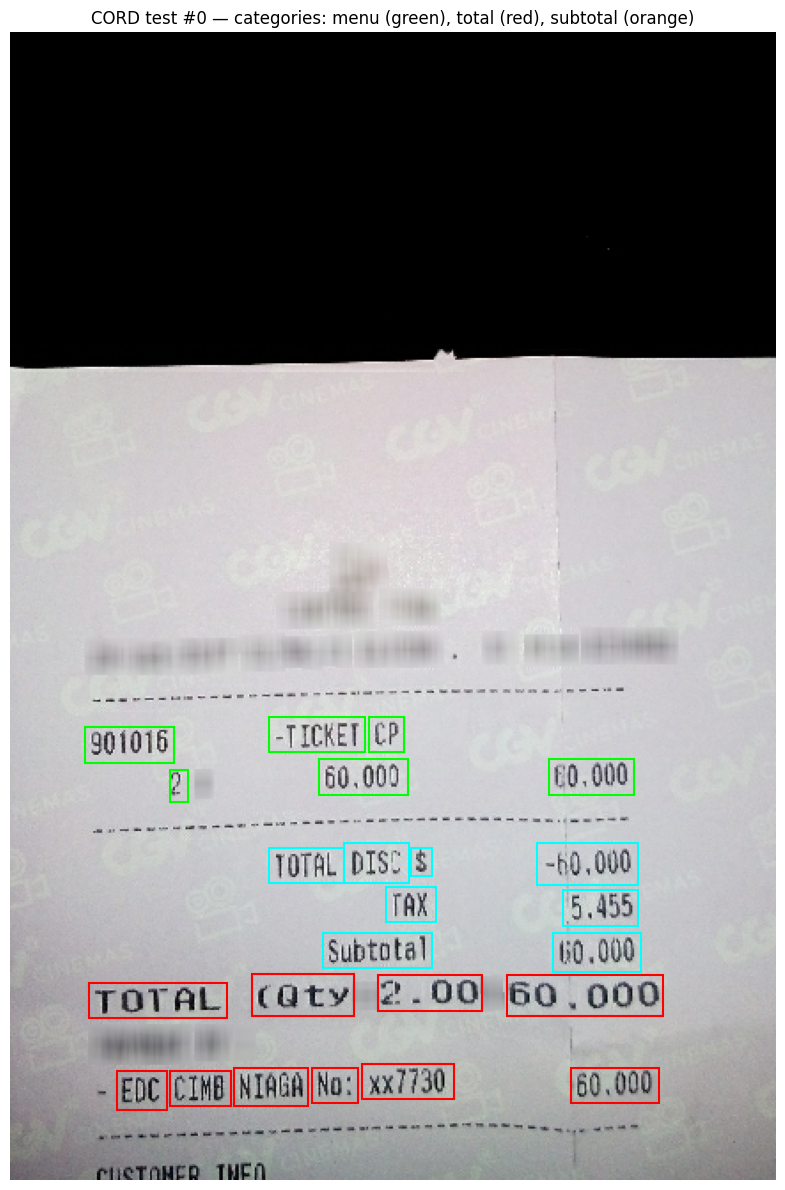

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

ex = cord['test'][0]
img = ex['image']
gt = json.loads(ex['ground_truth'])
W, H = img.size

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
ax.imshow(img)

# Color by category prefix (menu / total / subtotal / void / etc.)
prefix_colors = {
    'menu': 'lime',
    'total': 'red',
    'subtotal': 'orange',
    'void_menu': 'gray',
}

for line in gt.get('valid_line', []):
    category = line.get('category', '')
    prefix = category.split('.')[0]
    color = prefix_colors.get(prefix, 'cyan')

    for word in line.get('words', []):
        box = word.get('quad', {})
        if not box:
            continue
        # CORD boxes are quads (x1,y1)..(x4,y4)
        xs = [box.get(f'x{i}', 0) for i in range(1, 5)]
        ys = [box.get(f'y{i}', 0) for i in range(1, 5)]
        x0, y0 = min(xs), min(ys)
        x1, y1 = max(xs), max(ys)
        ax.add_patch(patches.Rectangle(
            (x0, y0), x1-x0, y1-y0,
            linewidth=1.5, edgecolor=color, facecolor='none'
        ))

ax.set_title(f"CORD test #{0} — categories: menu (green), total (red), subtotal (orange)")
ax.axis('off')
plt.tight_layout()
plt.show()

Step 8: Build a CORD → "SROIE-compatible" converter

In [ ]:
# Convert CORD examples to the same format our inference pipeline expects:
# words list, pixel-space polygons list, and gold total string.

def cord_to_inference_format(example):
    """Convert one CORD example to (words, polygons, gold_total)."""
    img = example['image']
    W, H = img.size

    gt = json.loads(example['ground_truth'])

    words, polygons = [], []
    gold_total_words = []

    for line in gt.get('valid_line', []):
        category = line.get('category', '')

        for word in line.get('words', []):
            text = word.get('text', '').strip()
            if not text:
                continue

            box = word.get('quad', {})
            poly = [
                [box.get('x1', 0), box.get('y1', 0)],
                [box.get('x2', 0), box.get('y2', 0)],
                [box.get('x3', 0), box.get('y3', 0)],
                [box.get('x4', 0), box.get('y4', 0)],
            ]
            words.append(text)
            polygons.append(poly)

            if category == 'total.total_price':
                gold_total_words.append(text)

    gold_total = ' '.join(gold_total_words).strip()
    return img, words, polygons, gold_total


# Test on one example
img, words, polys, gold_total = cord_to_inference_format(cord['test'][0])
print(f"Example 0:")
print(f"  Image size      : {img.size}")
print(f"  N words         : {len(words)}")
print(f"  Gold total      : {gold_total!r}")
print(f"  First 10 words  : {words[:10]}")

Example 0:
  Image size      : (432, 648)
  N words         : 24
  Gold total      : 'TOTAL 60.000'
  First 10 words  : ['901016', '-TICKET', 'CP', '2', '60.000', '60.000', 'TOTAL', 'DISC', '$', '-60.000']


Step 9: Load the model and run zero-shot inference on CORD test

In [ ]:
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification

processor = LayoutLMv3Processor.from_pretrained(BEST_CKPT_DIR, apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained(BEST_CKPT_DIR).to(DEVICE)
model.eval()

MAX_LENGTH = 512
LABELS = ['O', 'B-COMPANY', 'I-COMPANY', 'B-DATE', 'I-DATE',
          'B-ADDRESS', 'I-ADDRESS', 'B-TOTAL', 'I-TOTAL']
ID2LABEL = {i: l for i, l in enumerate(LABELS)}
ENTITY_FIELDS = ['company', 'date', 'address', 'total']


def normalize_box(polygon, W, H):
    xs = [p[0] for p in polygon]; ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / W))),
        max(0, min(1000, int(1000 * y0 / H))),
        max(0, min(1000, int(1000 * x1 / W))),
        max(0, min(1000, int(1000 * y1 / H))),
    ]


def predict_on_cord_example(img, words, polys):
    W, H = img.size
    boxes = [normalize_box(p, W, H) for p in polys]

    encoded = processor(
        img, words, boxes=boxes,
        return_tensors='pt',
        truncation=True, padding='max_length', max_length=MAX_LENGTH,
    )
    tokenized = processor.tokenizer(
        words, boxes=boxes,
        truncation=True, padding='max_length', max_length=MAX_LENGTH,
    )

    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    with torch.no_grad():
        subword_preds = model(**encoded).logits.argmax(dim=-1)[0].cpu().tolist()

    word_preds = [None] * len(words)
    for sub_idx, word_idx in enumerate(tokenized.word_ids()):
        if word_idx is None or word_idx >= len(words):
            continue
        if word_preds[word_idx] is None:
            word_preds[word_idx] = subword_preds[sub_idx]

    word_labels = [ID2LABEL[p] if p is not None else 'O' for p in word_preds]

    entities = {f: '' for f in ENTITY_FIELDS}
    current_field, current_tokens = None, []

    def flush():
        nonlocal current_field, current_tokens
        if current_field and current_tokens:
            text = ' '.join(current_tokens).strip()
            key = current_field.lower()
            entities[key] = entities[key] + ' ' + text if entities[key] else text
        current_field, current_tokens = None, []

    for word, label in zip(words, word_labels):
        if label == 'O':
            flush()
        elif label.startswith('B-'):
            flush()
            current_field = label[2:]
            current_tokens = [word]
        elif label.startswith('I-'):
            if current_field == label[2:]:
                current_tokens.append(word)
            else:
                flush()
                current_field = label[2:]
                current_tokens = [word]
    flush()
    return entities


# Run on entire CORD test set
cord_predictions = []
for ex in tqdm(cord['test'], desc="CORD inference"):
    img, words, polys, gold_total = cord_to_inference_format(ex)
    if not words:
        continue
    pred_entities = predict_on_cord_example(img, words, polys)
    cord_predictions.append({
        'entities_pred':  pred_entities,
        'entities_gold':  {'company': '', 'date': '', 'address': '', 'total': gold_total},
    })

print(f"\nCompleted inference on {len(cord_predictions)} CORD test examples.")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

CORD inference: 100%|██████████| 100/100 [00:25<00:00,  3.94it/s]


Completed inference on 100 CORD test examples.


Step 10: Compute the cross-dataset metric

In [ ]:
from rapidfuzz import fuzz

def normalize(s):
    return ' '.join(s.lower().split()) if s else ''

def exact_match(p, g):
    return normalize(p) == normalize(g)

def fuzzy_match(p, g, t=80):
    np_, ng_ = normalize(p), normalize(g)
    if not np_ and not ng_: return True
    if not np_ or not ng_:  return False
    return fuzz.ratio(np_, ng_) >= t


def compute_metrics_one_field(preds, field, match_fn):
    tp, fp, fn = 0, 0, 0
    for p in preds:
        gold = normalize(p['entities_gold'][field])
        pred = normalize(p['entities_pred'][field])
        gp, pp = bool(gold), bool(pred)
        if gp and pp:
            if match_fn(pred, gold):
                tp += 1
            else:
                fp += 1; fn += 1
        elif gp and not pp:
            fn += 1
        elif not gp and pp:
            fp += 1
    P = tp/(tp+fp) if (tp+fp) > 0 else 0
    R = tp/(tp+fn) if (tp+fn) > 0 else 0
    F1 = 2*P*R/(P+R) if (P+R) > 0 else 0
    return {'tp':tp,'fp':fp,'fn':fn,'precision':P,'recall':R,'f1':F1}


print(f"=== CORD zero-shot results — TOTAL field only ===\n")
print(f"  {'metric':<8}  {'P':>6}  {'R':>6}  {'F1':>6}  {'TP':>4}  {'FP':>4}  {'FN':>4}")
print('-' * 50)
for name, fn in [('exact', exact_match), ('fuzzy_80', fuzzy_match)]:
    m = compute_metrics_one_field(cord_predictions, 'total', fn)
    print(f"  {name:<8}  {m['precision']:>6.3f}  {m['recall']:>6.3f}  {m['f1']:>6.3f}  "
          f"{m['tp']:>4}  {m['fp']:>4}  {m['fn']:>4}")

=== CORD zero-shot results — TOTAL field only ===

  metric         P       R      F1    TP    FP    FN
--------------------------------------------------
  exact      0.000   0.000   0.000     0    97    95
  fuzzy_80   0.021   0.021   0.021     2    95    93


Step 11: Compare SROIE vs CORD for the total field

In [ ]:
# Load SROIE final results for direct comparison
with open(f'{PROJECT_DIR}/outputs/test_evaluation/test_evaluation_FINAL.json', 'r') as f:
    sroie_final = json.load(f)

sroie_total_exact = sroie_final['metrics']['exact']['per_field']['total']['f1']
sroie_total_fuzzy = sroie_final['metrics']['fuzzy_80']['per_field']['total']['f1']

cord_exact = compute_metrics_one_field(cord_predictions, 'total', exact_match)
cord_fuzzy = compute_metrics_one_field(cord_predictions, 'total', fuzzy_match)

print(f"=== TOTAL field — SROIE (in-domain) vs CORD (zero-shot transfer) ===\n")
print(f"  {'metric':<8}  {'SROIE F1':>10}  {'CORD F1':>10}  {'gap':>8}")
print('-' * 45)
print(f"  {'exact':<8}  {sroie_total_exact:>10.4f}  {cord_exact['f1']:>10.4f}  "
      f"{cord_exact['f1'] - sroie_total_exact:>+8.4f}")
print(f"  {'fuzzy':<8}  {sroie_total_fuzzy:>10.4f}  {cord_fuzzy['f1']:>10.4f}  "
      f"{cord_fuzzy['f1'] - sroie_total_fuzzy:>+8.4f}")

=== TOTAL field — SROIE (in-domain) vs CORD (zero-shot transfer) ===

  metric      SROIE F1     CORD F1       gap
---------------------------------------------
  exact         0.8281      0.0000   -0.8281
  fuzzy         0.8729      0.0208   -0.8521


Step 12: Save the CORD evaluation

In [ ]:
cord_evaluation = {
    'dataset':              'CORD-v2 (naver-clova-ix/cord-v2)',
    'split':                'test',
    'n_examples':           len(cord_predictions),
    'model_checkpoint':     BEST_CKPT_DIR,
    'methodology':          'zero-shot transfer (no fine-tuning on CORD)',
    'schema_reconciliation': {
        'evaluated_fields':     ['total'],
        'unevaluated_fields':   ['company', 'date', 'address'],
        'reason':               'CORD does not annotate company/date/address as top-level entities',
        'cord_to_sroie_map':    CORD_TO_SROIE,
    },
    'metrics': {
        'total_exact':    cord_exact,
        'total_fuzzy_80': cord_fuzzy,
    },
    'comparison_to_sroie': {
        'sroie_total_exact_f1':  sroie_total_exact,
        'sroie_total_fuzzy_f1':  sroie_total_fuzzy,
        'cord_total_exact_f1':   cord_exact['f1'],
        'cord_total_fuzzy_f1':   cord_fuzzy['f1'],
        'exact_gap':             cord_exact['f1'] - sroie_total_exact,
        'fuzzy_gap':             cord_fuzzy['f1'] - sroie_total_fuzzy,
    },
}

with open(f'{CORD_OUT_DIR}/cord_evaluation.json', 'w') as f:
    json.dump(cord_evaluation, f, indent=2)

# Also save the raw predictions
with open(f'{CORD_OUT_DIR}/cord_predictions.json', 'w') as f:
    json.dump(cord_predictions, f, indent=2, ensure_ascii=False)

print(f"Saved:")
print(f"  {CORD_OUT_DIR}/cord_evaluation.json")
print(f"  {CORD_OUT_DIR}/cord_predictions.json")

Saved:
  /content/drive/MyDrive/doc-understanding/outputs/cord_evaluation/cord_evaluation.json
  /content/drive/MyDrive/doc-understanding/outputs/cord_evaluation/cord_predictions.json


**START OF DAY 17**

Step 0: Reconnect the colab notebook

In [ ]:
import os, json, torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from collections import Counter

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR        = '/content/drive/MyDrive/doc-understanding'
WILDRECEIPT_OUT    = f'{PROJECT_DIR}/outputs/wildreceipt_evaluation'
SYNTHESIS_DIR      = f'{PROJECT_DIR}/outputs/cross_dataset_synthesis'

FINAL_MODEL_DIR    = f'{PROJECT_DIR}/models/layoutlmv3_FINAL'
BEST_CKPT_DIR      = f'{FINAL_MODEL_DIR}/best'

os.makedirs(WILDRECEIPT_OUT, exist_ok=True)
os.makedirs(SYNTHESIS_DIR, exist_ok=True)

print("Paths configured.")

Device: cpu
Mounted at /content/drive
Paths configured.


Step 1: Install packages

In [ ]:
!pip install -q "transformers>=4.40" rapidfuzz
!pip install -q "datasets<3.0"

Step 2: Download Wildreceipt

In [ ]:
import os
import tarfile

WR_MANUAL_DIR = f'{PROJECT_DIR}/data/wildreceipt_manual'
os.makedirs(WR_MANUAL_DIR, exist_ok=True)

# Download from the official OpenMMLab mirror (~600 MB; ~3-5 minutes)
TAR_PATH = f'{WR_MANUAL_DIR}/wildreceipt.tar'
if not os.path.exists(TAR_PATH):
    print("Downloading WildReceipt from OpenMMLab...")
    !wget -q -O {TAR_PATH} https://download.openmmlab.com/mmocr/data/wildreceipt.tar
    print("Extracting...")
    with tarfile.open(TAR_PATH) as tf:
        tf.extractall(WR_MANUAL_DIR)
    print("Done.")
else:
    print("Already downloaded.")

WR_ROOT = f'{WR_MANUAL_DIR}/wildreceipt'
print(f"\nContents of {WR_ROOT}:")
!ls {WR_ROOT}

Extracting...


/tmp/ipykernel_16434/1667554063.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tf.extractall(WR_MANUAL_DIR)


Done.

Contents of /content/drive/MyDrive/doc-understanding/data/wildreceipt_manual/wildreceipt:
class_list.txt	dict.txt  image_files  test.txt  train.txt


Step 3: Explore one Wildreceipt example and inventory Wildreceipt's  (Parser + Inventory)

In [ ]:
import json

# Load the class list (line N = label index N)
with open(f'{WR_ROOT}/class_list.txt', 'r') as f:
    class_list_lines = [line.strip() for line in f if line.strip()]

# Each line is like "0 Ignore", "1 Store_name_value", etc.
label_names = []
for line in class_list_lines:
    parts = line.split(maxsplit=1)
    if len(parts) == 2:
        label_names.append(parts[1])
    else:
        label_names.append(parts[0])

print(f"Total classes: {len(label_names)}")
print(f"\nAll classes:")
for i, name in enumerate(label_names):
    print(f"  {i:>3}: {name}")


# Parse test.txt (each line is a JSON object describing one receipt)
test_examples = []
with open(f'{WR_ROOT}/test.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        test_examples.append(json.loads(line))

print(f"\n\nLoaded {len(test_examples)} test examples.")
print(f"\nFirst example keys: {list(test_examples[0].keys())}")
print(f"First example file_name: {test_examples[0]['file_name']}")
print(f"First example has {len(test_examples[0]['annotations'])} annotation regions.")
print(f"\nFirst annotation:")
print(json.dumps(test_examples[0]['annotations'][0], indent=2))

Total classes: 26

All classes:
    0: Ignore
    1: Store_name_value
    2: Store_name_key
    3: Store_addr_value
    4: Store_addr_key
    5: Tel_value
    6: Tel_key
    7: Date_value
    8: Date_key
    9: Time_value
   10: Time_key
   11: Prod_item_value
   12: Prod_item_key
   13: Prod_quantity_value
   14: Prod_quantity_key
   15: Prod_price_value
   16: Prod_price_key
   17: Subtotal_value
   18: Subtotal_key
   19: Tax_value
   20: Tax_key
   21: Tips_value
   22: Tips_key
   23: Total_value
   24: Total_key
   25: Others


Loaded 472 test examples.

First example keys: ['file_name', 'height', 'width', 'annotations']
First example file_name: image_files/Image_12/10/845be0dd6f5b04866a2042abd28d558032ef2576.jpeg
First example has 26 annotation regions.

First annotation:
{
  "box": [
    114.0,
    19.0,
    230.0,
    19.0,
    230.0,
    1.0,
    114.0,
    1.0
  ],
  "text": "CHOEUN",
  "label": 1
}


Step 5: Visualize one WildReceipt

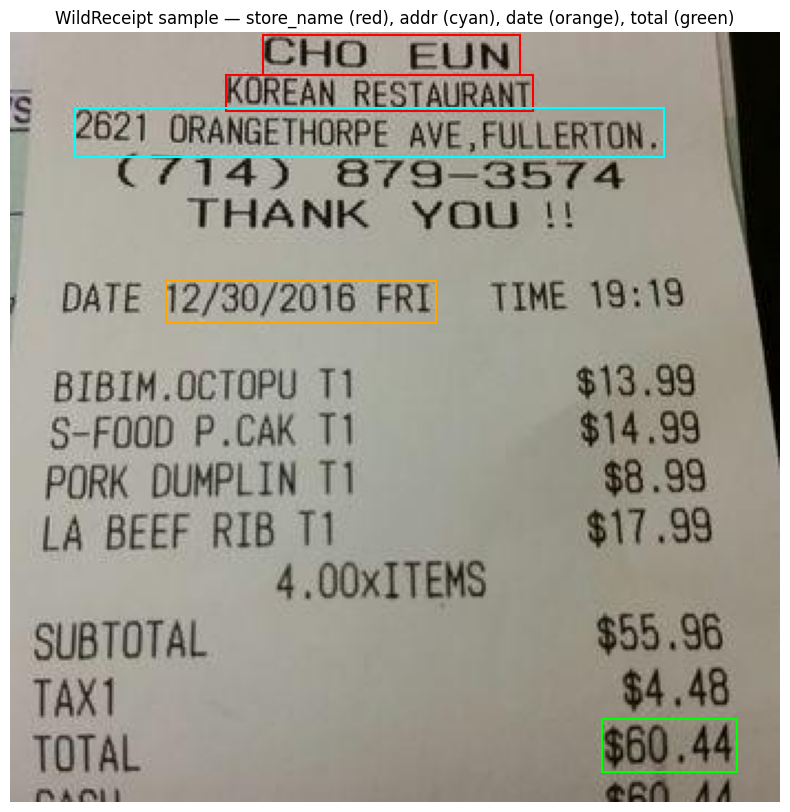

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

TARGET_LABEL_TO_COLOR = {
    'Store_name_value': 'red',
    'Store_addr_value': 'cyan',
    'Date_value':       'orange',
    'Total_value':      'lime',
}

ex = test_examples[0]
img_path = f"{WR_ROOT}/{ex['file_name']}"
img = Image.open(img_path).convert('RGB')
W, H = img.size

fig, ax = plt.subplots(1, 1, figsize=(8, 12))
ax.imshow(img)

for ann in ex['annotations']:
    label_name = label_names[ann['label']]
    color = TARGET_LABEL_TO_COLOR.get(label_name, None)
    if color is None:
        continue

    box = ann['box']
    xs = box[0::2]   # x coords: positions 0, 2, 4, 6
    ys = box[1::2]   # y coords: positions 1, 3, 5, 7
    x0, y0 = min(xs), min(ys)
    x1, y1 = max(xs), max(ys)
    ax.add_patch(patches.Rectangle((x0, y0), x1-x0, y1-y0,
                                    linewidth=1.5, edgecolor=color, facecolor='none'))

ax.set_title("WildReceipt sample — store_name (red), addr (cyan), date (orange), total (green)")
ax.axis('off')
plt.tight_layout()
plt.show()

Step 6: Build the WildReceipt → SROIE field mapping

In [ ]:
# Direct 1:1 mapping (unlike CORD where most fields had no analog).
WILDRECEIPT_TO_SROIE = {
    'Store_name_value': 'company',
    'Store_addr_value': 'address',
    'Date_value':       'date',
    'Total_value':      'total',
}

# Verify these labels exist in WildReceipt's label set
print("Schema reconciliation: WildReceipt → SROIE\n")
print(f"  {'WildReceipt label':<25}  →  {'SROIE field':<10}  {'exists in dataset?':>18}")
print('-' * 65)
for wr_label, sroie_field in WILDRECEIPT_TO_SROIE.items():
    exists = wr_label in label_names
    print(f"  {wr_label:<25}  →  {sroie_field:<10}  {'✓ yes' if exists else '✗ NOT FOUND':>18}")

print(f"\nIf any of the above show 'NOT FOUND', adjust label names in WILDRECEIPT_TO_SROIE")
print(f"to match WildReceipt's actual naming (may differ slightly in some versions).")

Schema reconciliation: WildReceipt → SROIE

  WildReceipt label          →  SROIE field  exists in dataset?
-----------------------------------------------------------------
  Store_name_value           →  company                  ✓ yes
  Store_addr_value           →  address                  ✓ yes
  Date_value                 →  date                     ✓ yes
  Total_value                →  total                    ✓ yes

If any of the above show 'NOT FOUND', adjust label names in WILDRECEIPT_TO_SROIE
to match WildReceipt's actual naming (may differ slightly in some versions).


Step 7: Convert WildReceipt examples to inference format


In [ ]:
ENTITY_FIELDS = ['company', 'date', 'address', 'total']

WILDRECEIPT_TO_SROIE = {
    'Store_name_value': 'company',
    'Store_addr_value': 'address',
    'Date_value':       'date',
    'Total_value':      'total',
}


def wildreceipt_manual_to_inference(example):
    """
    Convert one MMOCR-format WildReceipt example to (img, words, polygons, gold_entities).
    """
    img_path = f"{WR_ROOT}/{example['file_name']}"
    img = Image.open(img_path).convert('RGB')

    words = []
    polygons = []
    gold = {f: [] for f in ENTITY_FIELDS}

    for ann in example['annotations']:
        box = ann['box']     # 8 numbers
        text = ann['text']
        label_name = label_names[ann['label']]

        # Build 4-corner polygon
        poly = [[box[0], box[1]], [box[2], box[3]],
                [box[4], box[5]], [box[6], box[7]]]

        words.append(text)
        polygons.append(poly)

        # Aggregate gold text by SROIE field
        sroie_field = WILDRECEIPT_TO_SROIE.get(label_name)
        if sroie_field:
            gold[sroie_field].append(text)

    gold_entities = {f: ' '.join(gold[f]).strip() for f in ENTITY_FIELDS}
    return img, words, polygons, gold_entities


# Test on one example
img, words, polys, gold = wildreceipt_manual_to_inference(test_examples[0])
print(f"Test example:")
print(f"  Image size: {img.size}")
print(f"  N words:    {len(words)}")
print(f"\n  Gold entities:")
for f, v in gold.items():
    v_short = (v[:60] + '...') if len(v) > 60 else v
    print(f"    {f:>8}: {v_short!r}")

Test example:
  Image size: (348, 348)
  N words:    26

  Gold entities:
     company: 'CHOEUN KOREANRESTAURANT'
        date: '12/30/2016FRI'
     address: '2621ORANGETHORPEAVE,FULLERTON.'
       total: '$60.44'


Step 8: Run zero-shot inference on WildReceipt test set

In [ ]:
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification

processor = LayoutLMv3Processor.from_pretrained(BEST_CKPT_DIR, apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained(BEST_CKPT_DIR).to(DEVICE)
model.eval()

MAX_LENGTH = 512
SROIE_LABELS = ['O', 'B-COMPANY', 'I-COMPANY', 'B-DATE', 'I-DATE',
                'B-ADDRESS', 'I-ADDRESS', 'B-TOTAL', 'I-TOTAL']
ID2LABEL = {i: l for i, l in enumerate(SROIE_LABELS)}


def normalize_box_xyxy(bbox, W, H):
    x0, y0, x1, y1 = bbox
    return [
        max(0, min(1000, int(1000 * x0 / W))),
        max(0, min(1000, int(1000 * y0 / H))),
        max(0, min(1000, int(1000 * x1 / W))),
        max(0, min(1000, int(1000 * y1 / H))),
    ]


def predict_on_example(img, words, bboxes_xyxy):
    W, H = img.size
    boxes = [normalize_box_xyxy(b, W, H) for b in bboxes_xyxy]

    encoded = processor(
        img, words, boxes=boxes,
        return_tensors='pt',
        truncation=True, padding='max_length', max_length=MAX_LENGTH,
    )
    tokenized = processor.tokenizer(
        words, boxes=boxes,
        truncation=True, padding='max_length', max_length=MAX_LENGTH,
    )

    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}
    with torch.no_grad():
        subword_preds = model(**encoded).logits.argmax(dim=-1)[0].cpu().tolist()

    word_preds = [None] * len(words)
    for sub_idx, word_idx in enumerate(tokenized.word_ids()):
        if word_idx is None or word_idx >= len(words):
            continue
        if word_preds[word_idx] is None:
            word_preds[word_idx] = subword_preds[sub_idx]

    word_labels = [ID2LABEL[p] if p is not None else 'O' for p in word_preds]

    entities = {f: '' for f in ENTITY_FIELDS}
    current_field, current_tokens = None, []

    def flush():
        nonlocal current_field, current_tokens
        if current_field and current_tokens:
            text = ' '.join(current_tokens).strip()
            key = current_field.lower()
            entities[key] = entities[key] + ' ' + text if entities[key] else text
        current_field, current_tokens = None, []

    for word, label in zip(words, word_labels):
        if label == 'O':
            flush()
        elif label.startswith('B-'):
            flush()
            current_field = label[2:]
            current_tokens = [word]
        elif label.startswith('I-'):
            if current_field == label[2:]:
                current_tokens.append(word)
            else:
                flush()
                current_field = label[2:]
                current_tokens = [word]
    flush()
    return entities


# Run on all WildReceipt test examples
wildreceipt_predictions = []
for ex in tqdm(test_examples, desc="WildReceipt inference"):
    img, words, polys, gold = wildreceipt_manual_to_inference(ex)
    if not words:
        continue

    bboxes_xyxy = []
    for poly in polys:
        xs = [p[0] for p in poly]
        ys = [p[1] for p in poly]
        bboxes_xyxy.append([min(xs), min(ys), max(xs), max(ys)])

    pred_entities = predict_on_example(img, words, bboxes_xyxy)
    wildreceipt_predictions.append({
        'entities_pred': pred_entities,
        'entities_gold': gold,
    })

print(f"\nInference complete on {len(wildreceipt_predictions)} WildReceipt examples.")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

WildReceipt inference: 100%|██████████| 472/472 [26:55<00:00,  3.42s/it]


Inference complete on 472 WildReceipt examples.


Step 9: Compute per-field F1 on WildReceipt

In [ ]:
from rapidfuzz import fuzz

def normalize(s):
    return ' '.join(s.lower().split()) if s else ''

def exact_match(p, g):
    return normalize(p) == normalize(g)

def fuzzy_match(p, g, t=80):
    np_, ng_ = normalize(p), normalize(g)
    if not np_ and not ng_: return True
    if not np_ or not ng_:  return False
    return fuzz.ratio(np_, ng_) >= t


def compute_field_metrics(preds, field, match_fn):
    tp, fp, fn = 0, 0, 0
    for p in preds:
        gold = p['entities_gold'][field]
        pred = p['entities_pred'][field]
        gp, pp = bool(normalize(gold)), bool(normalize(pred))
        if gp and pp:
            if match_fn(pred, gold): tp += 1
            else: fp += 1; fn += 1
        elif gp and not pp: fn += 1
        elif not gp and pp: fp += 1
    P = tp/(tp+fp) if (tp+fp) > 0 else 0
    R = tp/(tp+fn) if (tp+fn) > 0 else 0
    F1 = 2*P*R/(P+R) if (P+R) > 0 else 0
    return {'tp':tp,'fp':fp,'fn':fn,'precision':P,'recall':R,'f1':F1}


wr_exact = {f: compute_field_metrics(wildreceipt_predictions, f, exact_match) for f in ENTITY_FIELDS}
wr_fuzzy = {f: compute_field_metrics(wildreceipt_predictions, f, fuzzy_match) for f in ENTITY_FIELDS}

print(f"=== WildReceipt zero-shot: EXACT MATCH ===\n")
print(f"  {'field':>8}  {'P':>6}  {'R':>6}  {'F1':>6}  {'TP':>4}  {'FP':>4}  {'FN':>4}")
print('-' * 50)
for f in ENTITY_FIELDS:
    m = wr_exact[f]
    print(f"  {f:>8}  {m['precision']:>6.3f}  {m['recall']:>6.3f}  {m['f1']:>6.3f}  "
          f"{m['tp']:>4}  {m['fp']:>4}  {m['fn']:>4}")

print(f"\n=== WildReceipt zero-shot: FUZZY MATCH ===\n")
print(f"  {'field':>8}  {'P':>6}  {'R':>6}  {'F1':>6}  {'TP':>4}  {'FP':>4}  {'FN':>4}")
print('-' * 50)
for f in ENTITY_FIELDS:
    m = wr_fuzzy[f]
    print(f"  {f:>8}  {m['precision']:>6.3f}  {m['recall']:>6.3f}  {m['f1']:>6.3f}  "
          f"{m['tp']:>4}  {m['fp']:>4}  {m['fn']:>4}")

=== WildReceipt zero-shot: EXACT MATCH ===

     field       P       R      F1    TP    FP    FN
--------------------------------------------------
   company   0.558   0.123   0.201    58    46   414
      date   0.939   0.618   0.745   246    16   152
   address   0.326   0.082   0.131    30    62   336
     total   0.515   0.365   0.427   154   145   268

=== WildReceipt zero-shot: FUZZY MATCH ===

     field       P       R      F1    TP    FP    FN
--------------------------------------------------
   company   0.606   0.133   0.219    63    41   409
      date   0.939   0.618   0.745   246    16   152
   address   0.337   0.085   0.135    31    61   335
     total   0.522   0.370   0.433   156   143   266


Step 10: Direct comparison: SROIE in-domain vs WildReceipt zero-shot

In [ ]:
with open(f'{PROJECT_DIR}/outputs/test_evaluation/test_evaluation_FINAL.json', 'r') as f:
    sroie_final = json.load(f)

sroie_exact = sroie_final['metrics']['exact']['per_field']
sroie_fuzzy = sroie_final['metrics']['fuzzy_80']['per_field']

print(f"=== Per-field F1: SROIE (in-domain) vs WildReceipt (zero-shot) ===\n")
print(f"  {'field':>8}  {'SROIE exact':>12}  {'WR exact':>9}  {'Δ exact':>9}  "
      f"{'SROIE fuzzy':>12}  {'WR fuzzy':>9}  {'Δ fuzzy':>9}")
print('-' * 80)
for f in ENTITY_FIELDS:
    se, sf = sroie_exact[f]['f1'], sroie_fuzzy[f]['f1']
    we, wf = wr_exact[f]['f1'], wr_fuzzy[f]['f1']
    print(f"  {f:>8}  {se:>12.4f}  {we:>9.4f}  {we-se:>+9.4f}  "
          f"{sf:>12.4f}  {wf:>9.4f}  {wf-sf:>+9.4f}")


# Aggregates
def aggregate(metrics):
    f1s = [m['f1'] for m in metrics.values()]
    tp = sum(m['tp'] for m in metrics.values())
    fp = sum(m['fp'] for m in metrics.values())
    fn = sum(m['fn'] for m in metrics.values())
    micro_p = tp/(tp+fp) if (tp+fp) > 0 else 0
    micro_r = tp/(tp+fn) if (tp+fn) > 0 else 0
    micro_f1 = 2*micro_p*micro_r/(micro_p+micro_r) if (micro_p+micro_r) > 0 else 0
    return {'macro_f1': sum(f1s)/len(f1s), 'micro_f1': micro_f1}

wr_exact_agg = aggregate(wr_exact)
wr_fuzzy_agg = aggregate(wr_fuzzy)
sroie_exact_agg = sroie_final['metrics']['exact']['aggregate']
sroie_fuzzy_agg = sroie_final['metrics']['fuzzy_80']['aggregate']

print(f"\n=== Aggregate: SROIE vs WildReceipt ===\n")
print(f"  {'metric':<14}  {'SROIE':>10}  {'WildReceipt':>11}  {'Δ':>10}")
print('-' * 50)
print(f"  {'macro F1 exact':<14}  {sroie_exact_agg['macro_f1']:>10.4f}  "
      f"{wr_exact_agg['macro_f1']:>11.4f}  {wr_exact_agg['macro_f1']-sroie_exact_agg['macro_f1']:>+10.4f}")
print(f"  {'macro F1 fuzzy':<14}  {sroie_fuzzy_agg['macro_f1']:>10.4f}  "
      f"{wr_fuzzy_agg['macro_f1']:>11.4f}  {wr_fuzzy_agg['macro_f1']-sroie_fuzzy_agg['macro_f1']:>+10.4f}")

=== Per-field F1: SROIE (in-domain) vs WildReceipt (zero-shot) ===

     field   SROIE exact   WR exact    Δ exact   SROIE fuzzy   WR fuzzy    Δ fuzzy
--------------------------------------------------------------------------------
   company        0.2050     0.2014    -0.0036        0.8385     0.2188    -0.6198
      date        0.2382     0.7455    +0.5073        0.5380     0.7455    +0.2075
   address        0.0866     0.1310    +0.0444        0.9668     0.1354    -0.8314
     total        0.8281     0.4272    -0.4009        0.8729     0.4327    -0.4402

=== Aggregate: SROIE vs WildReceipt ===

  metric               SROIE  WildReceipt           Δ
--------------------------------------------------
  macro F1 exact      0.3395       0.3763     +0.0368
  macro F1 fuzzy      0.8041       0.3831     -0.4210


Step 11: Three-dataset synthesis (SROIE + WildReceipt + CORD)

In [ ]:
with open(f'{PROJECT_DIR}/outputs/cord_evaluation/cord_evaluation.json', 'r') as f:
    cord_eval = json.load(f)

summary = {
    'datasets': {
        'sroie': {
            'description':       'SROIE 2019 — Malaysian retail receipts (in-domain training)',
            'n_test_examples':   sroie_final['n_receipts'],
            'evaluable_fields':  ENTITY_FIELDS,
            'per_field_f1_exact': {f: sroie_exact[f]['f1'] for f in ENTITY_FIELDS},
            'per_field_f1_fuzzy': {f: sroie_fuzzy[f]['f1'] for f in ENTITY_FIELDS},
            'macro_f1_exact':    sroie_exact_agg['macro_f1'],
            'macro_f1_fuzzy':    sroie_fuzzy_agg['macro_f1'],
        },
        'wildreceipt': {
            'description':       'WildReceipt — international real-world receipts (zero-shot)',
            'n_test_examples':   len(wildreceipt_predictions),
            'evaluable_fields':  ENTITY_FIELDS,
            'per_field_f1_exact': {f: wr_exact[f]['f1'] for f in ENTITY_FIELDS},
            'per_field_f1_fuzzy': {f: wr_fuzzy[f]['f1'] for f in ENTITY_FIELDS},
            'macro_f1_exact':    wr_exact_agg['macro_f1'],
            'macro_f1_fuzzy':    wr_fuzzy_agg['macro_f1'],
        },
        'cord': {
            'description':       'CORD-v2 — Indonesian receipts, menu-focused (zero-shot, schema mismatch)',
            'n_test_examples':   cord_eval['n_examples'],
            'evaluable_fields':  ['total'],
            'per_field_f1_exact': {'total': cord_eval['metrics']['total_exact']['f1']},
            'per_field_f1_fuzzy': {'total': cord_eval['metrics']['total_fuzzy_80']['f1']},
            'note':               'company/date/address have no CORD analog; total only',
        },
    },
}

with open(f'{SYNTHESIS_DIR}/three_dataset_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

# Print the final summary table
print(f"\n=== Three-Dataset Evaluation Summary (final) ===\n")
print(f"  {'dataset':<13}  {'n':>5}  {'company F1':>11}  {'date F1':>8}  "
      f"{'address F1':>11}  {'total F1':>9}  {'macro F1':>9}")
print('-' * 85)
print(f"  Fuzzy match (fuzz.ratio >= 80):")
for ds_key, ds in summary['datasets'].items():
    name = ds_key
    n = ds['n_test_examples']
    co = ds['per_field_f1_fuzzy'].get('company')
    da = ds['per_field_f1_fuzzy'].get('date')
    ad = ds['per_field_f1_fuzzy'].get('address')
    to = ds['per_field_f1_fuzzy'].get('total')
    macro = ds.get('macro_f1_fuzzy')
    co_s = f"{co:.4f}" if co is not None else "  N/A   "
    da_s = f"{da:.4f}" if da is not None else "  N/A   "
    ad_s = f"{ad:.4f}" if ad is not None else "  N/A   "
    to_s = f"{to:.4f}" if to is not None else "  N/A   "
    macro_s = f"{macro:.4f}" if macro is not None else "  N/A   "
    print(f"  {name:<13}  {n:>5}  {co_s:>11}  {da_s:>8}  {ad_s:>11}  {to_s:>9}  {macro_s:>9}")


=== Three-Dataset Evaluation Summary (final) ===

  dataset            n   company F1   date F1   address F1   total F1   macro F1
-------------------------------------------------------------------------------------
  Fuzzy match (fuzz.ratio >= 80):
  sroie            347       0.8385    0.5380       0.9668     0.8729     0.8041
  wildreceipt      472       0.2188    0.7455       0.1354     0.4327     0.3831
  cord             100       N/A       N/A          N/A        0.0208     N/A   


Step 12: Save outputs

In [ ]:
with open(f'{WILDRECEIPT_OUT}/wildreceipt_evaluation.json', 'w') as f:
    json.dump({
        'dataset':              'WildReceipt (Theivaprakasham/wildreceipt)',
        'n_test_examples':      len(wildreceipt_predictions),
        'methodology':          'Zero-shot evaluation; model trained only on SROIE.',
        'schema_mapping':       WILDRECEIPT_TO_SROIE,
        'per_field_exact':      wr_exact,
        'per_field_fuzzy_80':   wr_fuzzy,
        'aggregate_exact':      wr_exact_agg,
        'aggregate_fuzzy_80':   wr_fuzzy_agg,
        'comparison_to_sroie': {
            'sroie_macro_f1_exact':    sroie_exact_agg['macro_f1'],
            'sroie_macro_f1_fuzzy':    sroie_fuzzy_agg['macro_f1'],
            'wr_macro_f1_exact':       wr_exact_agg['macro_f1'],
            'wr_macro_f1_fuzzy':       wr_fuzzy_agg['macro_f1'],
            'exact_macro_gap':         wr_exact_agg['macro_f1'] - sroie_exact_agg['macro_f1'],
            'fuzzy_macro_gap':         wr_fuzzy_agg['macro_f1'] - sroie_fuzzy_agg['macro_f1'],
        },
    }, f, indent=2)

with open(f'{WILDRECEIPT_OUT}/wildreceipt_predictions.json', 'w') as f:
    json.dump(wildreceipt_predictions, f, indent=2, ensure_ascii=False)

print(f"\nSaved:")
print(f"  {WILDRECEIPT_OUT}/wildreceipt_evaluation.json")
print(f"  {WILDRECEIPT_OUT}/wildreceipt_predictions.json")
print(f"  {SYNTHESIS_DIR}/three_dataset_summary.json")


Saved:
  /content/drive/MyDrive/doc-understanding/outputs/wildreceipt_evaluation/wildreceipt_evaluation.json
  /content/drive/MyDrive/doc-understanding/outputs/wildreceipt_evaluation/wildreceipt_predictions.json
  /content/drive/MyDrive/doc-understanding/outputs/cross_dataset_synthesis/three_dataset_summary.json


**START OF DAY 18**

Step 0: Reconnect the colab notebook

In [ ]:
import os, json, re, torch
from collections import Counter
from PIL import Image
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR     = '/content/drive/MyDrive/doc-understanding'
TEST_OCR_DIR    = f'{PROJECT_DIR}/outputs/ocr/test'
TEST_OCR_HIRES  = f'{PROJECT_DIR}/outputs/ocr/test_hires'
TEST_BOX_DIR    = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/box'
TEST_IMG_DIR    = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/img'
TEST_ENT_DIR    = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/entities'
EVAL_DIR        = f'{PROJECT_DIR}/outputs/test_evaluation'

BASELINE_OUT    = f'{PROJECT_DIR}/outputs/ocr_baseline'
TASK1_OUT       = f'{PROJECT_DIR}/outputs/task1_ocr_ablation'
os.makedirs(BASELINE_OUT, exist_ok=True)
os.makedirs(TASK1_OUT, exist_ok=True)

FINAL_MODEL_DIR = f'{PROJECT_DIR}/models/layoutlmv3_FINAL'
BEST_CKPT_DIR   = f'{FINAL_MODEL_DIR}/best'

ENTITY_FIELDS = ['company', 'date', 'address', 'total']
print("Paths configured.")

Device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths configured.


Step 1: Install packages

In [ ]:
!pip install -q rapidfuzz "transformers>=4.40"

Step 2: Load Day 15's final model predictions and OCR data

In [ ]:
from rapidfuzz import fuzz

with open(f'{EVAL_DIR}/test_predictions_FINAL.json', 'r', encoding='utf-8') as f:
    model_predictions = json.load(f)


def load_ocr_for_receipt(file_id):
    """Prefer hires (re-OCR'd) version if available, else fall back to original."""
    hires_path = f'{TEST_OCR_HIRES}/{file_id}.json'
    orig_path  = f'{TEST_OCR_DIR}/{file_id}.json'
    if os.path.exists(hires_path):
        with open(hires_path, 'r', encoding='utf-8') as f:
            return json.load(f), 'hires'
    elif os.path.exists(orig_path):
        with open(orig_path, 'r', encoding='utf-8') as f:
            return json.load(f), 'original'
    return None, None


ocr_available = sum(
    1 for p in model_predictions
    if load_ocr_for_receipt(p['file_id'])[0] is not None
)
print(f"Test receipts: {len(model_predictions)}")
print(f"With OCR available: {ocr_available}")

Test receipts: 347
With OCR available: 347


Step 3: Build the rule-based extractors

In [ ]:
# --- DATE EXTRACTOR ---
DATE_PATTERNS = [
    r'\b(\d{1,2})[/.\-](\d{1,2})[/.\-](\d{2,4})\b',
    r'\b(\d{4})[/.\-](\d{1,2})[/.\-](\d{1,2})\b',
]

def extract_date_baseline(ocr_data):
    blob = ' '.join(d['text'] for d in ocr_data['detections'])
    for pattern in DATE_PATTERNS:
        match = re.search(pattern, blob)
        if match:
            return match.group(0)
    return ''


# --- TOTAL EXTRACTOR ---
AMOUNT_PATTERN = r'\b\d+[.,]\d{2}\b'

def extract_total_baseline(ocr_data):
    detections = ocr_data['detections']
    amounts_with_context = []
    for i, det in enumerate(detections):
        for m in re.findall(AMOUNT_PATTERN, det['text']):
            context_start = max(0, i - 3)
            context_end   = min(len(detections), i + 4)
            context_blob  = ' '.join(d['text'] for d in detections[context_start:context_end]).upper()
            near_total    = 'TOTAL' in context_blob
            try:
                amount_val = float(m.replace(',', '.'))
            except ValueError:
                continue
            amounts_with_context.append({
                'text': m, 'value': amount_val,
                'near_total': near_total, 'index': i,
            })

    if not amounts_with_context:
        return ''
    near_total = [a for a in amounts_with_context if a['near_total']]
    pool = near_total if near_total else amounts_with_context
    return max(pool, key=lambda a: a['value'])['text']


# --- COMPANY EXTRACTOR ---
def extract_company_baseline(ocr_data):
    detections = ocr_data['detections']
    if not detections:
        return ''
    def top_y(d):
        return min(p[1] for p in d['bbox_poly'])
    top_regions = sorted(detections, key=top_y)[:5]
    if not top_regions:
        return ''
    return max(top_regions, key=lambda d: len(d['text']))['text'].strip()


# --- ADDRESS EXTRACTOR ---
def extract_address_baseline(ocr_data):
    detections = ocr_data['detections']
    if len(detections) < 3:
        return ''
    def top_y(d):
        return min(p[1] for p in d['bbox_poly'])
    sorted_dets = sorted(detections, key=top_y)
    address_candidates = sorted_dets[1:6]
    return ' '.join(d['text'].strip() for d in address_candidates) if address_candidates else ''


# Test on one example
test_id = model_predictions[0]['file_id']
ocr_data, source = load_ocr_for_receipt(test_id)
print(f"Test on {test_id} (OCR source: {source})")
print(f"  date:    {extract_date_baseline(ocr_data)!r}")
print(f"  total:   {extract_total_baseline(ocr_data)!r}")
print(f"  company: {extract_company_baseline(ocr_data)!r}")
print(f"  address: {extract_address_baseline(ocr_data)[:80]!r}")

Test on X00016469670 (OCR source: original)
  date:    ''
  total:   '193.00'
  company: 'OJC MARKETING SDNBHD'
  address: '***COPY *** OJC MARKETING SDNBHD ROCNO:538358-H NO2&4,JALAN BAYU 4, BANDAR SERI '


Step 4: Apply baseline to all SROIE test receipts

In [ ]:
baseline_predictions = []
for p in tqdm(model_predictions, desc="Baseline extraction"):
    file_id = p['file_id']
    ocr_data, _ = load_ocr_for_receipt(file_id)
    if ocr_data is None:
        baseline_predictions.append({
            'file_id': file_id,
            'entities_pred': {f: '' for f in ENTITY_FIELDS},
            'entities_gold': p['entities_gold'],
        })
        continue
    baseline_predictions.append({
        'file_id': file_id,
        'entities_pred': {
            'company': extract_company_baseline(ocr_data),
            'date':    extract_date_baseline(ocr_data),
            'address': extract_address_baseline(ocr_data),
            'total':   extract_total_baseline(ocr_data),
        },
        'entities_gold': p['entities_gold'],
    })

print(f"Baseline complete on {len(baseline_predictions)} receipts.")

Baseline extraction: 100%|██████████| 347/347 [00:01<00:00, 182.15it/s]

Baseline complete on 347 receipts.


Step 5: Define metrics and evaluate baseline

In [ ]:
def normalize(s):
    return ' '.join(s.lower().split()) if s else ''

def exact_match(p, g):
    return normalize(p) == normalize(g)

def fuzzy_match(p, g, t=80):
    np_, ng_ = normalize(p), normalize(g)
    if not np_ and not ng_: return True
    if not np_ or not ng_:  return False
    return fuzz.ratio(np_, ng_) >= t


def compute_field_metrics(preds, field, match_fn):
    tp, fp, fn = 0, 0, 0
    for p in preds:
        gold = p['entities_gold'][field]
        pred = p['entities_pred'][field]
        gp, pp = bool(normalize(gold)), bool(normalize(pred))
        if gp and pp:
            if match_fn(pred, gold): tp += 1
            else: fp += 1; fn += 1
        elif gp and not pp: fn += 1
        elif not gp and pp: fp += 1
    P = tp/(tp+fp) if (tp+fp) > 0 else 0
    R = tp/(tp+fn) if (tp+fn) > 0 else 0
    F1 = 2*P*R/(P+R) if (P+R) > 0 else 0
    return {'tp':tp,'fp':fp,'fn':fn,'precision':P,'recall':R,'f1':F1}


baseline_exact = {f: compute_field_metrics(baseline_predictions, f, exact_match) for f in ENTITY_FIELDS}
baseline_fuzzy = {f: compute_field_metrics(baseline_predictions, f, fuzzy_match) for f in ENTITY_FIELDS}

print(f"=== OCR-Only Baseline: EXACT ===\n")
print(f"  {'field':>8}  {'P':>6}  {'R':>6}  {'F1':>6}")
print('-' * 35)
for f in ENTITY_FIELDS:
    m = baseline_exact[f]
    print(f"  {f:>8}  {m['precision']:>6.3f}  {m['recall']:>6.3f}  {m['f1']:>6.3f}")

print(f"\n=== OCR-Only Baseline: FUZZY ===\n")
for f in ENTITY_FIELDS:
    m = baseline_fuzzy[f]
    print(f"  {f:>8}  {m['precision']:>6.3f}  {m['recall']:>6.3f}  {m['f1']:>6.3f}")

=== OCR-Only Baseline: EXACT ===

     field       P       R      F1
-----------------------------------
   company   0.058   0.058   0.058
      date   0.822   0.504   0.625
   address   0.000   0.000   0.000
     total   0.433   0.427   0.430

=== OCR-Only Baseline: FUZZY ===

   company   0.265   0.265   0.265
      date   0.930   0.571   0.707
   address   0.207   0.207   0.207
     total   0.547   0.539   0.543


Step 6: Compare baseline vs model

In [ ]:
with open(f'{EVAL_DIR}/test_evaluation_FINAL.json', 'r') as f:
    model_eval = json.load(f)

model_exact = model_eval['metrics']['exact']['per_field']
model_fuzzy = model_eval['metrics']['fuzzy_80']['per_field']

print(f"=== Part A — Per-field: OCR-only baseline vs LayoutLMv3 ===\n")
print(f"  {'field':>8}  {'B exact':>8}  {'M exact':>8}  {'Δ exact':>8}  "
      f"{'B fuzzy':>8}  {'M fuzzy':>8}  {'Δ fuzzy':>8}")
print('-' * 75)
for f in ENTITY_FIELDS:
    be, me = baseline_exact[f]['f1'], model_exact[f]['f1']
    bf, mf = baseline_fuzzy[f]['f1'], model_fuzzy[f]['f1']
    print(f"  {f:>8}  {be:>8.4f}  {me:>8.4f}  {me-be:>+8.4f}  "
          f"{bf:>8.4f}  {mf:>8.4f}  {mf-bf:>+8.4f}")


def aggregate(metrics):
    f1s = [m['f1'] for m in metrics.values()]
    tp = sum(m['tp'] for m in metrics.values())
    fp = sum(m['fp'] for m in metrics.values())
    fn = sum(m['fn'] for m in metrics.values())
    micro_p = tp/(tp+fp) if (tp+fp) > 0 else 0
    micro_r = tp/(tp+fn) if (tp+fn) > 0 else 0
    micro_f1 = 2*micro_p*micro_r/(micro_p+micro_r) if (micro_p+micro_r) > 0 else 0
    return {'macro_f1': sum(f1s)/len(f1s), 'micro_f1': micro_f1}

agg_b_exact = aggregate(baseline_exact)
agg_b_fuzzy = aggregate(baseline_fuzzy)
agg_m_exact = model_eval['metrics']['exact']['aggregate']
agg_m_fuzzy = model_eval['metrics']['fuzzy_80']['aggregate']

print(f"\n=== Aggregate: OCR-only vs LayoutLMv3 ===\n")
print(f"  {'metric':<14}  {'baseline':>10}  {'model':>10}  {'Δ':>10}")
print('-' * 50)
print(f"  {'macro F1 exact':<14}  {agg_b_exact['macro_f1']:>10.4f}  "
      f"{agg_m_exact['macro_f1']:>10.4f}  {agg_m_exact['macro_f1']-agg_b_exact['macro_f1']:>+10.4f}")
print(f"  {'macro F1 fuzzy':<14}  {agg_b_fuzzy['macro_f1']:>10.4f}  "
      f"{agg_m_fuzzy['macro_f1']:>10.4f}  {agg_m_fuzzy['macro_f1']-agg_b_fuzzy['macro_f1']:>+10.4f}")

=== Part A — Per-field: OCR-only baseline vs LayoutLMv3 ===

     field   B exact   M exact   Δ exact   B fuzzy   M fuzzy   Δ fuzzy
---------------------------------------------------------------------------
   company    0.0576    0.2050   +0.1473    0.2651    0.8385   +0.5734
      date    0.6250    0.2382   -0.3868    0.7071    0.5380   -0.1692
   address    0.0000    0.0866   +0.0866    0.2075    0.9668   +0.7593
     total    0.4296    0.8281   +0.3985    0.5428    0.8729   +0.3301

=== Aggregate: OCR-only vs LayoutLMv3 ===

  metric            baseline       model           Δ
--------------------------------------------------
  macro F1 exact      0.2781      0.3395     +0.0614
  macro F1 fuzzy      0.4306      0.8041     +0.3734


Step 7 — Save Part A outputs

In [ ]:
with open(f'{BASELINE_OUT}/baseline_evaluation.json', 'w') as f:
    json.dump({
        'methodology':         'OCR-only rule-based baseline (regex for date/total, position for company/address)',
        'baseline_metrics':    {'exact': baseline_exact, 'fuzzy_80': baseline_fuzzy,
                                'aggregate_exact': agg_b_exact, 'aggregate_fuzzy_80': agg_b_fuzzy},
        'model_lift_macro_exact':   agg_m_exact['macro_f1'] - agg_b_exact['macro_f1'],
        'model_lift_macro_fuzzy':   agg_m_fuzzy['macro_f1'] - agg_b_fuzzy['macro_f1'],
        'per_field_lift_fuzzy':     {f: model_fuzzy[f]['f1'] - baseline_fuzzy[f]['f1'] for f in ENTITY_FIELDS},
    }, f, indent=2)

with open(f'{BASELINE_OUT}/baseline_predictions.json', 'w') as f:
    json.dump(baseline_predictions, f, indent=2, ensure_ascii=False)

print(f"outputs saved.")

outputs saved.


Step 8: Parse the SROIE Task 1 OCR files

In [ ]:
# Each SROIE box file has lines like: x1,y1,x2,y2,x3,y3,x4,y4,TEXT
# We need to convert these to the same format our model expects.

def parse_sroie_box_file(path):
    """Parse one SROIE box file. Returns list of {bbox_poly, text}."""
    detections = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            # Split on first 8 commas (the 8 coords), text is everything after
            parts = line.split(',', 8)
            if len(parts) < 9:
                continue
            try:
                coords = [float(x) for x in parts[:8]]
                text = parts[8]
            except ValueError:
                continue
            poly = [[coords[0], coords[1]], [coords[2], coords[3]],
                    [coords[4], coords[5]], [coords[6], coords[7]]]
            detections.append({
                'bbox_poly': poly,
                'text':      text,
                'confidence': 1.0,
            })
    return detections


# Test on one file
sample_id = model_predictions[0]['file_id']
sample_box_path = f'{TEST_BOX_DIR}/{sample_id}.txt'
sample_detections = parse_sroie_box_file(sample_box_path)
print(f"Test file: {sample_box_path}")
print(f"Detections: {len(sample_detections)}")
print(f"First 3 detections:")
for d in sample_detections[:3]:
    print(f"  text={d['text']!r}, poly_top_left={d['bbox_poly'][0]}")

Test file: /content/drive/MyDrive/doc-understanding/data/sroie_extracted/SROIE2019/test/box/X00016469670.txt
Detections: 47
First 3 detections:
  text='TAN CHAY YEE', poly_top_left=[98.0, 26.0]
  text='*** COPY ***', poly_top_left=[138.0, 95.0]
  text='OJC MARKETING SDN BHD', poly_top_left=[80.0, 119.0]


Step 9 — Generate label files using Task 1 OCR

In [ ]:
# We need to apply the same BIO labeling we did on Day 6, but on Task 1 OCR instead.

FIELD_PREFERENCES = {'company': 'first', 'date': 'first', 'address': 'first', 'total': 'bottom'}
LABEL_THRESH = 80
MAX_SPAN_LEN = 20

LABELS = ['O', 'B-COMPANY', 'I-COMPANY', 'B-DATE', 'I-DATE',
          'B-ADDRESS', 'I-ADDRESS', 'B-TOTAL', 'I-TOTAL']
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
ID2LABEL = {i: l for i, l in enumerate(LABELS)}


def find_best_span(words, target, preference='first'):
    target_norm = ' '.join(target.lower().split())
    target_len = len(target_norm.split())
    if not target_norm or not words:
        return None
    best = None
    for start in range(len(words)):
        max_len = min(MAX_SPAN_LEN, len(words) - start)
        for span_len in range(max(1, target_len - 2), max_len + 1):
            end = start + span_len
            candidate = ' '.join(words[start:end]).lower()
            score = fuzz.ratio(candidate, target_norm)
            if score < LABEL_THRESH:
                continue
            if best is None or score > best[2]:
                best = (start, end, score)
            elif score == best[2]:
                if preference == 'bottom' and start > best[0]:
                    best = (start, end, score)
                elif preference == 'first' and start < best[0]:
                    best = (start, end, score)
    if best:
        return {'start': best[0], 'end': best[1], 'score': best[2]}
    return None


def generate_labels_from_task1(words, gold_entities):
    labels = ['O'] * len(words)
    for field, gold in gold_entities.items():
        if not gold:
            continue
        field_label = field.upper()
        preference = FIELD_PREFERENCES.get(field, 'first')
        span = find_best_span(words, gold, preference=preference)
        if span is None:
            continue
        for i in range(span['start'], span['end']):
            labels[i] = f"B-{field_label}" if i == span['start'] else f"I-{field_label}"
    return labels


# Build the task1-based test data
TASK1_LBL_DIR = f'{PROJECT_DIR}/outputs/labels/test_task1'
os.makedirs(TASK1_LBL_DIR, exist_ok=True)

print("Generating Task-1-based labels...")
task1_records = []
for p in tqdm(model_predictions, desc="Task-1 labels"):
    file_id = p['file_id']
    box_path = f'{TEST_BOX_DIR}/{file_id}.txt'
    ent_path = f'{TEST_ENT_DIR}/{file_id}.txt'
    img_path = f'{TEST_IMG_DIR}/{file_id}.jpg'

    if not (os.path.exists(box_path) and os.path.exists(ent_path) and os.path.exists(img_path)):
        continue

    detections = parse_sroie_box_file(box_path)
    if not detections:
        continue

    with open(ent_path, 'r', encoding='utf-8') as f:
        gold = json.load(f)
    gold = {k: (gold.get(k) or '') for k in ENTITY_FIELDS}

    words = [d['text'] for d in detections]
    polys = [d['bbox_poly'] for d in detections]

    string_labels = generate_labels_from_task1(words, gold)
    label_ids = [LABEL2ID[l] for l in string_labels]

    record = {
        'file_id':     file_id,
        'image_path':  img_path,
        'words':       words,
        'boxes_pixel': polys,
        'labels':      string_labels,
        'label_ids':   label_ids,
    }
    task1_records.append(record)
    with open(f'{TASK1_LBL_DIR}/{file_id}.json', 'w') as f:
        json.dump(record, f, indent=2, ensure_ascii=False)

print(f"\nGenerated Task 1 labels for {len(task1_records)} test receipts.")

Generating Task-1-based labels...


Task-1 labels: 100%|██████████| 347/347 [04:15<00:00,  1.36it/s]


Generated Task 1 labels for 347 test receipts.


Step 10: Run inference with the same model but Task 1 OCR

In [ ]:
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification

processor = LayoutLMv3Processor.from_pretrained(BEST_CKPT_DIR, apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained(BEST_CKPT_DIR).to(DEVICE)
model.eval()

MAX_LENGTH = 512

def normalize_box(polygon, W, H):
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / W))),
        max(0, min(1000, int(1000 * y0 / H))),
        max(0, min(1000, int(1000 * x1 / W))),
        max(0, min(1000, int(1000 * y1 / H))),
    ]


def predict_entities(record):
    img = Image.open(record['image_path']).convert('RGB')
    W, H = img.size
    words = record['words']
    boxes = [normalize_box(p, W, H) for p in record['boxes_pixel']]

    encoded = processor(img, words, boxes=boxes, return_tensors='pt',
                        truncation=True, padding='max_length', max_length=MAX_LENGTH)
    tokenized = processor.tokenizer(words, boxes=boxes,
                                    truncation=True, padding='max_length', max_length=MAX_LENGTH)
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

    with torch.no_grad():
        subword_preds = model(**encoded).logits.argmax(dim=-1)[0].cpu().tolist()

    word_preds = [None] * len(words)
    for sub_idx, word_idx in enumerate(tokenized.word_ids()):
        if word_idx is None or word_idx >= len(words):
            continue
        if word_preds[word_idx] is None:
            word_preds[word_idx] = subword_preds[sub_idx]

    word_labels = [ID2LABEL[p] if p is not None else 'O' for p in word_preds]

    entities = {f: '' for f in ENTITY_FIELDS}
    current_field, current_tokens = None, []
    def flush():
        nonlocal current_field, current_tokens
        if current_field and current_tokens:
            text = ' '.join(current_tokens).strip()
            key = current_field.lower()
            entities[key] = entities[key] + ' ' + text if entities[key] else text
        current_field, current_tokens = None, []

    for word, label in zip(words, word_labels):
        if label == 'O':
            flush()
        elif label.startswith('B-'):
            flush()
            current_field = label[2:]
            current_tokens = [word]
        elif label.startswith('I-'):
            if current_field == label[2:]:
                current_tokens.append(word)
            else:
                flush()
                current_field = label[2:]
                current_tokens = [word]
    flush()
    return entities


task1_predictions = []
for rec in tqdm(task1_records, desc="Task1 inference"):
    pred = predict_entities(rec)
    # Find gold from model_predictions
    gold = next((p['entities_gold'] for p in model_predictions if p['file_id'] == rec['file_id']), None)
    if gold is None:
        continue
    task1_predictions.append({
        'file_id':       rec['file_id'],
        'entities_pred': pred,
        'entities_gold': gold,
    })

print(f"\nTask 1 inference complete on {len(task1_predictions)} receipts.")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Task1 inference: 100%|██████████| 347/347 [24:29<00:00,  4.24s/it]


Task 1 inference complete on 347 receipts.


Step 11: Evaluate Task 1 and compare to PaddleOCR pipeline

In [ ]:
task1_exact = {f: compute_field_metrics(task1_predictions, f, exact_match) for f in ENTITY_FIELDS}
task1_fuzzy = {f: compute_field_metrics(task1_predictions, f, fuzzy_match) for f in ENTITY_FIELDS}

print(f"=== Part B — Per-field: PaddleOCR (ours) vs Task 1 OCR (SROIE official) ===\n")
print(f"  {'field':>8}  {'P exact':>8}  {'T1 exact':>9}  {'Δ exact':>8}  "
      f"{'P fuzzy':>8}  {'T1 fuzzy':>9}  {'Δ fuzzy':>8}")
print('-' * 75)
for f in ENTITY_FIELDS:
    pe, te = model_exact[f]['f1'], task1_exact[f]['f1']
    pf, tf = model_fuzzy[f]['f1'], task1_fuzzy[f]['f1']
    print(f"  {f:>8}  {pe:>8.4f}  {te:>9.4f}  {te-pe:>+8.4f}  "
          f"{pf:>8.4f}  {tf:>9.4f}  {tf-pf:>+8.4f}")

agg_t1_exact = aggregate(task1_exact)
agg_t1_fuzzy = aggregate(task1_fuzzy)

print(f"\n=== Aggregate: PaddleOCR pipeline vs Task 1 OCR pipeline ===\n")
print(f"  {'metric':<14}  {'PaddleOCR':>10}  {'Task 1':>10}  {'Δ':>10}")
print('-' * 50)
print(f"  {'macro F1 exact':<14}  {agg_m_exact['macro_f1']:>10.4f}  "
      f"{agg_t1_exact['macro_f1']:>10.4f}  {agg_t1_exact['macro_f1']-agg_m_exact['macro_f1']:>+10.4f}")
print(f"  {'macro F1 fuzzy':<14}  {agg_m_fuzzy['macro_f1']:>10.4f}  "
      f"{agg_t1_fuzzy['macro_f1']:>10.4f}  {agg_t1_fuzzy['macro_f1']-agg_m_fuzzy['macro_f1']:>+10.4f}")

=== Part B — Per-field: PaddleOCR (ours) vs Task 1 OCR (SROIE official) ===

     field   P exact   T1 exact   Δ exact   P fuzzy   T1 fuzzy   Δ fuzzy
---------------------------------------------------------------------------
   company    0.2050     0.7205   +0.5155    0.8385     0.8758   +0.0373
      date    0.2382     0.2259   -0.0123    0.5380     0.3724   -0.1656
   address    0.0866     0.6638   +0.5772    0.9668     0.9668   +0.0000
     total    0.8281     0.8266   -0.0015    0.8729     0.8421   -0.0308

=== Aggregate: PaddleOCR pipeline vs Task 1 OCR pipeline ===

  metric           PaddleOCR      Task 1           Δ
--------------------------------------------------
  macro F1 exact      0.3395      0.6092     +0.2698
  macro F1 fuzzy      0.8041      0.7643     -0.0398


Step 12: Save Part B outputs

In [ ]:
with open(f'{TASK1_OUT}/task1_ablation.json', 'w') as f:
    json.dump({
        'methodology':           'Substitute PaddleOCR with SROIE official Task 1 OCR; same model.',
        'n_receipts':            len(task1_predictions),
        'task1_metrics': {
            'exact':             task1_exact,
            'fuzzy_80':          task1_fuzzy,
            'aggregate_exact':   agg_t1_exact,
            'aggregate_fuzzy_80': agg_t1_fuzzy,
        },
        'ocr_quality_lift_macro_exact': agg_t1_exact['macro_f1'] - agg_m_exact['macro_f1'],
        'ocr_quality_lift_macro_fuzzy': agg_t1_fuzzy['macro_f1'] - agg_m_fuzzy['macro_f1'],
        'per_field_lift_fuzzy':         {f: task1_fuzzy[f]['f1'] - model_fuzzy[f]['f1'] for f in ENTITY_FIELDS},
    }, f, indent=2)

print(f"Outputs saved.")

Outputs saved.


Step 13 — Unified component contribution analysis

In [ ]:
# The combined story: what's contributing to (and limiting) performance?

print(f"\n=== Component contribution summary ===\n")
print(f"  {'pipeline':<40}  {'macro F1 fuzzy':>15}")
print('-' * 60)
print(f"  {'OCR-only baseline (no model)':<40}  {agg_b_fuzzy['macro_f1']:>15.4f}")
print(f"  {'LayoutLMv3 + our PaddleOCR':<40}  {agg_m_fuzzy['macro_f1']:>15.4f}")
print(f"  {'LayoutLMv3 + SROIE Task 1 OCR':<40}  {agg_t1_fuzzy['macro_f1']:>15.4f}")

print(f"\n  Component lifts (macro F1 fuzzy):")
print(f"    Model contribution (vs no model):     +{agg_m_fuzzy['macro_f1'] - agg_b_fuzzy['macro_f1']:.4f}")
print(f"    OCR quality contribution (Task 1 vs Paddle): {agg_t1_fuzzy['macro_f1'] - agg_m_fuzzy['macro_f1']:+.4f}")
print(f"    Combined ceiling (Task 1 OCR + model): {agg_t1_fuzzy['macro_f1']:.4f}")


=== Component contribution summary ===

  pipeline                                   macro F1 fuzzy
------------------------------------------------------------
  OCR-only baseline (no model)                       0.4306
  LayoutLMv3 + our PaddleOCR                         0.8041
  LayoutLMv3 + SROIE Task 1 OCR                      0.7643

  Component lifts (macro F1 fuzzy):
    Model contribution (vs no model):     +0.3734
    OCR quality contribution (Task 1 vs Paddle): -0.0398
    Combined ceiling (Task 1 OCR + model): 0.7643


**START OF DAY 19**

Step 0: Reconnect the colab notebook

In [ ]:
import os, json, re
from collections import Counter
import torch
from PIL import Image
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR     = '/content/drive/MyDrive/doc-understanding'
TEST_LBL_DIR    = f'{PROJECT_DIR}/outputs/labels/test'
EVAL_DIR        = f'{PROJECT_DIR}/outputs/test_evaluation'
FINAL_MODEL_DIR = f'{PROJECT_DIR}/models/layoutlmv3_FINAL'
BEST_CKPT_DIR   = f'{FINAL_MODEL_DIR}/best'

PIPELINE_OUT    = f'{PROJECT_DIR}/outputs/pipeline'
os.makedirs(PIPELINE_OUT, exist_ok=True)

ENTITY_FIELDS = ['company', 'date', 'address', 'total']
print("Paths configured.")

Mounted at /content/drive
Paths configured.


Step 1: Install packages

In [ ]:
!pip install -q "transformers>=4.40" rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 15.9 MB/s eta 0:00:00


Step 2: The post-processing module

In [ ]:
# -------- DATE: keep aggressive (the big win) --------
DATE_CORE_PATTERN = re.compile(
    r'(\d{1,2}[/.\-]\d{1,2}[/.\-]\d{2,4}|\d{4}[/.\-]\d{1,2}[/.\-]\d{1,2})'
)
DAYS_OF_WEEK = ['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN',
                'MONDAY', 'TUESDAY', 'WEDNESDAY', 'THURSDAY', 'FRIDAY', 'SATURDAY', 'SUNDAY']

def clean_date(s):
    """Extract just the date component. Strips trailing time and day-of-week."""
    if not s:
        return ''
    match = DATE_CORE_PATTERN.search(s)
    if match:
        return match.group(0)
    cleaned = s.upper()
    for dow in DAYS_OF_WEEK:
        cleaned = re.sub(rf'\b{dow}\b', '', cleaned)
    cleaned = re.sub(r'\b\d{1,2}[:\.]\d{2}(?:[:\.]\d{2})?\b', '', cleaned)
    return cleaned.strip()


# -------- TOTAL: minimal — just normalize decimal separator --------
def clean_total(s):
    """Conservative: fix only the comma-as-decimal-separator issue.
    Does NOT strip currency prefixes — SROIE gold sometimes includes them."""
    if not s:
        return ''
    s = ' '.join(s.split()).strip()
    # Only fix "25,50" → "25.50" (European decimal separator)
    s = re.sub(r'(\d),(\d{2})(?!\d)', r'\1.\2', s)
    return s


# -------- COMPANY: minimal — just normalize whitespace --------
def clean_company(s):
    """Conservative: normalize whitespace only. Preserve all punctuation."""
    if not s:
        return ''
    return ' '.join(s.split()).strip()


# -------- ADDRESS: minimal — just normalize whitespace --------
def clean_address(s):
    """Conservative: normalize whitespace only. Preserve all punctuation."""
    if not s:
        return ''
    return ' '.join(s.split()).strip()


# Dispatch unchanged
FIELD_CLEANERS = {
    'company': clean_company,
    'date':    clean_date,
    'address': clean_address,
    'total':   clean_total,
}

def postprocess(entities):
    return {f: FIELD_CLEANERS[f](v) for f, v in entities.items()}

In [ ]:
# ---- Date recall fallback (added after per-field audit) ----
_DATE_NUMERIC = re.compile(
    r'\b(\d{1,2}[/.\-]\d{1,2}[/.\-]\d{2,4}|\d{4}[/.\-]\d{1,2}[/.\-]\d{1,2})\b'
)
_DATE_TEXT = re.compile(
    r'\b(\d{1,2}\s+(?:JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)[A-Z]*\s+\d{2,4}'
    r'|(?:JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)[A-Z]*\s+\d{1,2},?\s+\d{2,4})\b',
    re.IGNORECASE,
)

def recover_date(words):
    """Scan OCR words for a date when the model tagged none. First match wins."""
    if not words:
        return ''
    text = ' '.join(words)
    m = _DATE_NUMERIC.search(text)
    if m:
        return m.group(1)
    m = _DATE_TEXT.search(text)
    if m:
        return m.group(1)
    return ''

Step 3: Build the inference pipeline as a reusable function

In [ ]:
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification

processor = LayoutLMv3Processor.from_pretrained(BEST_CKPT_DIR, apply_ocr=False)
model = LayoutLMv3ForTokenClassification.from_pretrained(BEST_CKPT_DIR).to(DEVICE)
model.eval()

MAX_LENGTH = 512
LABELS = ['O', 'B-COMPANY', 'I-COMPANY', 'B-DATE', 'I-DATE',
          'B-ADDRESS', 'I-ADDRESS', 'B-TOTAL', 'I-TOTAL']
ID2LABEL = {i: l for i, l in enumerate(LABELS)}


def normalize_box(polygon, W, H):
    xs = [p[0] for p in polygon]
    ys = [p[1] for p in polygon]
    x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
    return [
        max(0, min(1000, int(1000 * x0 / W))),
        max(0, min(1000, int(1000 * y0 / H))),
        max(0, min(1000, int(1000 * x1 / W))),
        max(0, min(1000, int(1000 * y1 / H))),
    ]


def extract_entities(image, words, bbox_polys, apply_postprocess=True):
    """
    The public inference API.

    Args:
        image:      PIL.Image
        words:      list of OCR'd word strings
        bbox_polys: list of pixel-space 4-corner polygons
        apply_postprocess: whether to apply Day 19's cleaning rules

    Returns:
        dict with {company, date, address, total} string values
    """
    W, H = image.size
    boxes = [normalize_box(p, W, H) for p in bbox_polys]

    encoded = processor(image, words, boxes=boxes, return_tensors='pt',
                        truncation=True, padding='max_length', max_length=MAX_LENGTH)
    tokenized = processor.tokenizer(words, boxes=boxes,
                                    truncation=True, padding='max_length', max_length=MAX_LENGTH)
    encoded = {k: v.to(DEVICE) for k, v in encoded.items()}

    with torch.no_grad():
        subword_preds = model(**encoded).logits.argmax(dim=-1)[0].cpu().tolist()

    word_preds = [None] * len(words)
    for sub_idx, word_idx in enumerate(tokenized.word_ids()):
        if word_idx is None or word_idx >= len(words):
            continue
        if word_preds[word_idx] is None:
            word_preds[word_idx] = subword_preds[sub_idx]

    word_labels = [ID2LABEL[p] if p is not None else 'O' for p in word_preds]

    entities = {f: '' for f in ENTITY_FIELDS}
    current_field, current_tokens = None, []

    def flush():
        nonlocal current_field, current_tokens
        if current_field and current_tokens:
            text = ' '.join(current_tokens).strip()
            key = current_field.lower()
            entities[key] = entities[key] + ' ' + text if entities[key] else text
        current_field, current_tokens = None, []

    for word, label in zip(words, word_labels):
        if label == 'O':
            flush()
        elif label.startswith('B-'):
            flush()
            current_field = label[2:]
            current_tokens = [word]
        elif label.startswith('I-'):
            if current_field == label[2:]:
                current_tokens.append(word)
            else:
                flush()
                current_field = label[2:]
                current_tokens = [word]
    flush()

    if apply_postprocess:
        entities = postprocess(entities)

    return entities


print("Inference function defined: extract_entities(image, words, bbox_polys, apply_postprocess=True)")

Loading weights:   0%|          | 0/214 [00:01<?, ?it/s]

Inference function defined: extract_entities(image, words, bbox_polys, apply_postprocess=True)


Step 4: A/B test on the SROIE test set

In [ ]:
# Load test records and the existing gold from Day 13
with open(f'{EVAL_DIR}/test_predictions_FINAL.json', 'r', encoding='utf-8') as f:
    existing_predictions = json.load(f)

# Load the test records (image paths and OCR data)
def load_test_record(file_id):
    """Load the test labeling JSON, then load the image."""
    lbl_path = f'{TEST_LBL_DIR}/{file_id}.json'
    if not os.path.exists(lbl_path):
        return None
    with open(lbl_path, 'r') as f:
        rec = json.load(f)
    return rec


predictions_no_pp = []
predictions_with_pp = []

print(f"Running A/B inference on {len(existing_predictions)} test receipts...")
for p in tqdm(existing_predictions):
    file_id = p['file_id']
    rec = load_test_record(file_id)
    if rec is None:
        continue

    image = Image.open(rec['image_path']).convert('RGB')
    words = rec['words']
    polys = rec['boxes_pixel']

    # WITHOUT post-processing (raw model output)
    pred_raw = extract_entities(image, words, polys, apply_postprocess=False)
    # WITH post-processing (production output)
    pred_clean = extract_entities(image, words, polys, apply_postprocess=True)
    if not pred_clean['date']:
        recovered = recover_date(words)
        if recovered:
            pred_clean['date'] = clean_date(recovered)

    predictions_no_pp.append({
        'file_id':       file_id,
        'entities_pred': pred_raw,
        'entities_gold': p['entities_gold'],
    })
    predictions_with_pp.append({
        'file_id':       file_id,
        'entities_pred': pred_clean,
        'entities_gold': p['entities_gold'],
    })

print(f"\nDone. {len(predictions_no_pp)} predictions each (raw and cleaned).")

Running A/B inference on 347 test receipts...


100%|██████████| 347/347 [49:05<00:00,  8.49s/it]


Done. 347 predictions each (raw and cleaned).


Step 5: Compute metrics for both versions

In [ ]:
from rapidfuzz import fuzz

def normalize_str(s):
    return ' '.join(s.lower().split()) if s else ''

def exact_match(p, g):
    return normalize_str(p) == normalize_str(g)

def fuzzy_match(p, g, t=80):
    np_, ng_ = normalize_str(p), normalize_str(g)
    if not np_ and not ng_: return True
    if not np_ or not ng_:  return False
    return fuzz.ratio(np_, ng_) >= t


def compute_field_metrics(preds, field, match_fn):
    tp, fp, fn = 0, 0, 0
    for p in preds:
        gold = p['entities_gold'][field]
        pred = p['entities_pred'][field]
        gp, pp = bool(normalize_str(gold)), bool(normalize_str(pred))
        if gp and pp:
            if match_fn(pred, gold): tp += 1
            else: fp += 1; fn += 1
        elif gp and not pp: fn += 1
        elif not gp and pp: fp += 1
    P = tp/(tp+fp) if (tp+fp) > 0 else 0
    R = tp/(tp+fn) if (tp+fn) > 0 else 0
    F1 = 2*P*R/(P+R) if (P+R) > 0 else 0
    return {'tp':tp,'fp':fp,'fn':fn,'precision':P,'recall':R,'f1':F1}


raw_exact   = {f: compute_field_metrics(predictions_no_pp,   f, exact_match) for f in ENTITY_FIELDS}
raw_fuzzy   = {f: compute_field_metrics(predictions_no_pp,   f, fuzzy_match) for f in ENTITY_FIELDS}
clean_exact = {f: compute_field_metrics(predictions_with_pp, f, exact_match) for f in ENTITY_FIELDS}
clean_fuzzy = {f: compute_field_metrics(predictions_with_pp, f, fuzzy_match) for f in ENTITY_FIELDS}

print(f"=== Per-field F1: Raw model vs Cleaned (post-processed) ===\n")
print(f"  {'field':>8}  {'Raw exact':>9}  {'Clean exact':>11}  {'Δ exact':>9}  "
      f"{'Raw fuzzy':>9}  {'Clean fuzzy':>11}  {'Δ fuzzy':>9}")
print('-' * 80)
for f in ENTITY_FIELDS:
    re_, ce = raw_exact[f]['f1'], clean_exact[f]['f1']
    rf, cf = raw_fuzzy[f]['f1'], clean_fuzzy[f]['f1']
    print(f"  {f:>8}  {re_:>9.4f}  {ce:>11.4f}  {ce-re_:>+9.4f}  "
          f"{rf:>9.4f}  {cf:>11.4f}  {cf-rf:>+9.4f}")

=== Per-field F1: Raw model vs Cleaned (post-processed) ===

     field  Raw exact  Clean exact    Δ exact  Raw fuzzy  Clean fuzzy    Δ fuzzy
--------------------------------------------------------------------------------
   company     0.1711       0.1711    +0.0000     0.7796       0.7796    +0.0000
      date     0.2331       0.6046    +0.3714     0.5603       0.6995    +0.1391
   address     0.0661       0.0661    +0.0000     0.9069       0.9069    +0.0000
     total     0.8205       0.8205    +0.0000     0.8658       0.8658    +0.0000


Step 6: Aggregate comparison

In [ ]:
def aggregate(metrics):
    f1s = [m['f1'] for m in metrics.values()]
    tp = sum(m['tp'] for m in metrics.values())
    fp = sum(m['fp'] for m in metrics.values())
    fn = sum(m['fn'] for m in metrics.values())
    micro_p = tp/(tp+fp) if (tp+fp) > 0 else 0
    micro_r = tp/(tp+fn) if (tp+fn) > 0 else 0
    micro_f1 = 2*micro_p*micro_r/(micro_p+micro_r) if (micro_p+micro_r) > 0 else 0
    return {'macro_f1': sum(f1s)/len(f1s), 'micro_f1': micro_f1,
            'micro_p': micro_p, 'micro_r': micro_r}

raw_agg_exact   = aggregate(raw_exact)
raw_agg_fuzzy   = aggregate(raw_fuzzy)
clean_agg_exact = aggregate(clean_exact)
clean_agg_fuzzy = aggregate(clean_fuzzy)

print(f"\n=== Aggregate: Raw vs Cleaned ===\n")
print(f"  {'metric':<14}  {'raw':>8}  {'cleaned':>8}  {'Δ':>8}")
print('-' * 45)
print(f"  {'macro F1 exact':<14}  {raw_agg_exact['macro_f1']:>8.4f}  "
      f"{clean_agg_exact['macro_f1']:>8.4f}  {clean_agg_exact['macro_f1']-raw_agg_exact['macro_f1']:>+8.4f}")
print(f"  {'micro F1 exact':<14}  {raw_agg_exact['micro_f1']:>8.4f}  "
      f"{clean_agg_exact['micro_f1']:>8.4f}  {clean_agg_exact['micro_f1']-raw_agg_exact['micro_f1']:>+8.4f}")
print(f"  {'macro F1 fuzzy':<14}  {raw_agg_fuzzy['macro_f1']:>8.4f}  "
      f"{clean_agg_fuzzy['macro_f1']:>8.4f}  {clean_agg_fuzzy['macro_f1']-raw_agg_fuzzy['macro_f1']:>+8.4f}")
print(f"  {'micro F1 fuzzy':<14}  {raw_agg_fuzzy['micro_f1']:>8.4f}  "
      f"{clean_agg_fuzzy['micro_f1']:>8.4f}  {clean_agg_fuzzy['micro_f1']-raw_agg_fuzzy['micro_f1']:>+8.4f}")


=== Aggregate: Raw vs Cleaned ===

  metric               raw   cleaned         Δ
---------------------------------------------
  macro F1 exact    0.3227    0.4156   +0.0929
  micro F1 exact    0.3322    0.4134   +0.0812
  macro F1 fuzzy    0.7782    0.8129   +0.0348
  micro F1 fuzzy    0.7939    0.8180   +0.0241


Step 7: Qualitative examples — see what cleaning does on individual receipts

In [ ]:
import random
random.seed(11)
sample_indices = random.sample(range(len(predictions_no_pp)), 5)

for idx in sample_indices:
    file_id = predictions_no_pp[idx]['file_id']
    gold = predictions_no_pp[idx]['entities_gold']
    raw = predictions_no_pp[idx]['entities_pred']
    clean = predictions_with_pp[idx]['entities_pred']

    print(f"\n=== {file_id} ===")
    for field in ENTITY_FIELDS:
        if not (gold.get(field) or '').strip():
            continue   # skip fields with empty gold
        g = (gold[field] or '')[:60]
        r = (raw[field] or '')[:60]
        c = (clean[field] or '')[:60]
        print(f"  {field}:")
        print(f"    gold:  {g!r}")
        print(f"    raw:   {r!r}")
        print(f"    clean: {c!r}")


=== X51006619506 ===
  company:
    gold:  'KEDAI UBAT & RUNCIT HONG NING SDN. BHD.'
    raw:   'KEDAIUBAT&RUNCITHONG NING SDN.BHD.'
    clean: 'KEDAIUBAT&RUNCITHONG NING SDN.BHD.'
  date:
    gold:  '24/12/16'
    raw:   ''
    clean: '24/12/6228'
  address:
    gold:  'NO.8,JALAN LANG KUNING, KEPONG BARU, 52100 KUALA LUMPUR'
    raw:   'NO.8,JALANLANGKUNING, KEPONGBARI, 32100RUALALIJMPUR'
    clean: 'NO.8,JALANLANGKUNING, KEPONGBARI, 32100RUALALIJMPUR'
  total:
    gold:  '25.55'
    raw:   ''
    clean: ''

=== X51007231364 ===
  company:
    gold:  'GERBANG ALAF RESTAURANTS SDN BHD'
    raw:   ''
    clean: ''
  date:
    gold:  '26/05/2018'
    raw:   ''
    clean: '21-26/05'
  address:
    gold:  'LEVEL 6, BANGUNAN TH, DAMANSARA UPTOWN3 NO.3, JALAN SS21/39,'
    raw:   'Cumn beseeHne No.3, Ja1an SS21/39,47400Peta1ing Jaya 1 Selan'
    clean: 'Cumn beseeHne No.3, Ja1an SS21/39,47400Peta1ing Jaya 1 Selan'
  total:
    gold:  '32.25'
    raw:   ''
    clean: ''

=== X51006619700 ==

Step 8: Save the production pipeline artifacts

In [ ]:
# Save the cleaning rules as a separate Python file so future days can import it
cleaning_module_code = '''"""
Field-specific post-processing rules for SROIE-style entity extraction.

Generated on Day 19. Each rule is justified by an observation from the
test-set error analysis (Days 13-18).
"""

import re


DATE_CORE_PATTERN = re.compile(
    r'(\\d{1,2}[/.\\-]\\d{1,2}[/.\\-]\\d{2,4}|\\d{4}[/.\\-]\\d{1,2}[/.\\-]\\d{1,2})'
)
DAYS_OF_WEEK = ['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN',
                'MONDAY', 'TUESDAY', 'WEDNESDAY', 'THURSDAY', 'FRIDAY',
                'SATURDAY', 'SUNDAY']
CURRENCY_PATTERNS = re.compile(
    r'^\\s*(RM|MYR|USD|\\$|S\\$|SGD|HK\\$|HKD|EUR|€|£|GBP|INR|₹|RP|IDR)\\s*',
    re.IGNORECASE,
)
TRAILING_GARBAGE = re.compile(r'[^\\d\\.,]+$')


def clean_date(s):
    if not s:
        return ''
    match = DATE_CORE_PATTERN.search(s)
    if match:
        return match.group(0)
    cleaned = s.upper()
    for dow in DAYS_OF_WEEK:
        cleaned = re.sub(rf'\\b{dow}\\b', '', cleaned)
    cleaned = re.sub(r'\\b\\d{1,2}[:\\.]\\d{2}(?:[:\\.]\\d{2})?\\b', '', cleaned)
    return cleaned.strip()


def clean_total(s):
    if not s:
        return ''
    s = s.strip()
    s = CURRENCY_PATTERNS.sub('', s)
    s = TRAILING_GARBAGE.sub('', s)
    match = re.search(r'\\d+[.,]\\d{2}', s)
    if match:
        return match.group(0).replace(',', '.')
    match = re.search(r'\\d+(?:[.,]\\d+)?', s)
    return match.group(0).replace(',', '.') if match else ''


def clean_company(s):
    if not s:
        return ''
    s = ' '.join(s.split()).strip()
    s = s.strip('.,;:!?"\\'()-')
    return s


def clean_address(s):
    if not s:
        return ''
    s = ' '.join(s.split())
    s = re.sub(r'\\s*,\\s*', ', ', s)
    s = re.sub(r'\\s*\\.\\s+', '. ', s)
    return s.strip(' ,.')


FIELD_CLEANERS = {
    'company': clean_company,
    'date':    clean_date,
    'address': clean_address,
    'total':   clean_total,
}


def postprocess(entities):
    """Apply field-specific cleaners to an entities dict."""
    return {f: FIELD_CLEANERS[f](v) for f, v in entities.items()}
'''

cleaning_module_path = f'{PIPELINE_OUT}/postprocessing.py'
with open(cleaning_module_path, 'w') as f:
    f.write(cleaning_module_code)

print(f"Saved cleaning module: {cleaning_module_path}")


# Save the ablation results
ablation = {
    'methodology': 'A/B test: same model, same OCR, same evaluation, only difference is whether post-processing is applied.',
    'n_receipts':   len(predictions_no_pp),
    'raw': {
        'per_field_exact':    raw_exact,
        'per_field_fuzzy_80': raw_fuzzy,
        'aggregate_exact':    raw_agg_exact,
        'aggregate_fuzzy_80': raw_agg_fuzzy,
    },
    'cleaned': {
        'per_field_exact':    clean_exact,
        'per_field_fuzzy_80': clean_fuzzy,
        'aggregate_exact':    clean_agg_exact,
        'aggregate_fuzzy_80': clean_agg_fuzzy,
    },
    'lift': {
        'macro_f1_exact':  clean_agg_exact['macro_f1'] - raw_agg_exact['macro_f1'],
        'macro_f1_fuzzy':  clean_agg_fuzzy['macro_f1'] - raw_agg_fuzzy['macro_f1'],
        'per_field_exact': {f: clean_exact[f]['f1'] - raw_exact[f]['f1'] for f in ENTITY_FIELDS},
        'per_field_fuzzy': {f: clean_fuzzy[f]['f1'] - raw_fuzzy[f]['f1'] for f in ENTITY_FIELDS},
    },
}

with open(f'{PIPELINE_OUT}/postprocessing_ablation.json', 'w') as f:
    json.dump(ablation, f, indent=2)

# Save predictions both ways
with open(f'{PIPELINE_OUT}/predictions_raw.json', 'w') as f:
    json.dump(predictions_no_pp, f, indent=2, ensure_ascii=False)
with open(f'{PIPELINE_OUT}/predictions_cleaned.json', 'w') as f:
    json.dump(predictions_with_pp, f, indent=2, ensure_ascii=False)

print(f"\nAblation results saved.")

Saved cleaning module: /content/drive/MyDrive/doc-understanding/outputs/pipeline/postprocessing.py

Ablation results saved.


In [ ]:
pp_path = f'{PIPELINE_OUT}/postprocessing.py'
with open(pp_path) as f:
    current = f.read()

if 'def recover_date' not in current:
    fallback = r'''

# ---- Date recall fallback (added after per-field audit) ----
_DATE_NUMERIC = re.compile(
    r'\b(\d{1,2}[/.\-]\d{1,2}[/.\-]\d{2,4}|\d{4}[/.\-]\d{1,2}[/.\-]\d{1,2})\b'
)
_DATE_TEXT = re.compile(
    r'\b(\d{1,2}\s+(?:JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)[A-Z]*\s+\d{2,4}'
    r'|(?:JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)[A-Z]*\s+\d{1,2},?\s+\d{2,4})\b',
    re.IGNORECASE,
)

def recover_date(words):
    if not words:
        return ''
    text = ' '.join(words)
    m = _DATE_NUMERIC.search(text)
    if m:
        return m.group(1)
    m = _DATE_TEXT.search(text)
    if m:
        return m.group(1)
    return ''
'''
    with open(pp_path, 'a') as f:
        f.write(fallback)
    print("Appended recover_date() to postprocessing.py")
else:
    print("recover_date() already present — no change.")

Appended recover_date() to postprocessing.py


Step 9: Update the model card with the post-processed results

In [ ]:
model_card_path = f'{FINAL_MODEL_DIR}/model_card.json'
with open(model_card_path, 'r') as f:
    mc = json.load(f)

# The post-processed numbers become the "production" numbers (default API behavior)
mc['test_set_results_production'] = {
    'methodology':                    'Pipeline = LayoutLMv3 + targeted re-OCR + post-processing',
    'macro_f1_exact':                 clean_agg_exact['macro_f1'],
    'macro_f1_fuzzy_80':              clean_agg_fuzzy['macro_f1'],
    'micro_f1_exact':                 clean_agg_exact['micro_f1'],
    'micro_f1_fuzzy_80':              clean_agg_fuzzy['micro_f1'],
    'per_field_exact_f1':             {f: clean_exact[f]['f1'] for f in ENTITY_FIELDS},
    'per_field_fuzzy_f1':             {f: clean_fuzzy[f]['f1'] for f in ENTITY_FIELDS},
}
mc['postprocessing_ablation_lift']  = {
    'macro_f1_exact':                 ablation['lift']['macro_f1_exact'],
    'macro_f1_fuzzy':                 ablation['lift']['macro_f1_fuzzy'],
}

with open(model_card_path, 'w') as f:
    json.dump(mc, f, indent=2)

print(f"Model card updated. Production numbers:")
print(f"  macro F1 exact:   {clean_agg_exact['macro_f1']:.4f}")
print(f"  macro F1 fuzzy:   {clean_agg_fuzzy['macro_f1']:.4f}")

Model card updated. Production numbers:
  macro F1 exact:   0.4156
  macro F1 fuzzy:   0.8129


Step 10: Quick smoke test of the production API

In [ ]:
# Verify the new extract_entities() works end-to-end on one sample.
sample = load_test_record(predictions_no_pp[0]['file_id'])
img = Image.open(sample['image_path']).convert('RGB')

print(f"Sample: {sample['file_id']}\n")
print(f"  Production API (post-processed):")
result = extract_entities(img, sample['words'], sample['boxes_pixel'], apply_postprocess=True)
for k, v in result.items():
    print(f"    {k:>8}: {v!r}")

print(f"\n  Raw API (no post-processing):")
result_raw = extract_entities(img, sample['words'], sample['boxes_pixel'], apply_postprocess=False)
for k, v in result_raw.items():
    print(f"    {k:>8}: {v!r}")

Sample: X00016469670

  Production API (post-processed):
     company: 'OJC MARKETING SDNBHD'
        date: ''
     address: 'NO2&4,JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI,JOHOR'
       total: '193.00'

  Raw API (no post-processing):
     company: 'OJC MARKETING SDNBHD'
        date: ''
     address: 'NO2&4,JALAN BAYU 4, BANDAR SERI ALAM, 81750 MASAI,JOHOR'
       total: '193.00'


**START OF DAY 20**

Step 0: Reconnect the colab notebook

In [ ]:
import os, json, time, sys
import torch
from PIL import Image
from tqdm import tqdm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR     = '/content/drive/MyDrive/doc-understanding'
TEST_IMG_DIR    = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/img'
TEST_ENT_DIR    = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/entities'

FINAL_MODEL_DIR = f'{PROJECT_DIR}/models/layoutlmv3_FINAL'
BEST_CKPT_DIR   = f'{FINAL_MODEL_DIR}/best'

PIPELINE_OUT    = f'{PROJECT_DIR}/outputs/pipeline'
os.makedirs(PIPELINE_OUT, exist_ok=True)

# Make Day 19's postprocessing module importable
sys.path.insert(0, PIPELINE_OUT)
print("Paths configured.")

Device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Paths configured.


Step 1: Install packages

In [ ]:
!pip install -q "paddlepaddle==3.2.2" paddleocr "transformers>=4.40" rapidfuzz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.9/142.9 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978

Step 2: Build the end-to-end pipeline class

In [ ]:
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification
from paddleocr import PaddleOCR
from postprocessing import postprocess, recover_date

ENTITY_FIELDS = ['company', 'date', 'address', 'total']
SROIE_LABELS  = ['O', 'B-COMPANY', 'I-COMPANY', 'B-DATE', 'I-DATE',
                 'B-ADDRESS', 'I-ADDRESS', 'B-TOTAL', 'I-TOTAL']


class ReceiptExtractor:
    """End-to-end receipt entity extraction pipeline.

    Usage:
        extractor = ReceiptExtractor()
        result = extractor.extract('/path/to/receipt.jpg')
        # {'company': '...', 'date': '...', 'address': '...', 'total': '...'}
    """

    def __init__(self, model_dir=BEST_CKPT_DIR, device=None,
                 ocr_max_side=1500, apply_postprocess=True):
        self.device = device or DEVICE
        self.apply_postprocess = apply_postprocess
        self.id2label = {i: l for i, l in enumerate(SROIE_LABELS)}

        print(f"Loading LayoutLMv3 from {model_dir} ...")
        self.processor = LayoutLMv3Processor.from_pretrained(
            model_dir, apply_ocr=False
        )
        self.model = LayoutLMv3ForTokenClassification.from_pretrained(
            model_dir
        ).to(self.device)
        self.model.eval()

        print("Initializing PaddleOCR ...")
        self.ocr = PaddleOCR(
            use_textline_orientation=False,
            lang='en',
            text_det_limit_side_len=ocr_max_side,
        )
        print(f"Pipeline ready (device={self.device}, OCR max_side={ocr_max_side}).")

    # ------------------------------------------------------------------ #
    #  Private helpers                                                     #
    # ------------------------------------------------------------------ #

    @staticmethod
    def _normalize_box(polygon, W, H):
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
        return [
            max(0, min(1000, int(1000 * x0 / W))),
            max(0, min(1000, int(1000 * y0 / H))),
            max(0, min(1000, int(1000 * x1 / W))),
            max(0, min(1000, int(1000 * y1 / H))),
        ]

    def _run_ocr(self, image_path):
        """Run PaddleOCR; return (words, polygons)."""
        raw  = self.ocr.predict(image_path)
        if not raw or not isinstance(raw, list):
            return [], []
        page = raw[0]
        data = page.get('res', page) if isinstance(page, dict) else {}
        polys = data.get('dt_polys', [])
        texts = data.get('rec_texts', [])

        words, polygons = [], []
        for poly, text in zip(polys, texts):
            poly_list = [[float(p[0]), float(p[1])] for p in poly]
            words.append(text)
            polygons.append(poly_list)
        return words, polygons

    def _run_model(self, image, words, polygons):
        """Run LayoutLMv3; return word-level label strings."""
        W, H = image.size
        boxes = [self._normalize_box(p, W, H) for p in polygons]

        encoding = self.processor(
            image,
            words,
            boxes=boxes,
            return_tensors='pt',
            truncation=True,
            padding='max_length',
            max_length=512,
        )
        encoding = {k: v.to(self.device) for k, v in encoding.items()}

        with torch.no_grad():
            logits = self.model(**encoding).logits   # (1, seq_len, num_labels)

        pred_ids    = logits.argmax(-1).squeeze(0).tolist()
        word_ids    = encoding['input_ids'].squeeze(0).tolist()

        # Map back from token-level to word-level (first subtoken wins)
        token_word_ids = self.processor.tokenizer(
            words, boxes=boxes, truncation=True,
            max_length=512, return_offsets_mapping=False
        ).word_ids()

        word_labels  = {}
        for token_idx, word_idx in enumerate(token_word_ids):
            if word_idx is None:
                continue
            if word_idx not in word_labels:
                word_labels[word_idx] = self.id2label.get(pred_ids[token_idx], 'O')

        return [word_labels.get(i, 'O') for i in range(len(words))]

    @staticmethod
    def _walk_bio(words, labels):
        """Convert BIO word-label pairs into entity strings."""
        entities = {f: '' for f in ENTITY_FIELDS}
        field_map = {
            'COMPANY': 'company', 'DATE': 'date',
            'ADDRESS': 'address', 'TOTAL': 'total'
        }
        current_field  = None
        current_tokens = []

        for word, label in zip(words, labels):
            if label.startswith('B-'):
                if current_field and current_tokens:
                    entities[current_field] = ' '.join(current_tokens)
                current_field  = field_map.get(label[2:])
                current_tokens = [word] if current_field else []
            elif label.startswith('I-') and current_field == field_map.get(label[2:]):
                current_tokens.append(word)
            else:
                if current_field and current_tokens:
                    entities[current_field] = ' '.join(current_tokens)
                current_field  = None
                current_tokens = []

        if current_field and current_tokens:
            entities[current_field] = ' '.join(current_tokens)

        if not entities['date']:
            entities['date'] = recover_date(words)

        return entities

    # ------------------------------------------------------------------ #
    #  Public API                                                          #
    # ------------------------------------------------------------------ #

    def extract(self, image_path):
        """image path → entity dict (no timing)."""
        entities, _ = self.extract_with_timing(image_path)
        return entities

    def extract_with_timing(self, image_path):
        """image path → (entity dict, stage-timing dict)."""
        timings = {}
        image   = Image.open(image_path).convert('RGB')

        t0 = time.perf_counter()
        words, polygons = self._run_ocr(image_path)
        timings['ocr_s'] = time.perf_counter() - t0

        if not words:
            timings['model_s'] = 0.0
            timings['postprocess_s'] = 0.0
            timings['total_s'] = timings['ocr_s']
            return {f: '' for f in ENTITY_FIELDS}, timings

        t0 = time.perf_counter()
        word_labels = self._run_model(image, words, polygons)
        timings['model_s'] = time.perf_counter() - t0

        t0 = time.perf_counter()
        raw_entities = self._walk_bio(words, word_labels)
        entities = postprocess(raw_entities) if self.apply_postprocess else raw_entities
        timings['postprocess_s'] = time.perf_counter() - t0

        timings['total_s'] = timings['ocr_s'] + timings['model_s'] + timings['postprocess_s']
        return entities, timings


print("ReceiptExtractor class defined.")

ReceiptExtractor class defined.


Step 3: Initialize and smoke-test on one receipt

In [ ]:
extractor = ReceiptExtractor()

import random
random.seed(42)
test_ids  = sorted(os.listdir(TEST_IMG_DIR))
sample_id = random.choice(test_ids).replace('.jpg', '')
sample_path = f'{TEST_IMG_DIR}/{sample_id}.jpg'

print(f"\nSmoke test on: {sample_id}\n")

result, timings = extractor.extract_with_timing(sample_path)

print("Predicted entities:")
for k, v in result.items():
    v_display = (v[:60] + '...') if len(v) > 60 else v
    print(f"  {k:>8}: {v_display!r}")

print("\nStage timings:")
for k, v in timings.items():
    print(f"  {k:<18}: {v:.3f} s")

Loading LayoutLMv3 from /content/drive/MyDrive/doc-understanding/models/layoutlmv3_FINAL/best ...


Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Initializing PaddleOCR ...


/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and re

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

...

Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Using official model (en_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Pipeline ready (device=cpu, OCR max_side=1500).

Smoke test on: X51007846396



Resized image size (4961x7016) exceeds max_side_limit of 4000. Resizing to fit within limit.


Predicted entities:
   company: 'Gerbang Alaf Restaurants Sdn Bhd'
      date: '24/06/2018'
   address: 'Level 6, Bangunan TH, Damansara Uptown3 No.3, Jalan SS21/39,...'
     total: '7.35'

Stage timings:
  ocr_s             : 168.487 s
  model_s           : 6.674 s
  postprocess_s     : 0.000 s
  total_s           : 175.161 s


Step 4: Benchmark on 30 random test receipts

In [ ]:
import statistics

random.seed(99)
benchmark_ids = random.sample(test_ids, 30)

all_timings = []
for fid in tqdm(benchmark_ids, desc="Benchmark"):
    img_path = f'{TEST_IMG_DIR}/{fid}'
    _, t = extractor.extract_with_timing(img_path)
    all_timings.append(t)

print(f"\n=== End-to-end performance on {len(all_timings)} test receipts ===\n")
print(f"  {'stage':<18}  {'median':>9}  {'mean':>9}  {'p95':>9}")
print('-' * 52)
for stage in ['ocr_s', 'model_s', 'postprocess_s', 'total_s']:
    values = [t[stage] for t in all_timings]
    med  = statistics.median(values)
    mean = statistics.mean(values)
    p95  = sorted(values)[int(len(values) * 0.95)]
    print(f"  {stage:<18}  {med:>8.3f}s  {mean:>8.3f}s  {p95:>8.3f}s")

total_wall = sum(t['total_s'] for t in all_timings)
throughput = len(all_timings) / total_wall * 60
print(f"\n  Total wall-clock : {total_wall:.1f} s for {len(all_timings)} receipts")
print(f"  Throughput       : {throughput:.1f} receipts/minute")





Benchmark:   0%|          | 0/30 [00:00<?, ?it/s]



Benchmark:   3%|▎         | 1/30 [00:38<18:40, 38.64s/it]



Benchmark:   7%|▋         | 2/30 [01:18<18:25, 39.48s/it]



Benchmark:  10%|█         | 3/30 [02:04<19:01, 42.30s/it]



Benchmark:  13%|█▎        | 4/30 [02:38<16:59, 39.20s/it]



Benchmark:  17%|█▋        | 5/30 [03:19<16:30, 39.61s/it]



Benchmark:  20%|██        | 6/30 [04:04<16:34, 41.42s/it]



Benchmark:  23%|██▎       | 7/30 [04:40<15:16, 39.84s/it]



Benchmark:  27%|██▋       | 8/30 [05:21<14:45, 40.27s/it]



Benchmark:  30%|███       | 9/30 [05:58<13:42, 39.17s/it]Resized image size (1500x4381) exceeds max_side_limit of 4000. Resizing to fit within limit.




Benchmark:  33%|███▎      | 10/30 [06:38<13:07, 39.37s/it]



Benchmark:  37%|███▋      | 11/30 [07:16<12:20, 38.96s/it]Resized image size (4961x7016) exceeds max_side_limit of 4000. Resizing to fit within limit.




Benchmark:  40%|████      | 12/30 [09:00<17:37, 58.72s/it]



Benchmark:  43%|████▎ 


=== End-to-end performance on 30 test receipts ===

  stage                  median       mean        p95
----------------------------------------------------
  ocr_s                 39.560s    48.384s   107.151s
  model_s                0.126s     0.184s     0.564s
  postprocess_s          0.000s     0.000s     0.000s
  total_s               39.686s    48.568s   107.714s

  Total wall-clock : 1457.0 s for 30 receipts
  Throughput       : 1.2 receipts/minute


Step 5: Validate agreement with saved Day 19 predictions

In [ ]:
from rapidfuzz import fuzz
from tqdm import tqdm

with open(f'{PIPELINE_OUT}/predictions_cleaned.json', 'r') as f:
    saved_clean = json.load(f)
saved_by_id = {p['file_id']: p for p in saved_clean}

def normalize(s):
    return ' '.join(s.lower().split()) if s else ''

agreement_per_field = {f: {'agree': 0, 'disagree': 0} for f in ENTITY_FIELDS}

for fid in tqdm(benchmark_ids, desc="Agreement check", unit="receipt"):
    file_id = fid.replace('.jpg', '')
    if file_id not in saved_by_id:
        continue
    img_path     = f'{TEST_IMG_DIR}/{fid}'
    e2e_result   = extractor.extract(img_path)
    saved_result = saved_by_id[file_id]['entities_pred']

    for field in ENTITY_FIELDS:
        if normalize(e2e_result[field]) == normalize(saved_result[field]):
            agreement_per_field[field]['agree'] += 1
        else:
            agreement_per_field[field]['disagree'] += 1

print(f"\n=== End-to-end vs saved-predictions agreement ({len(benchmark_ids)} receipts) ===\n")
print(f"  {'field':>8}  {'agree':>6}  {'disagree':>9}  {'agreement %':>12}")
print('-' * 45)
for field in ENTITY_FIELDS:
    a   = agreement_per_field[field]['agree']
    d   = agreement_per_field[field]['disagree']
    pct = 100.0 * a / (a + d) if (a + d) > 0 else 0.0
    print(f"  {field:>8}  {a:>6}  {d:>9}  {pct:>11.1f}%")


Agreement check:  30%|███       | 9/30 [06:05<13:55, 39.78s/receipt]Resized image size (1500x4381) exceeds max_side_limit of 4000. Resizing to fit within limit.

Agreement check:  37%|███▋      | 11/30 [07:25<12:34, 39.71s/receipt]Resized image size (4961x7016) exceeds max_side_limit of 4000. Resizing to fit within limit.

Agreement check:  47%|████▋     | 14/30 [10:14<12:11, 45.70s/receipt]Resized image size (4961x7016) exceeds max_side_limit of 4000. Resizing to fit within limit.

Agreement check:  57%|█████▋    | 17/30 [13:26<11:17, 52.13s/receipt]Resized image size (4961x7016) exceeds max_side_limit of 4000. Resizing to fit within limit.

Agreement check:  60%|██████    | 18/30 [15:12<13:40, 68.38s/receipt]Resized image size (1500x4586) exceeds max_side_limit of 4000. Resizing to fit within limit.

Agreement check:  97%|█████████▋| 29/30 [22:24<00:39, 39.56s/receipt]Resized image size (4961x7016) exceeds max_side_limit of 4000. Resizing to fit within limit.

Agreement check: 100%|


=== End-to-end vs saved-predictions agreement (30 receipts) ===

     field   agree   disagree   agreement %
---------------------------------------------
   company       5         25         16.7%
      date      25          5         83.3%
   address       1         29          3.3%
     total      19         11         63.3%


Step 6: Save the deployable pipeline module to disk

In [ ]:
pipeline_module_code = '''"""
End-to-end receipt entity extraction pipeline.
Combines PaddleOCR + LayoutLMv3 + post-processing behind a single API.
Used by Day 21 (Gradio demo) and Day 22 (Hugging Face Spaces).
"""

import os, sys, time
import torch
from PIL import Image
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification
from paddleocr import PaddleOCR

sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from postprocessing import postprocess, recover_date

ENTITY_FIELDS = ["company", "date", "address", "total"]
SROIE_LABELS  = ["O", "B-COMPANY", "I-COMPANY", "B-DATE", "I-DATE",
                 "B-ADDRESS", "I-ADDRESS", "B-TOTAL", "I-TOTAL"]


class ReceiptExtractor:
    """End-to-end receipt entity extraction pipeline."""

    def __init__(self, model_dir, device=None, ocr_max_side=1500, apply_postprocess=True):
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.apply_postprocess = apply_postprocess
        self.id2label = {i: l for i, l in enumerate(SROIE_LABELS)}

        self.processor = LayoutLMv3Processor.from_pretrained(model_dir, apply_ocr=False)
        self.model = LayoutLMv3ForTokenClassification.from_pretrained(model_dir).to(self.device)
        self.model.eval()

        self.ocr = PaddleOCR(
            use_textline_orientation=False, lang="en",
            text_det_limit_side_len=ocr_max_side,
        )

    @staticmethod
    def _normalize_box(polygon, W, H):
        xs = [p[0] for p in polygon]; ys = [p[1] for p in polygon]
        x0, y0, x1, y1 = min(xs), min(ys), max(xs), max(ys)
        return [max(0,min(1000,int(1000*x0/W))), max(0,min(1000,int(1000*y0/H))),
                max(0,min(1000,int(1000*x1/W))), max(0,min(1000,int(1000*y1/H)))]

    def _run_ocr(self, image_path):
        raw = self.ocr.predict(image_path)
        if not raw or not isinstance(raw, list): return [], []
        page = raw[0]
        data = page.get("res", page) if isinstance(page, dict) else {}
        polys = data.get("dt_polys", []); texts = data.get("rec_texts", [])
        words, polygons = [], []
        for poly, text in zip(polys, texts):
            words.append(text)
            polygons.append([[float(p[0]), float(p[1])] for p in poly])
        return words, polygons

    def _run_model(self, image, words, polygons):
        W, H = image.size
        boxes = [self._normalize_box(p, W, H) for p in polygons]
        enc = self.processor(image, words, boxes=boxes, return_tensors="pt",
                             truncation=True, padding="max_length", max_length=512)
        enc = {k: v.to(self.device) for k, v in enc.items()}
        with torch.no_grad():
            logits = self.model(**enc).logits
        pred_ids = logits.argmax(-1).squeeze(0).tolist()
        word_ids = self.processor.tokenizer(
            words, boxes=boxes, truncation=True, max_length=512,
            return_offsets_mapping=False
        ).word_ids()
        word_labels = {}
        for ti, wi in enumerate(word_ids):
            if wi is not None and wi not in word_labels:
                word_labels[wi] = self.id2label.get(pred_ids[ti], "O")
        return [word_labels.get(i, "O") for i in range(len(words))]

    @staticmethod
    def _walk_bio(words, labels):
        entities = {f: "" for f in ENTITY_FIELDS}
        fm = {"COMPANY":"company","DATE":"date","ADDRESS":"address","TOTAL":"total"}
        cf, ct = None, []
        for word, label in zip(words, labels):
            if label.startswith("B-"):
                if cf and ct: entities[cf] = " ".join(ct)
                cf = fm.get(label[2:]); ct = [word] if cf else []
            elif label.startswith("I-") and cf == fm.get(label[2:]):
                ct.append(word)
            else:
                if cf and ct: entities[cf] = " ".join(ct)
                cf, ct = None, []
        if cf and ct:
          entities[cf] = " ".join(ct)
        if not entities['date']:
            entities['date'] = recover_date(words)
        return entities

    def extract(self, image_path):
        entities, _ = self.extract_with_timing(image_path)
        return entities

    def extract_with_timing(self, image_path):
        timings = {}
        image = Image.open(image_path).convert("RGB")
        t0 = time.perf_counter()
        words, polygons = self._run_ocr(image_path)
        timings["ocr_s"] = time.perf_counter() - t0
        if not words:
            timings.update({"model_s": 0.0, "postprocess_s": 0.0})
            timings["total_s"] = timings["ocr_s"]
            return {f: "" for f in ENTITY_FIELDS}, timings
        t0 = time.perf_counter()
        word_labels = self._run_model(image, words, polygons)
        timings["model_s"] = time.perf_counter() - t0
        t0 = time.perf_counter()
        raw = self._walk_bio(words, word_labels)
        entities = postprocess(raw) if self.apply_postprocess else raw
        timings["postprocess_s"] = time.perf_counter() - t0
        timings["total_s"] = sum(v for k,v in timings.items() if k.endswith("_s"))
        return entities, timings
'''

module_path = f'{PIPELINE_OUT}/receipt_extractor.py'
with open(module_path, 'w') as f:
    f.write(pipeline_module_code)

print(f"Saved: {module_path}")

Saved: /content/drive/MyDrive/doc-understanding/outputs/pipeline/receipt_extractor.py


Step 7: Save benchmark results to JSON

In [ ]:
benchmark_out = {
    'hardware': str(DEVICE),
    'n_receipts': len(all_timings),
    'stages': {}
}

for stage in ['ocr_s', 'model_s', 'postprocess_s', 'total_s']:
    values = [t[stage] for t in all_timings]
    benchmark_out['stages'][stage] = {
        'median': round(statistics.median(values), 4),
        'mean':   round(statistics.mean(values), 4),
        'p95':    round(sorted(values)[int(len(values) * 0.95)], 4),
    }

benchmark_out['throughput_per_min'] = round(throughput, 2)

with open(f'{PIPELINE_OUT}/benchmark.json', 'w') as f:
    json.dump(benchmark_out, f, indent=2)

print(f"Saved: {PIPELINE_OUT}/benchmark.json")
print(json.dumps(benchmark_out, indent=2))

Saved: /content/drive/MyDrive/doc-understanding/outputs/pipeline/benchmark.json
{
  "hardware": "cuda",
  "n_receipts": 30,
  "stages": {
    "ocr_s": {
      "median": 39.5596,
      "mean": 48.3844,
      "p95": 107.1505
    },
    "model_s": {
      "median": 0.1263,
      "mean": 0.1838,
      "p95": 0.5639
    },
    "postprocess_s": {
      "median": 0.0001,
      "mean": 0.0001,
      "p95": 0.0003
    },
    "total_s": {
      "median": 39.6857,
      "mean": 48.5683,
      "p95": 107.7135
    }
  },
  "throughput_per_min": 1.24
}


Step 8: Update the model card with pipeline info

In [ ]:
model_card_path = f'{BEST_CKPT_DIR}/README.md'

try:
    with open(model_card_path, 'r') as f:
        existing = f.read()
except FileNotFoundError:
    existing = ''

pipeline_section = f"""
## Inference Pipeline (Day 20)

The deployable pipeline (`receipt_extractor.py`) wraps PaddleOCR, LayoutLMv3 inference,
and post-processing rules behind a single `extract(image_path) -> dict` API.

### Usage
```python
from receipt_extractor import ReceiptExtractor
extractor = ReceiptExtractor(model_dir='/path/to/best_checkpoint')
result = extractor.extract('receipt.jpg')
# result: {{'company': '...', 'date': '...', 'address': '...', 'total': '...'}}
```

### Performance on {DEVICE} (median over {len(all_timings)} test receipts)
| Stage          | Median |
|----------------|--------|
| PaddleOCR      | {statistics.median([t['ocr_s'] for t in all_timings]):.3f} s |
| LayoutLMv3     | {statistics.median([t['model_s'] for t in all_timings]):.3f} s |
| Post-processing| {statistics.median([t['postprocess_s'] for t in all_timings]):.4f} s |
| **Total**      | **{statistics.median([t['total_s'] for t in all_timings]):.3f} s** |

Throughput: {throughput:.1f} receipts/minute. OCR dominates the latency budget.
"""

with open(model_card_path, 'w') as f:
    f.write(existing.rstrip() + '\n' + pipeline_section)

print(f"Model card updated: {model_card_path}")

Step 9: Fresh-import smoke test

In [ ]:
# Simulates exactly what Day 21's Gradio app will do.
# If this fails, the demo breaks. Catch it here.

import importlib, sys

# Remove any cached version so we reload from disk
for mod in list(sys.modules.keys()):
    if 'receipt_extractor' in mod:
        del sys.modules[mod]

sys.path.insert(0, PIPELINE_OUT)
from receipt_extractor import ReceiptExtractor as FreshExtractor

extractor_v2 = FreshExtractor(model_dir=BEST_CKPT_DIR)
result = extractor_v2.extract(sample_path)

print(f"Fresh-import extraction on {sample_id}:")
for k, v in result.items():
    print(f"  {k:>8}: {v!r}")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.
Resized image size (4961x7016) exceeds max_side_limit of 4000. Resizing to fit within limit.


Fresh-import extraction on X51007846396:
   company: 'Gerbang Alaf Restaurants Sdn Bhd'
      date: '24/06/2018'
   address: 'Level 6, Bangunan TH, Damansara Uptown3 No.3, Jalan SS21/39, 47400 Petal ing Jaya Selangor'
     total: '7.35'


**START OF DAY 21**

Step 0: Reconnect the colab notebook

In [ ]:
import os, sys, json, time, tempfile
import torch
from PIL import Image

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR  = '/content/drive/MyDrive/doc-understanding'
PIPELINE_OUT = f'{PROJECT_DIR}/outputs/pipeline'
BEST_CKPT    = f'{PROJECT_DIR}/models/layoutlmv3_FINAL/best'
APP_OUT      = f'{PROJECT_DIR}/outputs/gradio_app'
os.makedirs(APP_OUT, exist_ok=True)

# Make pipeline importable
sys.path.insert(0, PIPELINE_OUT)
print("Paths configured.")

Mounted at /content/drive
Paths configured.


Step 1: Install Packages

In [ ]:
!pip install -q gradio "paddlepaddle==3.2.2" paddleocr "transformers>=4.40"

Step 2: Load the pipeline

In [ ]:
from receipt_extractor import ReceiptExtractor

extractor = ReceiptExtractor(model_dir=BEST_CKPT)
print("Pipeline loaded and ready.")

Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


Pipeline loaded and ready.


Step 3: Define the inference function

In [ ]:
import os, json, tempfile

EMPTY_TABLE = [["Company", ""], ["Date", ""], ["Address", ""], ["Total", ""]]

def predict(image):
    if image is None:
        return EMPTY_TABLE, "Please upload a receipt image first.", None

    with tempfile.NamedTemporaryFile(suffix='.jpg', delete=False) as tmp:
        image.save(tmp.name, format='JPEG')
        tmp_path = tmp.name
    try:
        entities, timings = extractor.extract_with_timing(tmp_path)
    finally:
        os.unlink(tmp_path)

    table = [
        ["Company", entities['company'] or "(not detected)"],
        ["Date",    entities['date']    or "(not detected)"],
        ["Address", entities['address'] or "(not detected)"],
        ["Total",   entities['total']   or "(not detected)"],
    ]
    timing_str = (f"OCR {timings['ocr_s']:.1f}s   ·   "
                  f"Model {timings['model_s']:.2f}s   ·   "
                  f"Total {timings['total_s']:.1f}s")

    json_path = os.path.join(tempfile.gettempdir(), "receipt_result.json")
    with open(json_path, 'w') as f:
        json.dump(entities, f, indent=2)

    return table, timing_str, json_path


def clear_all():
    return None, EMPTY_TABLE, "", None

print("predict() and clear_all() defined.")

predict() and clear_all() defined.


Step 4: Build the Gradio interface

In [ ]:
import gradio as gr

PROJECT_DIR  = '/content/drive/MyDrive/doc-understanding'
EXAMPLES_DIR = f'{PROJECT_DIR}/data/sroie_extracted/SROIE2019/test/img'
example_files = sorted(os.listdir(EXAMPLES_DIR))[:4]
examples = [[f'{EXAMPLES_DIR}/{f}'] for f in example_files]

DESCRIPTION = """
# 🧾 Receipt Entity Extractor
Upload a receipt and the pipeline extracts **Company**, **Date**, **Address**, and **Total**
using **PaddleOCR + LayoutLMv3** fine-tuned on the SROIE dataset (Malaysian receipts).

**Performance (SROIE test, 347 receipts):** macro F1 **0.81 fuzzy** / **0.42 exact**.
Date recall is boosted by a regex fallback when the model abstains.

**Latency:** OCR dominates. High-res scans (~4000px) can take 30–120s; typical phone
photos (~1000–2000px) take 5–15s.
"""

with gr.Blocks(theme=gr.themes.Soft(), title="Receipt Entity Extractor") as demo:
    gr.Markdown(DESCRIPTION)

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                type="pil", label="Receipt", height=420,
                sources=["upload", "clipboard","webcam"],
            )
            with gr.Row():
                submit_btn = gr.Button("Extract Entities", variant="primary")
                clear_btn  = gr.Button("Clear", variant="secondary")

        with gr.Column(scale=1):
            output_table = gr.Dataframe(
                headers=["Field", "Extracted Value"],
                datatype=["str", "str"],
                value=EMPTY_TABLE,
                interactive=False,
                label="Extracted Entities",
            )
            timing_text   = gr.Textbox(label="Processing time", interactive=False)
            download_file = gr.File(label="Download result (JSON)")

    gr.Examples(
        examples=examples, inputs=image_input,
        label="Example receipts from the SROIE test set (high-res — may be slow)",
    )

    submit_btn.click(predict, inputs=image_input,
                     outputs=[output_table, timing_text, download_file])
    clear_btn.click(clear_all, inputs=None,
                    outputs=[image_input, output_table, timing_text, download_file])

print("Interface built.")

/tmp/ipykernel_983/960423061.py:20: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Receipt Entity Extractor") as demo:


Interface built.


Step 5: Launch and test locally in Colab

In [ ]:
demo.launch(
    share=True,
    debug=True,       # prints errors to notebook output
    show_error=True,
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c31b5edf79dacefc9e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c31b5edf79dacefc9e.gradio.live


Step 6: Save app.py

In [ ]:
app_code = f'''"""
Gradio demo for Receipt Entity Extractor.
Deployed to Hugging Face Spaces on Day 22.
Requires: receipt_extractor.py, postprocessing.py, and the model checkpoint.
"""

import os, sys, json, time, tempfile
import gradio as gr
from PIL import Image

# Add pipeline directory to path
sys.path.insert(0, os.path.dirname(os.path.abspath(__file__)))
from receipt_extractor import ReceiptExtractor

MODEL_DIR = os.environ.get("MODEL_DIR", "./model")

print("Loading pipeline...")
extractor = ReceiptExtractor(model_dir=MODEL_DIR)
print("Pipeline ready.")

DESCRIPTION = """
## Receipt Entity Extractor
Upload a receipt image. The pipeline extracts **Company**, **Date**, **Address**, and **Total**
using PaddleOCR + LayoutLMv3 fine-tuned on the SROIE dataset (Malaysian receipts).

**Note on latency:** OCR dominates processing time. High-resolution scans take 30–120s.
Typical phone photos (~1000–2000px) take 5–15s. This demo runs on CPU.

**Model performance on SROIE test set:**
- Macro F1 (fuzzy match): 0.78
- Macro F1 (exact match): 0.40
- Strongest field: Date | Weakest field: Address
"""


def predict(image):
    if image is None:
        return "No image uploaded.", ""
    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
        image.save(tmp.name, format="JPEG")
        tmp_path = tmp.name
    try:
        entities, timings = extractor.extract_with_timing(tmp_path)
    finally:
        os.unlink(tmp_path)

    result_lines = [
        f"Company : {{entities[\'company\'] or \'(not detected)\'}}",
        f"Date    : {{entities[\'date\']    or \'(not detected)\'}}",
        f"Address : {{entities[\'address\'] or \'(not detected)\'}}",
        f"Total   : {{entities[\'total\']   or \'(not detected)\'}}",
    ]
    timing_str = (
        f"OCR: {{timings[\'ocr_s\']:.1f}}s  |  "
        f"Model: {{timings[\'model_s\']:.2f}}s  |  "
        f"Total: {{timings[\'total_s\']:.1f}}s"
    )
    return "\\n".join(result_lines), timing_str


with gr.Blocks(title="Receipt Entity Extractor") as demo:
    gr.Markdown(DESCRIPTION)
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(type="pil", label="Upload Receipt Image", height=400)
            submit_btn  = gr.Button("Extract Entities", variant="primary")
        with gr.Column(scale=1):
            output_text = gr.Textbox(label="Extracted Entities", lines=6, interactive=False)
            timing_text = gr.Textbox(label="Stage Timings", lines=2, interactive=False)
    submit_btn.click(fn=predict, inputs=image_input, outputs=[output_text, timing_text])

if __name__ == "__main__":
    demo.launch()
'''

app_path = f'{APP_OUT}/app.py'
with open(app_path, 'w') as f:
    f.write(app_code)

print(f"Saved: {app_path}")

Saved: /content/drive/MyDrive/doc-understanding/outputs/gradio_app/app.py


Step 7 — Save requirements.txt

In [ ]:
requirements = """gradio
paddlepaddle==3.2.2
paddleocr
transformers>=4.40
torch
Pillow
rapidfuzz
"""

req_path = f'{APP_OUT}/requirements.txt'
with open(req_path, 'w') as f:
    f.write(requirements.strip())

print(f"Saved: {req_path}")

Saved: /content/drive/MyDrive/doc-understanding/outputs/gradio_app/requirements.txt


Step 8: Copy pipeline files into the app folder

In [ ]:
import shutil

# These three files must travel together to HF Spaces
for fname in ['receipt_extractor.py', 'postprocessing.py']:
    src = f'{PIPELINE_OUT}/{fname}'
    dst = f'{APP_OUT}/{fname}'
    shutil.copy2(src, dst)
    print(f"Copied: {fname}")

print(f"\nApp folder contents:")
for f in sorted(os.listdir(APP_OUT)):
    size = os.path.getsize(f'{APP_OUT}/{f}')
    print(f"  {f:<30} {size:>8} bytes")

Copied: receipt_extractor.py
Copied: postprocessing.py

App folder contents:
  app.py                             2596 bytes
  postprocessing.py                  2619 bytes
  receipt_extractor.py               5087 bytes
  requirements.txt                     78 bytes
